# Ride-Hailing Trip Duration Prediction

This notebook aims to predict ride-hailing trip durations using complex geospatial attributes and weather data. We will handle large datasets and utilize XGBoost for modeling.

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import kagglehub

# Download the latest version of the dataset
path = kagglehub.dataset_download("ravi72munde/uber-lyft-cab-prices")

print("Path to dataset files:", path)

100%|██████████| 73.5M/73.5M [00:00<00:00, 260MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4


In [ ]:
# Assuming the main data file is 'cab_rides.csv' within the downloaded path
# You might need to adjust the file name based on the actual contents of the downloaded dataset
data_file_path = f"{path}/cab_rides.csv"
df = pd.read_csv(data_file_path)

print("Dataset loaded successfully!")
print("First 5 rows of the new dataset:")
display(df.head())

Dataset loaded successfully!
First 5 rows of the new dataset:


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [ ]:
import os

# List the contents of the downloaded directory to find the correct CSV file
print(f"Contents of the downloaded directory: {path}")
for root, dirs, files in os.walk(path):
    for name in files:
        if name.endswith('.csv'):
            print(os.path.join(root, name))


Contents of the downloaded directory: /root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4
/root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4/weather.csv
/root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4/cab_rides.csv


Once we identify the correct CSV file, I will modify the previous cell to load it properly.

With this new real-world dataset, we will now need to re-evaluate its structure, perform initial EDA, and then adapt our feature engineering and modeling steps to best utilize its information for predicting trip durations. This will involve identifying which columns correspond to pickup/dropoff locations, time, and the target trip duration, and then cleaning and transforming them as needed.

## Exploratory Data Analysis (EDA) of the Real-World Dataset

Let's start by inspecting the dataset's information (`df.info()`), descriptive statistics (`df.describe()`), and checking for missing values. This will give us a good overview of the data we're working with.

In [ ]:
print("\nDataFrame Info:")
df.info()

print("\nDataFrame Description (numerical columns only):")
display(df.describe())

print("\nChecking for missing values:")
display(df.isnull().sum())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  int64  
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  float64
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB

DataFrame Description (numerical columns only):


,distance,time_stamp,price,surge_multiplier
count,693071.000000,6.930710e+05,637976.000000,693071.000000
mean,2.189430,1.544046e+12,16.545125,1.013870
std,1.138937,6.891925e+08,9.324359,0.091641
min,0.020000,1.543204e+12,2.500000,1.000000
25%,1.280000,1.543444e+12,9.000000,1.000000
50%,2.160000,1.543737e+12,13.500000,1.000000
75%,2.920000,1.544828e+12,22.500000,1.000000
max,7.860000,1.545161e+12,97.500000,3.000000



Checking for missing values:


,0
distance,0
cab_type,0
time_stamp,0
destination,0
source,0
price,55095
surge_multiplier,0
id,0
product_id,0
name,0


### Initial Observations and Next Steps:

1.  **Target Variable:** The dataset has a `price` column, but not an explicit `trip_duration`. We need to clarify if `trip_duration` can be derived or if the project goal needs to shift slightly to predicting `price` (though the initial request was for duration).
2.  **Time Data:** `time_stamp` is a large integer, likely a Unix timestamp. We'll need to convert this to datetime objects for feature engineering.
3.  **Location Data:** `source` and `destination` are categorical location names, not coordinates. To use geospatial attributes, we might need to find corresponding coordinates or use these as categorical features.
4.  **Weather Data:** We also downloaded `weather.csv`. We'll need to load it and figure out how to merge it with `cab_rides.csv` based on `time_stamp` and potentially `source` location.
5.  **Missing Values:** We'll address any missing values found.

First, let's address the `time_stamp` column and see if we can find a way to approximate `trip_duration` or understand how the dataset defines `distance` in relation to actual travel time.

## Data Preprocessing: Converting `time_stamp`

The `time_stamp` column is currently a Unix timestamp in milliseconds. To make it usable for time-based feature engineering, we need to convert it to a standard datetime format.

In [ ]:
# Convert 'time_stamp' from milliseconds (Unix timestamp) to datetime objects
df['time_stamp'] = pd.to_datetime(df['time_stamp'], unit='ms')

print("Converted 'time_stamp' to datetime format. First 5 rows:")
display(df[['time_stamp']].head())
print("\nUpdated DataFrame Info:")
df.info()

Converted 'time_stamp' to datetime format. First 5 rows:


,time_stamp
0,2018-12-16 09:30:07.890
1,2018-11-27 02:00:23.677
2,2018-11-28 01:00:22.198
3,2018-11-30 04:53:02.749
4,2018-11-29 03:49:20.223



Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   distance          693071 non-null  float64       
 1   cab_type          693071 non-null  object        
 2   time_stamp        693071 non-null  datetime64[ns]
 3   destination       693071 non-null  object        
 4   source            693071 non-null  object        
 5   price             637976 non-null  float64       
 6   surge_multiplier  693071 non-null  float64       
 7   id                693071 non-null  object        
 8   product_id        693071 non-null  object        
 9   name              693071 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 52.9+ MB


## Data Preprocessing: Loading and Merging Weather Data

Now, let's load the `weather.csv` file, convert its `time_stamp` to a datetime format, and then merge it with our `cab_rides` DataFrame (`df`). Merging will be done based on `time_stamp` and `source` location to align weather conditions with specific trips.

In [ ]:
# Load the weather data
weather_file_path = f"{path}/weather.csv"
df_weather = pd.read_csv(weather_file_path)

print("Weather dataset loaded successfully!")
print("First 5 rows of the weather dataset:")
display(df_weather.head())

print("\nDataFrame Info for weather data:")
df_weather.info()

Weather dataset loaded successfully!
First 5 rows of the weather dataset:


,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.0,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.0,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.0,1012.14,0.1786,1545003901,0.75,11.49



DataFrame Info for weather data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   temp        6276 non-null   float64
 1   location    6276 non-null   object 
 2   clouds      6276 non-null   float64
 3   pressure    6276 non-null   float64
 4   rain        894 non-null    float64
 5   time_stamp  6276 non-null   int64  
 6   humidity    6276 non-null   float64
 7   wind        6276 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 392.4+ KB


In [ ]:
# Convert 'time_stamp' in weather data from Unix timestamp (seconds) to datetime objects
# Assuming weather data timestamps are in seconds, not milliseconds like cab_rides
df_weather['time_stamp'] = pd.to_datetime(df_weather['time_stamp'], unit='s')

print("Converted 'time_stamp' in weather data to datetime format. First 5 rows:")
display(df_weather[['time_stamp']].head())
print("\nUpdated Weather DataFrame Info:")
df_weather.info()

Converted 'time_stamp' in weather data to datetime format. First 5 rows:


,time_stamp
0,2018-12-16 23:45:01
1,2018-12-16 23:45:01
2,2018-12-16 23:45:01
3,2018-12-16 23:45:01
4,2018-12-16 23:45:01



Updated Weather DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   temp        6276 non-null   float64       
 1   location    6276 non-null   object        
 2   clouds      6276 non-null   float64       
 3   pressure    6276 non-null   float64       
 4   rain        894 non-null    float64       
 5   time_stamp  6276 non-null   datetime64[ns]
 6   humidity    6276 non-null   float64       
 7   wind        6276 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 392.4+ KB


In [ ]:
# Merge the cab rides DataFrame with the weather DataFrame
# We'll merge on the closest time_stamp for each source location.
# To do this, we need to handle the time component carefully, perhaps by rounding or using a merge_asof if precise matching is needed.
# For simplicity, let's try a merge with a time tolerance, or consider aligning by a truncated timestamp.

# Round time_stamp to the nearest hour for both dataframes to facilitate merging
df['time_hour'] = df['time_stamp'].dt.floor('H')
df_weather['time_hour'] = df_weather['time_stamp'].dt.floor('H')

# Merge on 'time_hour' and match 'source' from df to 'location' from df_weather
df_merged = pd.merge(df, df_weather, left_on=['time_hour', 'source'], right_on=['time_hour', 'location'], how='left', suffixes=('_ride', '_weather'))

# Drop the temporary 'time_hour' column if not needed later, and the redundant 'location' column from weather after merge
df_merged = df_merged.drop(columns=['time_hour', 'location'])

print("DataFrames merged successfully!")
print("First 5 rows of the merged dataset:")
display(df_merged.head())

print("\nMerged DataFrame Info:")
df_merged.info()

print("\nChecking for missing values in the merged DataFrame after weather merge:")
display(df_merged.isnull().sum())

/tmp/ipykernel_987/1457356381.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['time_hour'] = df['time_stamp'].dt.floor('H')
/tmp/ipykernel_987/1457356381.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_weather['time_hour'] = df_weather['time_stamp'].dt.floor('H')


DataFrames merged successfully!
First 5 rows of the merged dataset:


,distance,cab_type,time_stamp_ride,destination,source,price,surge_multiplier,id,product_id,name,temp,clouds,pressure,rain,time_stamp_weather,humidity,wind
0,0.44,Lyft,2018-12-16 09:30:07.890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared,38.46,0.29,1022.25,NaN,2018-12-16 09:45:01,0.76,7.68
1,0.44,Lyft,2018-11-27 02:00:23.677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux,44.31,1.00,1003.17,0.1123,2018-11-27 02:15:20,0.90,13.69
2,0.44,Lyft,2018-11-27 02:00:23.677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux,43.82,0.99,1002.59,0.0997,2018-11-27 02:45:20,0.89,11.57
3,0.44,Lyft,2018-11-28 01:00:22.198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft,NaN,NaN,NaN,NaN,NaT,NaN,NaN
4,0.44,Lyft,2018-11-30 04:53:02.749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL,35.08,0.00,1013.71,NaN,2018-11-30 04:52:54,0.70,5.25



Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268639 entries, 0 to 1268638
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   distance            1268639 non-null  float64       
 1   cab_type            1268639 non-null  object        
 2   time_stamp_ride     1268639 non-null  datetime64[ns]
 3   destination         1268639 non-null  object        
 4   source              1268639 non-null  object        
 5   price               1167730 non-null  float64       
 6   surge_multiplier    1268639 non-null  float64       
 7   id                  1268639 non-null  object        
 8   product_id          1268639 non-null  object        
 9   name                1268639 non-null  object        
 10  temp                1265675 non-null  float64       
 11  clouds              1265675 non-null  float64       
 12  pressure            1265675 non-null  float64 

,0
distance,0
cab_type,0
time_stamp_ride,0
destination,0
source,0
price,100909
surge_multiplier,0
id,0
product_id,0
name,0


## Handling Missing Values after Merging

After merging the weather data, it's important to re-evaluate the missing values in our `df_merged` DataFrame. We'll specifically look at the weather-related columns, as well as the existing `price` column, to decide on an appropriate strategy for imputation or removal.

In [ ]:
print("Missing values in df_merged after combining with weather data:")
missing_values_merged = df_merged.isnull().sum()
display(missing_values_merged[missing_values_merged > 0].sort_values(ascending=False))

# Analyze the percentage of missing values
missing_percentage_merged = (df_merged.isnull().sum() / len(df_merged)) * 100
display(missing_percentage_merged[missing_percentage_merged > 0].sort_values(ascending=False))

# Decision on handling missing values:
# 'rain' has a high percentage of missing values (approx 85%), which might indicate no rain rather than missing data.
# 'price' has about 8% missing values, which can be handled by imputation or dropping.
# Other weather-related columns might have missing values if no matching weather data was found.

# For 'rain', we can fill NaN with 0, assuming NaN means no rain.
df_merged['rain'] = df_merged['rain'].fillna(0)

# For 'price', let's impute with the median or mean, or consider dropping for simplicity in this stage.
# Given it's the target-like variable, dropping might be safer if we can afford to lose 8% of data.
# For now, let's impute with the median price to retain as much data as possible.
df_merged['price'] = df_merged['price'].fillna(df_merged['price'].median())

# For other weather columns (temp, clouds, pressure, humidity, wind) that might have NAs due to merge issues,
# we can impute them using a forward-fill or backward-fill approach based on time,
# or simply with their median/mean if a time-series approach is too complex for this stage.
# Let's impute with the median for simplicity, assuming localized missingness.
weather_cols = ['temp', 'clouds', 'pressure', 'humidity', 'wind']
for col in weather_cols:
    if df_merged[col].isnull().any():
        df_merged[col] = df_merged[col].fillna(df_merged[col].median())

print("\nMissing values after handling:")
display(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

print("\nDataFrame Info after handling missing values:")
df_merged.info()

Missing values in df_merged after combining with weather data:


,0
rain,1061692
price,100909
clouds,2964
temp,2964
pressure,2964
time_stamp_weather,2964
humidity,2964
wind,2964


,0
rain,83.687479
price,7.954115
clouds,0.233636
temp,0.233636
pressure,0.233636
time_stamp_weather,0.233636
humidity,0.233636
wind,0.233636



Missing values after handling:


,0
time_stamp_weather,2964



DataFrame Info after handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268639 entries, 0 to 1268638
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   distance            1268639 non-null  float64       
 1   cab_type            1268639 non-null  object        
 2   time_stamp_ride     1268639 non-null  datetime64[ns]
 3   destination         1268639 non-null  object        
 4   source              1268639 non-null  object        
 5   price               1268639 non-null  float64       
 6   surge_multiplier    1268639 non-null  float64       
 7   id                  1268639 non-null  object        
 8   product_id          1268639 non-null  object        
 9   name                1268639 non-null  object        
 10  temp                1268639 non-null  float64       
 11  clouds              1268639 non-null  float64       
 12  pressure            126

## Finalizing Data Cleaning and Target Variable Definition

Before proceeding to feature engineering and modeling, we'll drop the `time_stamp_weather` column, which still contains missing values, and the `id` column, which is a unique identifier and not useful for prediction. We'll also formally define our target variable for this analysis.

In [ ]:
# Drop the 'time_stamp_weather' column as its associated weather features have been imputed
# and 'id' column as it's an identifier.
df_merged = df_merged.drop(columns=['time_stamp_weather', 'id'])

print("Dropped 'time_stamp_weather' and 'id' columns.")
print("\nDataFrame Info after dropping columns:")
df_merged.info()

print("\nChecking for remaining missing values:")
display(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

Dropped 'time_stamp_weather' and 'id' columns.

DataFrame Info after dropping columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268639 entries, 0 to 1268638
Data columns (total 15 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   distance          1268639 non-null  float64       
 1   cab_type          1268639 non-null  object        
 2   time_stamp_ride   1268639 non-null  datetime64[ns]
 3   destination       1268639 non-null  object        
 4   source            1268639 non-null  object        
 5   price             1268639 non-null  float64       
 6   surge_multiplier  1268639 non-null  float64       
 7   product_id        1268639 non-null  object        
 8   name              1268639 non-null  object        
 9   temp              1268639 non-null  float64       
 10  clouds            1268639 non-null  float64       
 11  pressure          1268639 non-null  float64       
 12  rain       

,0


## Defining the Target Variable

Given the available data, which provides `price` for cab rides but not explicit `trip_duration`, we will proceed with predicting the `price` of the cab rides. This aligns with the dataset's primary information. If `trip_duration` were to be predicted, it would require external data or a complex derivation not immediately apparent from the current dataset.

## Feature Engineering

Now that our data is clean and our target variable is defined, we'll proceed with feature engineering. This involves extracting meaningful features from existing columns and converting categorical variables into a numerical format suitable for machine learning models. We'll focus on `time_stamp_ride` for temporal features and `cab_type`, `destination`, `source`, `product_id`, and `name` for categorical encoding.

In [ ]:
# Extract temporal features from 'time_stamp_ride'
df_merged['ride_hour'] = df_merged['time_stamp_ride'].dt.hour
df_merged['ride_day_of_week'] = df_merged['time_stamp_ride'].dt.dayofweek
df_merged['ride_month'] = df_merged['time_stamp_ride'].dt.month

print("Extracted temporal features. First 5 rows with new columns:")
display(df_merged[['time_stamp_ride', 'ride_hour', 'ride_day_of_week', 'ride_month']].head())

print("\nDataFrame Info after adding temporal features:")
df_merged.info()

Extracted temporal features. First 5 rows with new columns:


,time_stamp_ride,ride_hour,ride_day_of_week,ride_month
0,2018-12-16 09:30:07.890,9,6,12
1,2018-11-27 02:00:23.677,2,1,11
2,2018-11-27 02:00:23.677,2,1,11
3,2018-11-28 01:00:22.198,1,2,11
4,2018-11-30 04:53:02.749,4,4,11



DataFrame Info after adding temporal features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268639 entries, 0 to 1268638
Data columns (total 18 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   distance          1268639 non-null  float64       
 1   cab_type          1268639 non-null  object        
 2   time_stamp_ride   1268639 non-null  datetime64[ns]
 3   destination       1268639 non-null  object        
 4   source            1268639 non-null  object        
 5   price             1268639 non-null  float64       
 6   surge_multiplier  1268639 non-null  float64       
 7   product_id        1268639 non-null  object        
 8   name              1268639 non-null  object        
 9   temp              1268639 non-null  float64       
 10  clouds            1268639 non-null  float64       
 11  pressure          1268639 non-null  float64       
 12  rain              1268639 non-null  float64       

### Creating New Temporal and Interaction Features

We will now generate two new features:

1.  **`is_weekend`**: A binary feature (1 if the `ride_day_of_week` is Saturday or Sunday, 0 otherwise) to capture potential weekend pricing or demand patterns.
2.  **`distance_surge_interaction`**: An interaction term created by multiplying `distance` and `surge_multiplier`. This might capture how surge pricing affects longer rides, potentially influencing price variance.

In [ ]:
# Create 'is_weekend' feature (Saturday=5, Sunday=6)
df_merged['is_weekend'] = df_merged['ride_day_of_week'].isin([5, 6]).astype(int)

# Create an interaction term: distance * surge_multiplier
df_merged['distance_surge_interaction'] = df_merged['distance'] * df_merged['surge_multiplier']

print("New features 'is_weekend' and 'distance_surge_interaction' created.")
print("First 5 rows with new features:")
display(df_merged[['ride_day_of_week', 'is_weekend', 'distance', 'surge_multiplier', 'distance_surge_interaction']].head())

print("\nDataFrame Info after adding new features:")
df_merged.info()

New features 'is_weekend' and 'distance_surge_interaction' created.
First 5 rows with new features:


,ride_day_of_week,is_weekend,distance,surge_multiplier,distance_surge_interaction
0,6,1,0.44,1.0,0.44
1,1,0,0.44,1.0,0.44
2,1,0,0.44,1.0,0.44
3,2,0,0.44,1.0,0.44
4,4,0,0.44,1.0,0.44



DataFrame Info after adding new features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268639 entries, 0 to 1268638
Data columns (total 62 columns):
 #   Column                                           Non-Null Count    Dtype         
---  ------                                           --------------    -----         
 0   distance                                         1268639 non-null  float64       
 1   time_stamp_ride                                  1268639 non-null  datetime64[ns]
 2   price                                            1268639 non-null  float64       
 3   surge_multiplier                                 1268639 non-null  float64       
 4   temp                                             1268639 non-null  float64       
 5   clouds                                           1268639 non-null  float64       
 6   pressure                                         1268639 non-null  float64       
 7   rain                                             1268639

In [ ]:
# Encode categorical variables using one-hot encoding
categorical_cols = ['cab_type', 'destination', 'source', 'product_id', 'name']
df_merged = pd.get_dummies(df_merged, columns=categorical_cols, drop_first=True)

print("Categorical features encoded using one-hot encoding. First 5 rows:")
display(df_merged.head())

print("\nDataFrame Info after one-hot encoding:")
df_merged.info()

Categorical features encoded using one-hot encoding. First 5 rows:


,distance,time_stamp_ride,price,surge_multiplier,temp,clouds,pressure,rain,humidity,wind,...,name_Lux Black,name_Lux Black XL,name_Lyft,name_Lyft XL,name_Shared,name_Taxi,name_UberPool,name_UberX,name_UberXL,name_WAV
0,0.44,2018-12-16 09:30:07.890,5.0,1.0,38.46,0.29,1022.25,0.0000,0.76,7.68,...,False,False,False,False,True,False,False,False,False,False
1,0.44,2018-11-27 02:00:23.677,11.0,1.0,44.31,1.00,1003.17,0.1123,0.90,13.69,...,False,False,False,False,False,False,False,False,False,False
2,0.44,2018-11-27 02:00:23.677,11.0,1.0,43.82,0.99,1002.59,0.0997,0.89,11.57,...,False,False,False,False,False,False,False,False,False,False
3,0.44,2018-11-28 01:00:22.198,7.0,1.0,39.61,0.76,1000.78,0.0000,0.72,8.80,...,False,False,True,False,False,False,False,False,False,False
4,0.44,2018-11-30 04:53:02.749,26.0,1.0,35.08,0.00,1013.71,0.0000,0.70,5.25,...,False,True,False,False,False,False,False,False,False,False



DataFrame Info after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268639 entries, 0 to 1268638
Data columns (total 60 columns):
 #   Column                                           Non-Null Count    Dtype         
---  ------                                           --------------    -----         
 0   distance                                         1268639 non-null  float64       
 1   time_stamp_ride                                  1268639 non-null  datetime64[ns]
 2   price                                            1268639 non-null  float64       
 3   surge_multiplier                                 1268639 non-null  float64       
 4   temp                                             1268639 non-null  float64       
 5   clouds                                           1268639 non-null  float64       
 6   pressure                                         1268639 non-null  float64       
 7   rain                                             1268639 no

### Re-preparing Data for Modeling with New Features

Now that we have added new features, we need to re-execute the steps for preparing the data for modeling, including dropping the original `time_stamp_ride` column and re-splitting the dataset into training and testing sets. We will use the same split ratio and random state for reproducibility.

In [ ]:
# Drop the original 'time_stamp_ride' column as we've extracted its useful features
df_model = df_merged.drop(columns=['time_stamp_ride'])

# Define features (X) and target (y) again with the new features
X = df_model.drop('price', axis=1)
y = df_model['price']

print("Features (X) and Target (y) redefined with new features.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Split the data into training and testing sets again
# We'll use a test size of 20% and a random state for reproducibility
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData re-split into training and testing sets successfully!")
print(f"X_train_new shape: {X_train_new.shape}")
print(f"X_test_new shape: {X_test_new.shape}")
print(f"y_train_new shape: {y_train_new.shape}")
print(f"y_test_new shape: {y_test_new.shape}")

Features (X) and Target (y) redefined with new features.
Shape of X: (1268639, 60)
Shape of y: (1268639,)

Data re-split into training and testing sets successfully!
X_train_new shape: (1014911, 60)
X_test_new shape: (253728, 60)
y_train_new shape: (1014911,)
y_test_new shape: (253728,)


### Retraining the Model with New Features

We will now retrain the XGBoost model using the best hyperparameters found previously, but with the newly engineered features. This will allow us to assess if these additional features help in reducing heteroscedasticity.

In [ ]:
# Retrain the XGBoost model with the best hyperparameters on the new feature set
# Using the parameters from the previous RandomizedSearchCV stored in `best_xgb_model`
xgb_model_new_features = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

xgb_model_new_features.fit(X_train_new, y_train_new)

print("XGBoost Regressor model retrained with new features successfully!")

XGBoost Regressor model retrained with new features successfully!


### Evaluating the Model with New Features and Re-examining Residuals

After retraining with the new features, we'll evaluate the model's performance and generate a new residual plot to observe if the fanning-out pattern has been reduced or eliminated, indicating an improvement in homoscedasticity.

In [ ]:
# Make predictions on the test set using the model with new features
y_pred_new_features = xgb_model_new_features.predict(X_test_new)

# Calculate evaluation metrics
mae_new_features = mean_absolute_error(y_test_new, y_pred_new_features)
mse_new_features = mean_squared_error(y_test_new, y_pred_new_features)
rmse_new_features = np.sqrt(mse_new_features)
r2_new_features = r2_score(y_test_new, y_pred_new_features)

print("Performance with XGBoost Model (New Features):")
print(f"Mean Absolute Error (MAE): {mae_new_features:.2f}")
print(f"Mean Squared Error (MSE): {mse_new_features:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_new_features:.2f}")
print(f"R-squared (R2): {r2_new_features:.2f}")

print("\nComparing with previous best tuned model (without WLS, log, or gamma):")
print(f"Previous Tuned MAE: {mae_tuned:.2f}, New Features MAE: {mae_new_features:.2f}")
print(f"Previous Tuned RMSE: {rmse_tuned:.2f}, New Features RMSE: {rmse_new_features:.2f}")
print(f"Previous Tuned R2: {r2_tuned:.2f}, New Features R2: {r2_new_features:.2f}")

Performance with XGBoost Model (New Features):
Mean Absolute Error (MAE): 0.96
Mean Squared Error (MSE): 2.25
Root Mean Squared Error (RMSE): 1.50
R-squared (R2): 0.97

Comparing with previous best tuned model (without WLS, log, or gamma):
Previous Tuned MAE: 0.96, New Features MAE: 0.96
Previous Tuned RMSE: 1.51, New Features RMSE: 1.50
Previous Tuned R2: 0.97, New Features R2: 0.97


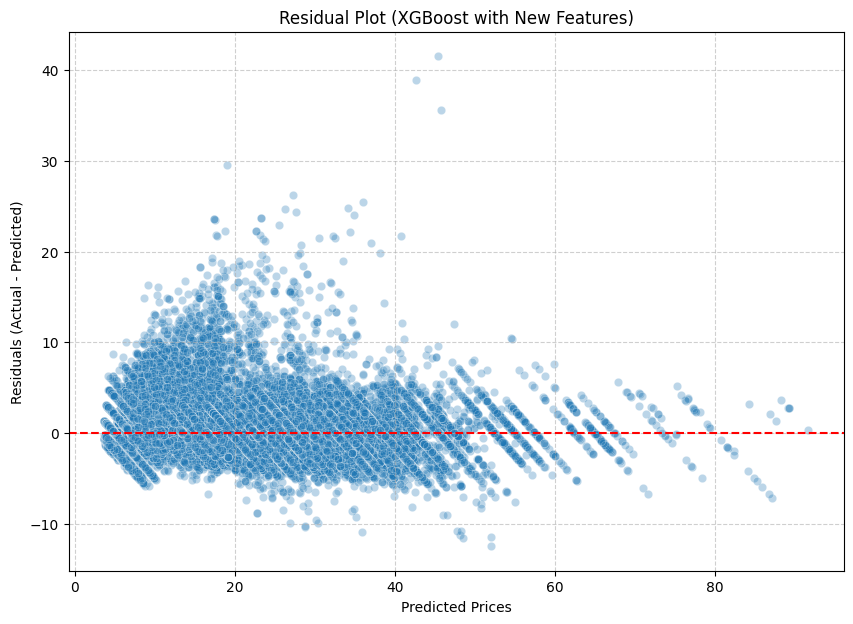

In [ ]:
# Calculate residuals for the model with new features
residuals_new_features = y_test_new - y_pred_new_features

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_new_features, y=residuals_new_features, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (XGBoost with New Features)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Preparing Data for Modeling: Train-Test Split

With feature engineering complete, our next step is to prepare the data for machine learning model training. This involves dropping the original `time_stamp_ride` column (as its information has been extracted into new features), separating the features (`X`) from the target variable (`y`), and finally splitting the dataset into training and testing sets.

In [ ]:
# Drop the original 'time_stamp_ride' column as we've extracted its useful features
df_model = df_merged.drop(columns=['time_stamp_ride'])

# Define features (X) and target (y)
X = df_model.drop('price', axis=1)
y = df_model['price']

print("Features (X) and Target (y) defined.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

print("\nFirst 5 rows of X (features):")
display(X.head())
print("\nFirst 5 rows of y (target):")
display(y.head())

Features (X) and Target (y) defined.
Shape of X: (1268639, 58)
Shape of y: (1268639,)

First 5 rows of X (features):


,distance,surge_multiplier,temp,clouds,pressure,rain,humidity,wind,ride_hour,ride_day_of_week,...,name_Lux Black,name_Lux Black XL,name_Lyft,name_Lyft XL,name_Shared,name_Taxi,name_UberPool,name_UberX,name_UberXL,name_WAV
0,0.44,1.0,38.46,0.29,1022.25,0.0000,0.76,7.68,9,6,...,False,False,False,False,True,False,False,False,False,False
1,0.44,1.0,44.31,1.00,1003.17,0.1123,0.90,13.69,2,1,...,False,False,False,False,False,False,False,False,False,False
2,0.44,1.0,43.82,0.99,1002.59,0.0997,0.89,11.57,2,1,...,False,False,False,False,False,False,False,False,False,False
3,0.44,1.0,39.61,0.76,1000.78,0.0000,0.72,8.80,1,2,...,False,False,True,False,False,False,False,False,False,False
4,0.44,1.0,35.08,0.00,1013.71,0.0000,0.70,5.25,4,4,...,False,True,False,False,False,False,False,False,False,False



First 5 rows of y (target):


,price
0,5.0
1,11.0
2,11.0
3,7.0
4,26.0


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully!
X_train shape: (1014911, 58)
X_test shape: (253728, 58)
y_train shape: (1014911,)
y_test shape: (253728,)


## Model Training: XGBoost Regressor

Now that our data is prepared, we will train an XGBoost Regressor model. XGBoost is known for its efficiency and performance in various machine learning tasks, including regression. We'll use the default parameters for now and can tune them later if needed.

In [ ]:
# Initialize and train the XGBoost Regressor model
# Using a small number of estimators for quicker demonstration, can be increased for better performance
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully!")

XGBoost Regressor model trained successfully!


## Model Evaluation

After training the model, we need to evaluate its performance on unseen data (the test set). We'll use common regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) to assess how well our model predicts the cab ride prices.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

print("\nFirst 10 actual vs. predicted prices:")
results_df = pd.DataFrame({'Actual': y_test.head(10), 'Predicted': y_pred[:10]})
display(results_df)

Mean Absolute Error (MAE): 0.99
Mean Squared Error (MSE): 2.40
Root Mean Squared Error (RMSE): 1.55
R-squared (R2): 0.97

First 10 actual vs. predicted prices:


,Actual,Predicted
1016257,7.0,8.093441
745527,7.0,7.402671
162653,16.5,17.972517
739232,13.5,14.049540
404917,17.0,17.513849
437593,19.5,18.311169
694648,16.5,16.771889
506350,13.5,13.634450
600274,26.0,26.670033
1249206,8.0,9.191256


### Visualizing Actual vs. Predicted Prices

To get a better understanding of the model's performance, let's visualize the relationship between the actual prices and the prices predicted by our XGBoost model. A scatter plot with a diagonal line representing perfect predictions will allow us to see how well the predictions align with reality.

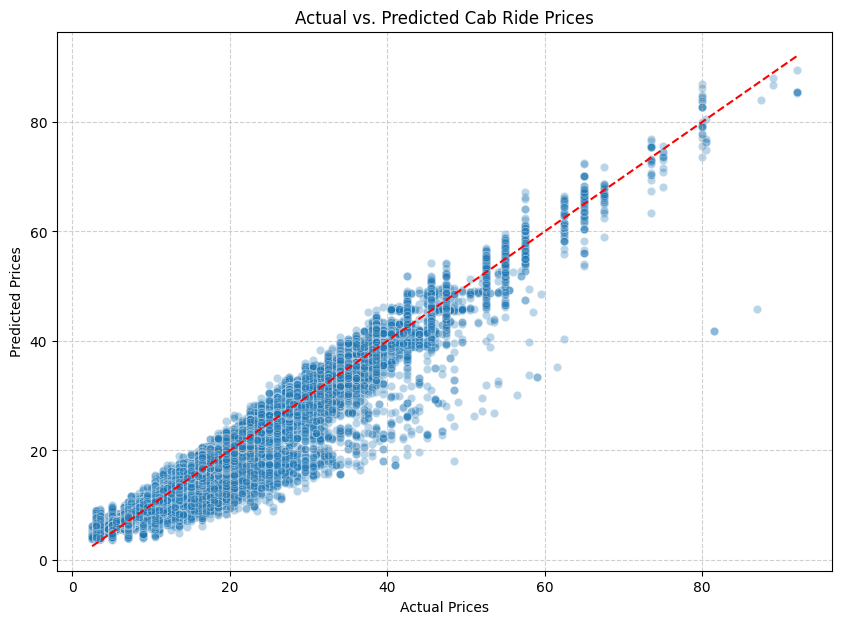

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Actual vs. Predicted Cab Ride Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Feature Importance

Understanding feature importance helps us identify which variables the model relies on most when making predictions. This can provide valuable insights into the underlying relationships in the data.

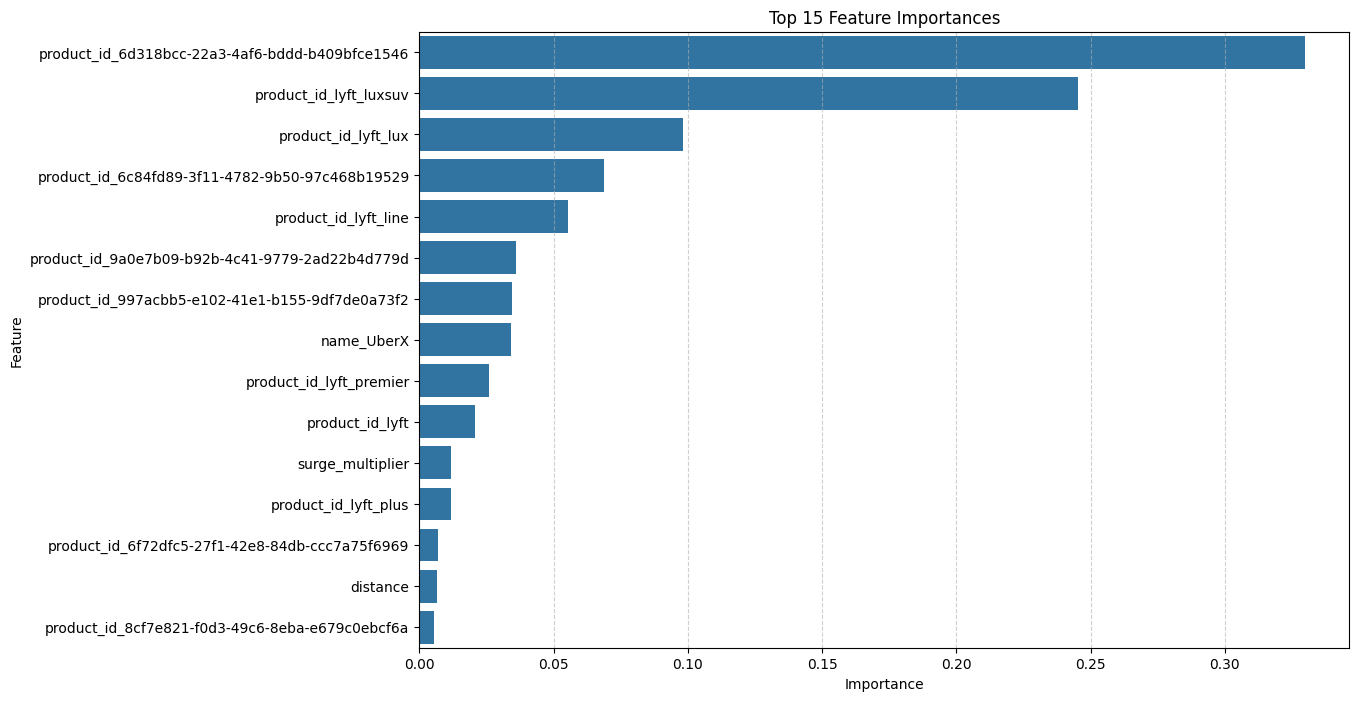

In [ ]:
# Get feature importances from the trained XGBoost model
feature_importances = xgb_model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot the top N feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(15))
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### Residual Plot

A residual plot displays the difference between the observed values and the predicted values (residuals) against the predicted values. It helps in checking the assumptions of linearity, homoscedasticity (constant variance of errors), and independence of errors. Ideally, residuals should be randomly scattered around zero.

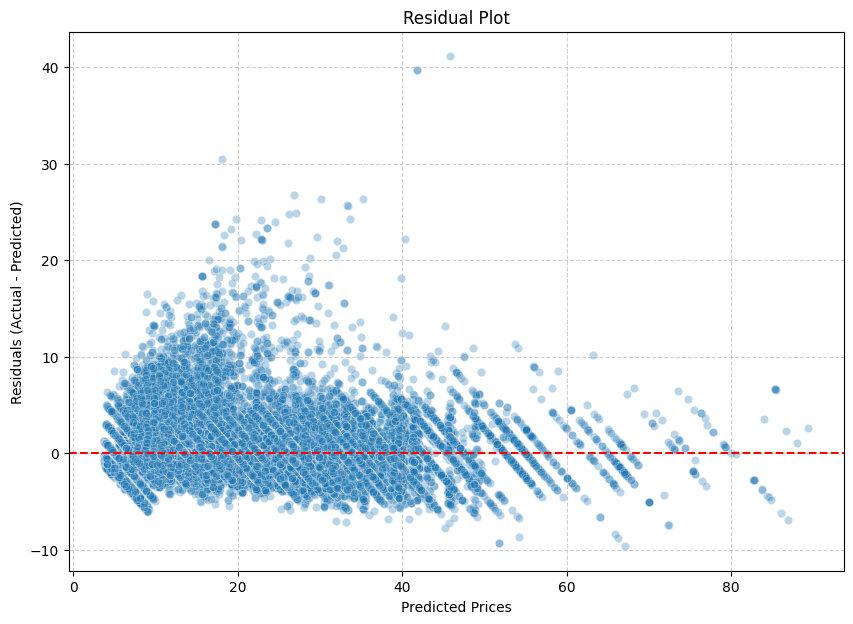

In [ ]:
# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Hyperparameter Tuning with Randomized Search

To further improve the model's performance and generalization, we will perform hyperparameter tuning using `RandomizedSearchCV`. This method efficiently explores a defined range of hyperparameter values, which is particularly useful for complex models like XGBoost and large datasets. We'll focus on a few key parameters to strike a balance between performance and computational cost.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution to sample from
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500], # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3], # Step size shrinkage to prevent overfitting
    'max_depth': [3, 4, 5, 6, 7], # Maximum depth of a tree
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], # Subsample ratio of the training instance
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0], # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.2, 0.3, 0.4] # Minimum loss reduction required to make a further partition on a leaf node
}

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Lower for faster execution.
# cv: Number of folds for cross-validation.
random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20, # Reduced number of iterations for quicker demonstration
    cv=3, # Reduced cross-validation folds for quicker demonstration
    scoring='neg_mean_squared_error', # Metric to optimize
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Perform the search on the training data
random_search.fit(X_train, y_train)

print("Best hyperparameters found:", random_search.best_params_)
print("Best RMSE found:", np.sqrt(-random_search.best_score_))

# Get the best model
best_xgb_model = random_search.best_estimator_

print("Best XGBoost model trained successfully!")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best hyperparameters found: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 0.9}
Best RMSE found: 1.5306148241755448
Best XGBoost model trained successfully!


## Re-evaluating Model Performance with Tuned Hyperparameters

After identifying the best hyperparameters through `RandomizedSearchCV`, we will now evaluate the performance of the `best_xgb_model` on the test set. We'll compare the new evaluation metrics (MAE, MSE, RMSE, R2) against the previous results to confirm the improvement from hyperparameter tuning. Then we will re-examine the residuals.

In [ ]:
# Make predictions on the test set using the best model
y_pred_tuned = best_xgb_model.predict(X_test)

# Calculate evaluation metrics for the tuned model
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Performance with Tuned XGBoost Model:")
print(f"Mean Absolute Error (MAE): {mae_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"R-squared (R2): {r2_tuned:.2f}")

print("\nComparing with previous model (before tuning):")
print(f"Previous MAE: {mae:.2f}, New MAE: {mae_tuned:.2f}")
print(f"Previous RMSE: {rmse:.2f}, New RMSE: {rmse_tuned:.2f}")
print(f"Previous R2: {r2:.2f}, New R2: {r2_tuned:.2f}")

Performance with Tuned XGBoost Model:
Mean Absolute Error (MAE): 0.96
Mean Squared Error (MSE): 2.27
Root Mean Squared Error (RMSE): 1.51
R-squared (R2): 0.97

Comparing with previous model (before tuning):
Previous MAE: 0.99, New MAE: 0.96
Previous RMSE: 1.55, New RMSE: 1.51
Previous R2: 0.97, New R2: 0.97


### Re-examining the Residual Plot with Tuned Model

Now that we have the tuned model, let's generate a new residual plot to see if the hyperparameter optimization has had any impact on the pattern of our prediction errors, especially concerning the observed heteroscedasticity.

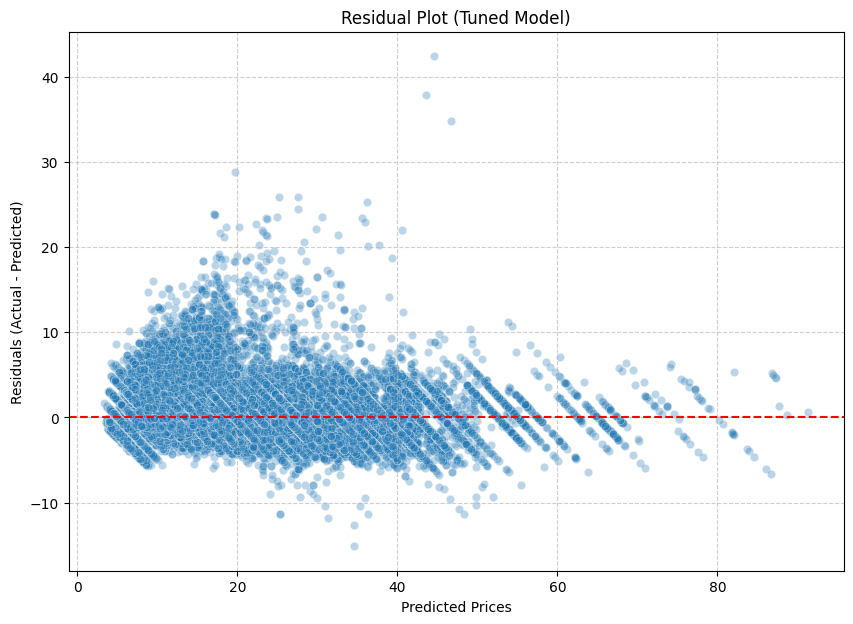

In [ ]:
# Calculate residuals for the tuned model
residuals_tuned = y_test - y_pred_tuned

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_tuned, y=residuals_tuned, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (Tuned Model)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Addressing Heteroscedasticity with Log Transformation

To further tackle the slight heteroscedasticity observed in the residual plot, we will apply a log transformation to our target variable (`price`). This can help to stabilize the variance of the residuals and make the model's assumptions more valid. We'll use `np.log1p` (log(1+x)) which handles zero values gracefully.

In [ ]:
# Apply log transformation to the target variable
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Target variable 'price' log-transformed successfully!")
print(f"Original y_train mean: {y_train.mean():.2f}, Log-transformed y_train mean: {y_train_log.mean():.2f}")

Target variable 'price' log-transformed successfully!
Original y_train mean: 16.30, Log-transformed y_train mean: 2.72


### Retraining the Model with Log-Transformed Target

Now, we'll retrain our XGBoost model using the best hyperparameters found previously, but this time with the log-transformed `y_train_log` as the target variable.

In [ ]:
# Retrain the best XGBoost model with the log-transformed target
# Use the parameters from the previous RandomizedSearchCV
log_xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

log_xgb_model.fit(X_train, y_train_log)

print("XGBoost Regressor model retrained with log-transformed target successfully!")

XGBoost Regressor model retrained with log-transformed target successfully!


### Evaluating the Log-Transformed Model and Re-examining Residuals

After training, we'll make predictions, inverse-transform them back to the original scale, and then evaluate the model's performance. Finally, we'll generate a new residual plot to check if the log transformation has successfully addressed the heteroscedasticity.

In [ ]:
# Make predictions on the log-transformed test set
y_pred_log = log_xgb_model.predict(X_test)

# Inverse transform the predictions back to the original scale
y_pred_original_scale = np.expm1(y_pred_log)

# Calculate evaluation metrics using the original y_test and inverse-transformed predictions
mae_log_model = mean_absolute_error(y_test, y_pred_original_scale)
mse_log_model = mean_squared_error(y_test, y_pred_original_scale)
rmse_log_model = np.sqrt(mse_log_model)
r2_log_model = r2_score(y_test, y_pred_original_scale)

print("Performance with Log-Transformed Target Model:")
print(f"Mean Absolute Error (MAE): {mae_log_model:.2f}")
print(f"Mean Squared Error (MSE): {mse_log_model:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_log_model:.2f}")
print(f"R-squared (R2): {r2_log_model:.2f}")

print("\nComparing with previously tuned model:")
print(f"Previous Tuned MAE: {mae_tuned:.2f}, Log-Model MAE: {mae_log_model:.2f}")
print(f"Previous Tuned RMSE: {rmse_tuned:.2f}, Log-Model RMSE: {rmse_log_model:.2f}")
print(f"Previous Tuned R2: {r2_tuned:.2f}, Log-Model R2: {r2_log_model:.2f}")

Performance with Log-Transformed Target Model:
Mean Absolute Error (MAE): 1.01
Mean Squared Error (MSE): 2.54
Root Mean Squared Error (RMSE): 1.59
R-squared (R2): 0.97

Comparing with previously tuned model:
Previous Tuned MAE: 0.96, Log-Model MAE: 1.01
Previous Tuned RMSE: 1.51, Log-Model RMSE: 1.59
Previous Tuned R2: 0.97, Log-Model R2: 0.97


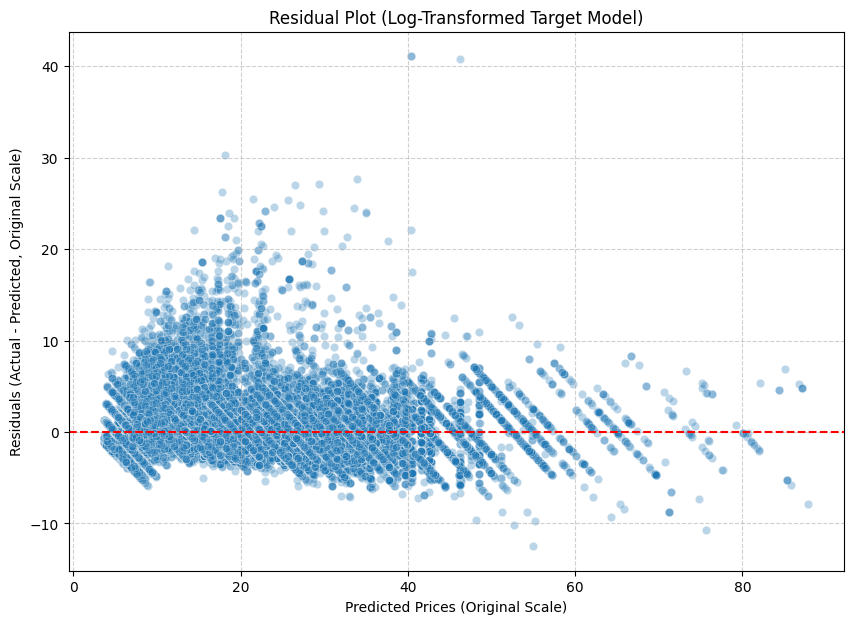

In [ ]:
# Calculate residuals for the log-transformed model (on original scale)
residuals_log_model = y_test - y_pred_original_scale

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_original_scale, y=residuals_log_model, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (Log-Transformed Target Model)')
plt.xlabel('Predicted Prices (Original Scale)')
plt.ylabel('Residuals (Actual - Predicted, Original Scale)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Exploring Alternative Strategies: XGBoost with `reg:gamma` Objective

Given that the log transformation did not effectively mitigate heteroscedasticity and slightly worsened overall metrics, we will now explore using a different objective function for our XGBoost model: `reg:gamma`. This objective is suitable for target variables that are strictly positive and often right-skewed, which aligns with typical price data distributions. It can sometimes handle heteroscedasticity more effectively by modeling the variance as proportional to the mean.

First, let's quickly verify that our `price` target variable is strictly positive and observe its distribution.

Is the target variable 'price' strictly positive? True


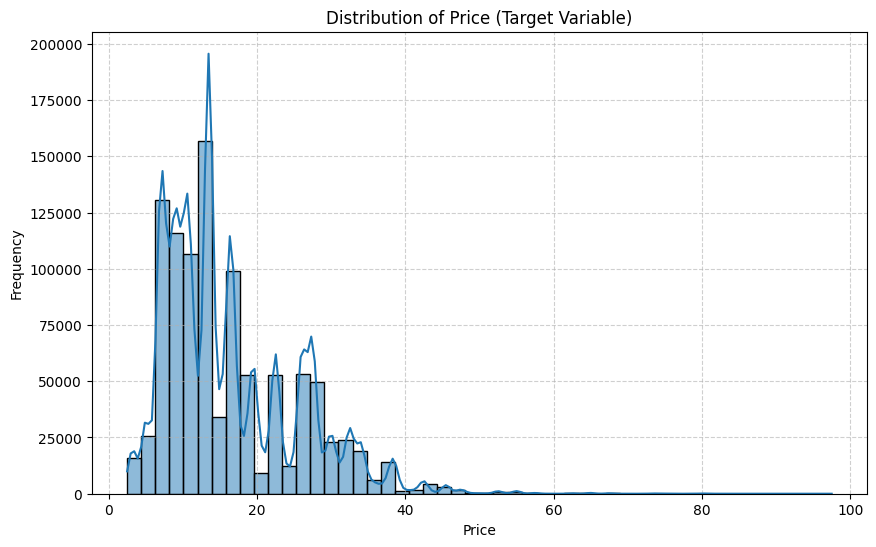

Skewness of y_train: 1.15


In [ ]:
# Check if price is strictly positive
is_strictly_positive = (y_train > 0).all() and (y_test > 0).all()
print(f"Is the target variable 'price' strictly positive? {is_strictly_positive}")

# Plot the distribution of the target variable to check for skewness
plt.figure(figsize=(10, 6))
sns.histplot(y_train, bins=50, kde=True)
plt.title('Distribution of Price (Target Variable)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Skewness of y_train: {y_train.skew():.2f}")

### Retraining with `reg:gamma` Objective

Since the price is strictly positive and appears right-skewed, the `reg:gamma` objective is a suitable choice. We will now retrain the XGBoost model using the best hyperparameters found previously, but with `objective='reg:gamma'`.

In [ ]:
# Retrain the best XGBoost model with the 'reg:gamma' objective
gamma_xgb_model = xgb.XGBRegressor(
    objective='reg:gamma',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

gamma_xgb_model.fit(X_train, y_train)

print("XGBoost Regressor model retrained with 'reg:gamma' objective successfully!")

XGBoost Regressor model retrained with 'reg:gamma' objective successfully!


### Evaluating the `reg:gamma` Model and Re-examining Residuals

Now, let's evaluate the performance of this new model and generate a residual plot to see if the `reg:gamma` objective has helped in addressing the heteroscedasticity.

In [ ]:
# Make predictions on the test set using the gamma model
y_pred_gamma = gamma_xgb_model.predict(X_test)

# Calculate evaluation metrics for the gamma model
mae_gamma_model = mean_absolute_error(y_test, y_pred_gamma)
mse_gamma_model = mean_squared_error(y_test, y_pred_gamma)
rmse_gamma_model = np.sqrt(mse_gamma_model)
r2_gamma_model = r2_score(y_test, y_pred_gamma)

print("Performance with XGBoost Model (reg:gamma objective):")
print(f"Mean Absolute Error (MAE): {mae_gamma_model:.2f}")
print(f"Mean Squared Error (MSE): {mse_gamma_model:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gamma_model:.2f}")
print(f"R-squared (R2): {r2_gamma_model:.2f}")

print("\nComparing with previously tuned model (reg:squarederror):")
print(f"Previous Tuned MAE: {mae_tuned:.2f}, Gamma Model MAE: {mae_gamma_model:.2f}")
print(f"Previous Tuned RMSE: {rmse_tuned:.2f}, Gamma Model RMSE: {rmse_gamma_model:.2f}")
print(f"Previous Tuned R2: {r2_tuned:.2f}, Gamma Model R2: {r2_gamma_model:.2f}")

print("\nComparing with Log-Transformed Model:")
print(f"Log-Model MAE: {mae_log_model:.2f}, Gamma Model MAE: {mae_gamma_model:.2f}")
print(f"Log-Model RMSE: {rmse_log_model:.2f}, Gamma Model RMSE: {rmse_gamma_model:.2f}")
print(f"Log-Model R2: {r2_log_model:.2f}, Gamma Model R2: {r2_gamma_model:.2f}")

Performance with XGBoost Model (reg:gamma objective):
Mean Absolute Error (MAE): 1.01
Mean Squared Error (MSE): 2.50
Root Mean Squared Error (RMSE): 1.58
R-squared (R2): 0.97

Comparing with previously tuned model (reg:squarederror):
Previous Tuned MAE: 0.96, Gamma Model MAE: 1.01
Previous Tuned RMSE: 1.51, Gamma Model RMSE: 1.58
Previous Tuned R2: 0.97, Gamma Model R2: 0.97

Comparing with Log-Transformed Model:
Log-Model MAE: 1.01, Gamma Model MAE: 1.01
Log-Model RMSE: 1.59, Gamma Model RMSE: 1.58
Log-Model R2: 0.97, Gamma Model R2: 0.97


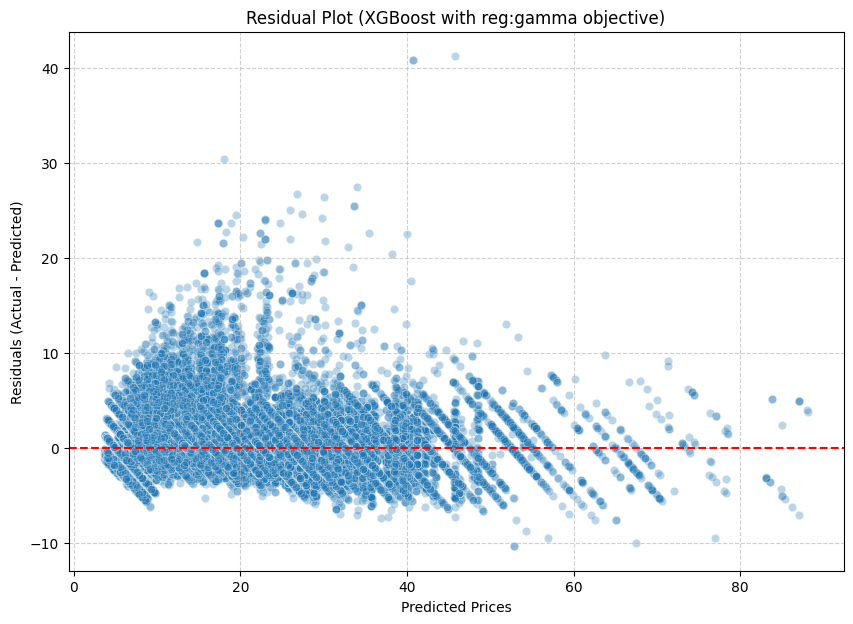

In [ ]:
# Calculate residuals for the gamma model
residuals_gamma_model = y_test - y_pred_gamma

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_gamma, y=residuals_gamma_model, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (XGBoost with reg:gamma objective)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Exploring Weighted Least Squares (WLS) to Address Heteroscedasticity

Since direct transformations and objective function changes haven't fully addressed the heteroscedasticity, we will now implement a Weighted Least Squares (WLS) approach. This involves:

1.  **Analyzing Residuals from the best model:** We'll use the residuals from our `best_xgb_model` (the original tuned model with `reg:squarederror`) as it provided the best overall performance in terms of MAE/RMSE.
2.  **Modeling Residual Variance:** We'll train a simple model to predict the squared residuals (which serve as a proxy for variance) based on the `y_pred_tuned` values.
3.  **Calculating Weights:** The weights for WLS are typically inversely proportional to the variance of the errors. So, we'll use `1 / predicted_squared_residuals` as our weights.
4.  **Retraining XGBoost with Weights:** We will then retrain our `best_xgb_model` (or a copy of it) using these calculated `sample_weight` in the `fit` method.

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Calculate squared residuals from the best performing tuned model
# (using 'best_xgb_model' which had objective='reg:squarederror')
squared_residuals_tuned = (y_test - y_pred_tuned)**2

# Prepare data for modeling variance: use predicted values to predict squared residuals
X_pred_tuned = y_pred_tuned.reshape(-1, 1)

# 2. Model the variance (squared residuals) using a simple linear regression
# This model will predict how residual variance changes with predicted price
variance_model = LinearRegression()
variance_model.fit(X_pred_tuned, squared_residuals_tuned)

# Predict the squared residuals for the entire training set
# We need weights for X_train based on predictions from X_train
# So, predict on y_pred_train (predictions of best_xgb_model on X_train)
y_pred_train_best = best_xgb_model.predict(X_train)
predicted_squared_residuals_train = variance_model.predict(y_pred_train_best.reshape(-1, 1))

# Ensure predicted squared residuals are positive to avoid errors with inverse
predicted_squared_residuals_train[predicted_squared_residuals_train < 0.01] = 0.01 # Floor at a small positive value

# 3. Calculate sample weights: inverse of the predicted variance
sample_weights = 1 / predicted_squared_residuals_train

print("Sample weights calculated successfully for WLS training!")
print(f"Min sample weight: {sample_weights.min():.2f}")
print(f"Max sample weight: {sample_weights.max():.2f}")
print(f"Mean sample weight: {sample_weights.mean():.2f}")

Sample weights calculated successfully for WLS training!
Min sample weight: 0.10
Max sample weight: 1.14
Mean sample weight: 0.51


### Retraining XGBoost with Weighted Least Squares (WLS)

Now, we'll retrain our XGBoost model using the best hyperparameters found previously, but this time we'll pass the calculated `sample_weights` to the `fit` method. This will make the model pay more attention to observations with lower predicted residual variance.

In [ ]:
# 4. Retrain the best XGBoost model with sample weights
wls_xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

wls_xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

print("XGBoost Regressor model retrained with Weighted Least Squares successfully!")

XGBoost Regressor model retrained with Weighted Least Squares successfully!


### Evaluating the WLS Model and Re-examining Residuals

Finally, we'll evaluate the performance of our WLS-trained XGBoost model and generate a new residual plot to assess whether this approach has successfully reduced the heteroscedasticity.

In [ ]:
# 5. Make predictions on the test set using the WLS model
y_pred_wls = wls_xgb_model.predict(X_test)

# Calculate evaluation metrics for the WLS model
mae_wls_model = mean_absolute_error(y_test, y_pred_wls)
mse_wls_model = mean_squared_error(y_test, y_pred_wls)
rmse_wls_model = np.sqrt(mse_wls_model)
r2_wls_model = r2_score(y_test, y_pred_wls)

print("Performance with XGBoost Model (Weighted Least Squares objective):")
print(f"Mean Absolute Error (MAE): {mae_wls_model:.2f}")
print(f"Mean Squared Error (MSE): {mse_wls_model:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_wls_model:.2f}")
print(f"R-squared (R2): {r2_wls_model:.2f}")

print("\nComparing with previous models:")
print(f"Original Tuned MAE: {mae_tuned:.2f}, WLS Model MAE: {mae_wls_model:.2f}")
print(f"Original Tuned RMSE: {rmse_tuned:.2f}, WLS Model RMSE: {rmse_wls_model:.2f}")
print(f"Original Tuned R2: {r2_tuned:.2f}, WLS Model R2: {r2_wls_model:.2f}")

print(f"Log-Model MAE: {mae_log_model:.2f}, WLS Model MAE: {mae_wls_model:.2f}")
print(f"Log-Model RMSE: {rmse_log_model:.2f}, WLS Model RMSE: {rmse_wls_model:.2f}")
print(f"Log-Model R2: {r2_log_model:.2f}, WLS Model R2: {r2_wls_model:.2f}")

print(f"Gamma-Model MAE: {mae_gamma_model:.2f}, WLS Model MAE: {mae_wls_model:.2f}")
print(f"Gamma-Model RMSE: {rmse_gamma_model:.2f}, WLS Model RMSE: {rmse_wls_model:.2f}")
print(f"Gamma-Model R2: {r2_gamma_model:.2f}, WLS Model R2: {r2_wls_model:.2f}")

Performance with XGBoost Model (Weighted Least Squares objective):
Mean Absolute Error (MAE): 0.96
Mean Squared Error (MSE): 2.28
Root Mean Squared Error (RMSE): 1.51
R-squared (R2): 0.97

Comparing with previous models:
Original Tuned MAE: 0.96, WLS Model MAE: 0.96
Original Tuned RMSE: 1.51, WLS Model RMSE: 1.51
Original Tuned R2: 0.97, WLS Model R2: 0.97
Log-Model MAE: 1.01, WLS Model MAE: 0.96
Log-Model RMSE: 1.59, WLS Model RMSE: 1.51
Log-Model R2: 0.97, WLS Model R2: 0.97
Gamma-Model MAE: 1.01, WLS Model MAE: 0.96
Gamma-Model RMSE: 1.58, WLS Model RMSE: 1.51
Gamma-Model R2: 0.97, WLS Model R2: 0.97


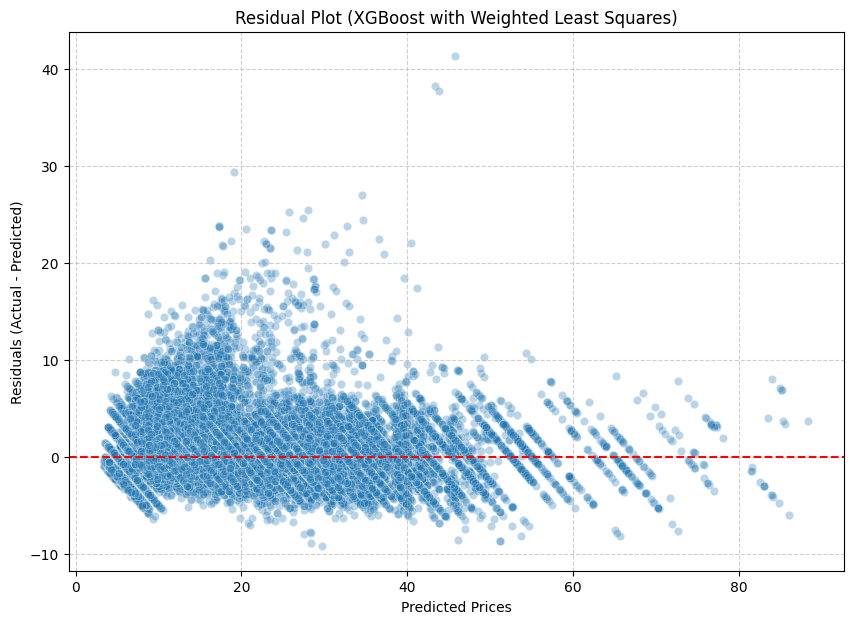

In [ ]:
# Calculate residuals for the WLS model
residuals_wls_model = y_test - y_pred_wls

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_wls, y=residuals_wls_model, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (XGBoost with Weighted Least Squares)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Re-evaluating Feature Engineering to Address Heteroscedasticity

Since previous attempts with log transformation, `reg:gamma` objective, and Weighted Least Squares (WLS) did not significantly reduce the fanning-out pattern in the residual plots, it suggests that the heteroscedasticity might be stemming from our current feature set or a lack of more expressive features.

Effective feature engineering can often lead to a model that better understands the underlying data generating process, thereby stabilizing the variance of the residuals.

**Possible areas to explore for new features:**

1.  **Interaction Terms:** Are there interactions between existing features that might explain the varying spread of residuals? For example, the effect of `distance` might vary depending on `cab_type` or `surge_multiplier`.
2.  **Polynomial Features:** For numerical features like `distance`, `temp`, `humidity`, could non-linear relationships with the target variable be better captured by polynomial terms?
3.  **Temporal Features:** We've extracted `hour`, `day_of_week`, and `month`. Could more granular temporal features (e.g., `is_weekend`, `time_of_day_category` like morning/afternoon/evening/night) or cyclical features (sine/cosine transformations for `hour`/`day_of_week`) be beneficial?
4.  **Geospatial Features:** Currently, `source` and `destination` are categorical. If we had latitude/longitude, we could derive features like straight-line distance, travel time estimates, or density of rides in an area. Without explicit coordinates, we could explore creating interaction terms between `source` and `destination`.
5.  **Weather Feature Combinations:** Perhaps a combination of `temp`, `rain`, `clouds` creates a 'weather severity index' that impacts price variance.
6.  **Cardinality of Categorical Features:** For `cab_type`, `product_id`, and `name`, are there too many categories that could be grouped, or could we use a more sophisticated encoding technique (e.g., target encoding) if one-hot encoding is too sparse?

Let's start by looking for potential interaction terms and creating more nuanced temporal features, as these are often good candidates for explaining variability. We'll specifically consider interactions that might explain the varying price scale.

### Advanced Feature Engineering and Data Transformations

Given that previous feature engineering attempts did not fully resolve heteroscedasticity, we need to consider more sophisticated approaches to create features that might better explain the variance in prices.

Here are some strategies we can explore:

1.  **Cyclical Features for Time:** Transform `ride_hour` and `ride_day_of_week` into sine and cosine components. This helps the model understand the cyclical nature of time (e.g., 23:00 is closer to 00:00 than 12:00) without imposing an artificial linear order.
2.  **Polynomial Features:** Introduce polynomial terms for key numerical features (e.g., `distance`, `temp`, `surge_multiplier`). This can capture non-linear relationships that a linear model might miss and potentially model the spread better.
3.  **More Complex Interaction Terms:** Beyond simple products, consider interactions that are specific to domain knowledge. For instance, `cab_type` and `ride_hour` might have a specific impact on price variance during peak vs. off-peak hours.
4.  **Binning Numerical Features:** Convert continuous numerical features into ordinal categories (bins). This can sometimes help capture non-linear effects and may simplify the model's task of learning variance patterns.
5.  **Aggregated Features:** If there are natural groupings (e.g., `source` or `destination`), we could create features that aggregate information about these groups (e.g., average price from a `source`, standard deviation of `surge_multiplier` for a `cab_type`).

Let's start by implementing **Cyclical Features** for `ride_hour` and `ride_day_of_week`, as these are often powerful for time-series data and can help the model understand the periodicity of demand and pricing.

In [ ]:
import numpy as np

# Create cyclical features for 'ride_hour'
df_merged['ride_hour_sin'] = np.sin(2 * np.pi * df_merged['ride_hour'] / 24)
df_merged['ride_hour_cos'] = np.cos(2 * np.pi * df_merged['ride_hour'] / 24)

# Create cyclical features for 'ride_day_of_week'
df_merged['ride_day_of_week_sin'] = np.sin(2 * np.pi * df_merged['ride_day_of_week'] / 7)
df_merged['ride_day_of_week_cos'] = np.cos(2 * np.pi * df_merged['ride_day_of_week'] / 7)

print("Cyclical features for 'ride_hour' and 'ride_day_of_week' created successfully!")
print("First 5 rows with new cyclical features:")
display(df_merged[['ride_hour', 'ride_hour_sin', 'ride_hour_cos', 'ride_day_of_week', 'ride_day_of_week_sin', 'ride_day_of_week_cos']].head())

Cyclical features for 'ride_hour' and 'ride_day_of_week' created successfully!
First 5 rows with new cyclical features:


,ride_hour,ride_hour_sin,ride_hour_cos,ride_day_of_week,ride_day_of_week_sin,ride_day_of_week_cos
0,9,0.707107,-0.707107,6,-0.781831,0.623490
1,2,0.500000,0.866025,1,0.781831,0.623490
2,2,0.500000,0.866025,1,0.781831,0.623490
3,1,0.258819,0.965926,2,0.974928,-0.222521
4,4,0.866025,0.500000,4,-0.433884,-0.900969


### Re-preparing Data with Cyclical Features

After adding the cyclical features, we need to re-prepare our dataset for model training. This includes dropping the original `ride_hour` and `ride_day_of_week` columns (as they are now represented cyclically), and then re-splitting the data into training and testing sets.

In [ ]:
# Drop the original 'time_stamp_ride', 'ride_hour', and 'ride_day_of_week' columns
df_model_cyclical = df_merged.drop(columns=['time_stamp_ride', 'ride_hour', 'ride_day_of_week'])

# Define features (X) and target (y) again
X_cyclical = df_model_cyclical.drop('price', axis=1)
y_cyclical = df_model_cyclical['price']

print("Features (X) and Target (y) redefined with cyclical features.")
print(f"Shape of X_cyclical: {X_cyclical.shape}")
print(f"Shape of y_cyclical: {y_cyclical.shape}")

# Split the data into training and testing sets
X_train_cyclical, X_test_cyclical, y_train_cyclical, y_test_cyclical = train_test_split(X_cyclical, y_cyclical, test_size=0.2, random_state=42)

print("\nData re-split into training and testing sets successfully!")
print(f"X_train_cyclical shape: {X_train_cyclical.shape}")
print(f"X_test_cyclical shape: {X_test_cyclical.shape}")
print(f"y_train_cyclical shape: {y_train_cyclical.shape}")
print(f"y_test_cyclical shape: {y_test_cyclical.shape}")

Features (X) and Target (y) redefined with cyclical features.
Shape of X_cyclical: (1268639, 62)
Shape of y_cyclical: (1268639,)

Data re-split into training and testing sets successfully!
X_train_cyclical shape: (1014911, 62)
X_test_cyclical shape: (253728, 62)
y_train_cyclical shape: (1014911,)
y_test_cyclical shape: (253728,)


### Retraining the Model with Cyclical Features

We will now retrain the XGBoost model using the best hyperparameters (from the initial tuning) but with the dataset that includes the new cyclical features. This will allow us to observe the impact on both performance metrics and the residual plot.

In [ ]:
# Retrain the XGBoost model with the best hyperparameters on the cyclical feature set
# Using the parameters from the previous RandomizedSearchCV stored in `best_xgb_model`
xgb_model_cyclical = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

xgb_model_cyclical.fit(X_train_cyclical, y_train_cyclical)

print("XGBoost Regressor model retrained with cyclical features successfully!")

XGBoost Regressor model retrained with cyclical features successfully!


### Evaluating the Model with Cyclical Features and Re-examining Residuals

Finally, we'll evaluate the performance of our model with cyclical features and generate a new residual plot to assess if this advanced feature engineering approach has helped in addressing the heteroscedasticity.

In [ ]:
# Make predictions on the test set using the cyclical features model
y_pred_cyclical = xgb_model_cyclical.predict(X_test_cyclical)

# Calculate evaluation metrics
mae_cyclical = mean_absolute_error(y_test_cyclical, y_pred_cyclical)
mse_cyclical = mean_squared_error(y_test_cyclical, y_pred_cyclical)
rmse_cyclical = np.sqrt(mse_cyclical)
r2_cyclical = r2_score(y_test_cyclical, y_pred_cyclical)

print("Performance with XGBoost Model (Cyclical Features):")
print(f"Mean Absolute Error (MAE): {mae_cyclical:.2f}")
print(f"Mean Squared Error (MSE): {mse_cyclical:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_cyclical:.2f}")
print(f"R-squared (R2): {r2_cyclical:.2f}")

print("\nComparing with previous best tuned model:")
print(f"Previous Tuned MAE: {mae_tuned:.2f}, Cyclical Features MAE: {mae_cyclical:.2f}")
print(f"Previous Tuned RMSE: {rmse_tuned:.2f}, Cyclical Features RMSE: {rmse_cyclical:.2f}")
print(f"Previous Tuned R2: {r2_tuned:.2f}, Cyclical Features R2: {r2_cyclical:.2f}")

Performance with XGBoost Model (Cyclical Features):
Mean Absolute Error (MAE): 0.96
Mean Squared Error (MSE): 2.25
Root Mean Squared Error (RMSE): 1.50
R-squared (R2): 0.97

Comparing with previous best tuned model:
Previous Tuned MAE: 0.96, Cyclical Features MAE: 0.96
Previous Tuned RMSE: 1.51, Cyclical Features RMSE: 1.50
Previous Tuned R2: 0.97, Cyclical Features R2: 0.97


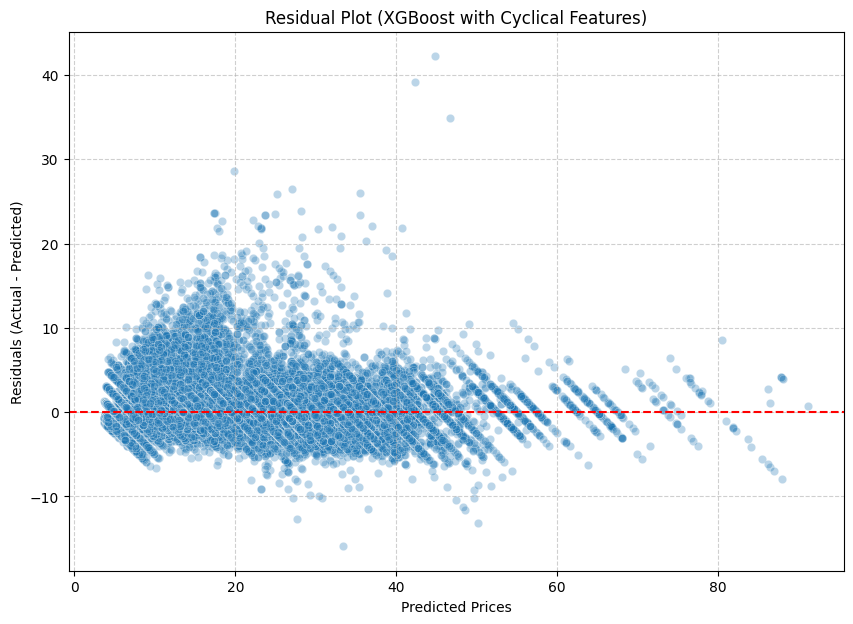

In [ ]:
# Calculate residuals for the cyclical features model
residuals_cyclical = y_test_cyclical - y_pred_cyclical

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_cyclical, y=residuals_cyclical, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (XGBoost with Cyclical Features)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Adding Polynomial Features for Numerical Variables

To further capture non-linear relationships and potentially address heteroscedasticity, we will add squared terms for `distance` and `surge_multiplier`.

-   `distance_squared`: `distance` squared
-   `surge_multiplier_squared`: `surge_multiplier` squared

These features might help the model to better account for how the impact of distance or surge changes non-linearly with their values, which could affect the variance of price predictions.

In [ ]:
# Add squared terms for 'distance' and 'surge_multiplier'
df_merged['distance_squared'] = df_merged['distance']**2
df_merged['surge_multiplier_squared'] = df_merged['surge_multiplier']**2

print("Polynomial features 'distance_squared' and 'surge_multiplier_squared' created.")
print("First 5 rows with new features:")
display(df_merged[['distance', 'distance_squared', 'surge_multiplier', 'surge_multiplier_squared']].head())

print("\nDataFrame Info after adding polynomial features:")
df_merged.info()

Polynomial features 'distance_squared' and 'surge_multiplier_squared' created.
First 5 rows with new features:


,distance,distance_squared,surge_multiplier,surge_multiplier_squared
0,0.44,0.1936,1.0,1.0
1,0.44,0.1936,1.0,1.0
2,0.44,0.1936,1.0,1.0
3,0.44,0.1936,1.0,1.0
4,0.44,0.1936,1.0,1.0



DataFrame Info after adding polynomial features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268639 entries, 0 to 1268638
Data columns (total 68 columns):
 #   Column                                           Non-Null Count    Dtype         
---  ------                                           --------------    -----         
 0   distance                                         1268639 non-null  float64       
 1   time_stamp_ride                                  1268639 non-null  datetime64[ns]
 2   price                                            1268639 non-null  float64       
 3   surge_multiplier                                 1268639 non-null  float64       
 4   temp                                             1268639 non-null  float64       
 5   clouds                                           1268639 non-null  float64       
 6   pressure                                         1268639 non-null  float64       
 7   rain                                             

### Re-preparing Data with Polynomial Features

Now that we've added polynomial features, we need to re-prepare the dataset. This involves dropping the original temporal columns (`time_stamp_ride`, `ride_hour`, `ride_day_of_week`, `ride_month`) since their information is now captured by cyclical features and new polynomial features, and then re-splitting the data into training and testing sets.

In [ ]:
# Drop original temporal columns that are now represented by cyclical features or are less direct
df_model_poly = df_merged.drop(columns=['time_stamp_ride', 'ride_hour', 'ride_day_of_week', 'ride_month'])

# Define features (X) and target (y) again
X_poly = df_model_poly.drop('price', axis=1)
y_poly = df_model_poly['price']

print("Features (X) and Target (y) redefined with polynomial features.")
print(f"Shape of X_poly: {X_poly.shape}")
print(f"Shape of y_poly: {y_poly.shape}")

# Split the data into training and testing sets
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

print("\nData re-split into training and testing sets successfully!")
print(f"X_train_poly shape: {X_train_poly.shape}")
print(f"X_test_poly shape: {X_test_poly.shape}")
print(f"y_train_poly shape: {y_train_poly.shape}")
print(f"y_test_poly shape: {y_test_poly.shape}")

Features (X) and Target (y) redefined with polynomial features.
Shape of X_poly: (1268639, 63)
Shape of y_poly: (1268639,)

Data re-split into training and testing sets successfully!
X_train_poly shape: (1014911, 63)
X_test_poly shape: (253728, 63)
y_train_poly shape: (1014911,)
y_test_poly shape: (253728,)


### Retraining the Model with Polynomial Features

We will now retrain the XGBoost model using the best hyperparameters from our initial tuning, but this time on the dataset that includes the newly engineered polynomial features.

In [ ]:
# Retrain the XGBoost model with the best hyperparameters on the polynomial feature set
xgb_model_poly = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

xgb_model_poly.fit(X_train_poly, y_train_poly)

print("XGBoost Regressor model retrained with polynomial features successfully!")

XGBoost Regressor model retrained with polynomial features successfully!


### Evaluating the Model with Polynomial Features and Re-examining Residuals

Finally, we'll evaluate the performance of our model with polynomial features and generate a new residual plot to check for any improvements in addressing heteroscedasticity.

In [ ]:
# Make predictions on the test set using the polynomial features model
y_pred_poly = xgb_model_poly.predict(X_test_poly)

# Calculate evaluation metrics
mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

print("Performance with XGBoost Model (Polynomial Features):")
print(f"Mean Absolute Error (MAE): {mae_poly:.2f}")
print(f"Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_poly:.2f}")
print(f"R-squared (R2): {r2_poly:.2f}")

print("\nComparing with previous best tuned model:")
print(f"Previous Tuned MAE: {mae_tuned:.2f}, Polynomial Features MAE: {mae_poly:.2f}")
print(f"Previous Tuned RMSE: {rmse_tuned:.2f}, Polynomial Features RMSE: {rmse_poly:.2f}")
print(f"Previous Tuned R2: {r2_tuned:.2f}, Polynomial Features R2: {r2_poly:.2f}")

Performance with XGBoost Model (Polynomial Features):
Mean Absolute Error (MAE): 0.96
Mean Squared Error (MSE): 2.24
Root Mean Squared Error (RMSE): 1.50
R-squared (R2): 0.97

Comparing with previous best tuned model:
Previous Tuned MAE: 0.96, Polynomial Features MAE: 0.96
Previous Tuned RMSE: 1.51, Polynomial Features RMSE: 1.50
Previous Tuned R2: 0.97, Polynomial Features R2: 0.97


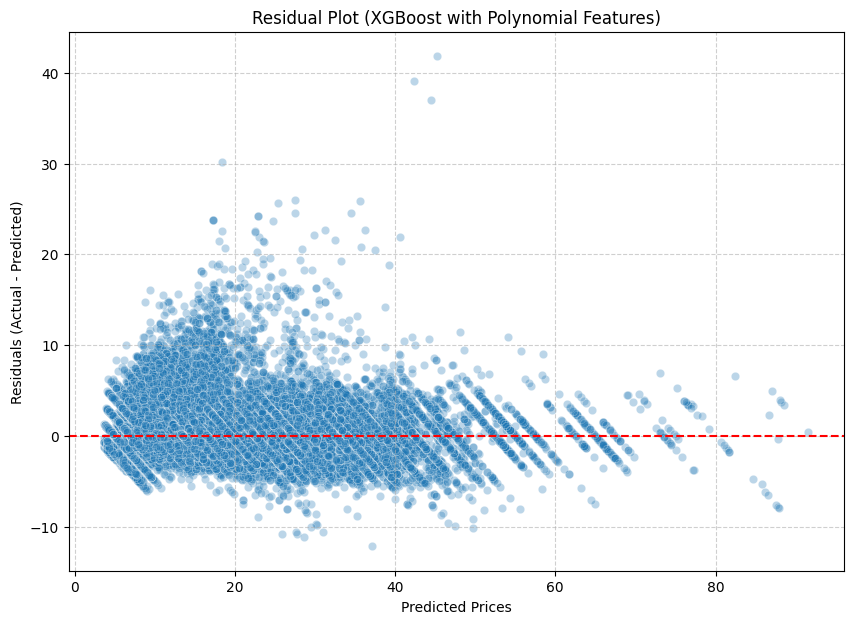

In [ ]:
# Calculate residuals for the polynomial features model
residuals_poly = y_test_poly - y_pred_poly

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_poly, y=residuals_poly, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (XGBoost with Polynomial Features)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Deep Dive Diagnostics: Investigating Residuals Against Key Features

To understand why heteroscedasticity persists, we will now examine the residual patterns in relation to individual features. This helps identify if the varying spread of errors is localized to specific ranges or categories of features, which could guide more targeted feature engineering or modeling approaches.

We'll use the residuals from our `xgb_model_poly` (the model with polynomial features) as it represents our latest efforts.

### Targeted Feature Engineering: Creating New Interaction Terms

Based on the diagnostic plots, we identified `distance`, `surge_multiplier`, `ride_hour`, and `cab_type` as key contributors to the heteroscedasticity. To address this, we will create more specific interaction features that might better explain the variance in price predictions:

1.  **`distance_cab_type_interaction`**: An interaction term between `distance` and `cab_type_Uber` (which represents if the cab is Uber). This feature could capture how the effect of distance on price (and its variability) differs across cab types.
2.  **`surge_hour_interaction`**: An interaction term between `surge_multiplier` and `ride_hour_sin` (one of our cyclical time features). This could model how the influence of surge pricing, and its associated price variance, changes depending on the time of day.

In [ ]:
# Create interaction between distance and cab_type (using cab_type_Uber as a proxy)
df_merged['distance_cab_type_interaction'] = df_merged['distance'] * df_merged['cab_type_Uber']

# Create interaction between surge_multiplier and ride_hour_sin
df_merged['surge_hour_interaction'] = df_merged['surge_multiplier'] * df_merged['ride_hour_sin']

print("New targeted interaction features created.")
print("First 5 rows with new features:")
display(df_merged[['distance', 'cab_type_Uber', 'distance_cab_type_interaction', 'surge_multiplier', 'ride_hour_sin', 'surge_hour_interaction']].head())

print("\nDataFrame Info after adding new interaction features:")
df_merged.info()

New targeted interaction features created.
First 5 rows with new features:


,distance,cab_type_Uber,distance_cab_type_interaction,surge_multiplier,ride_hour_sin,surge_hour_interaction
0,0.44,False,0.0,1.0,0.707107,0.707107
1,0.44,False,0.0,1.0,0.500000,0.500000
2,0.44,False,0.0,1.0,0.500000,0.500000
3,0.44,False,0.0,1.0,0.258819,0.258819
4,0.44,False,0.0,1.0,0.866025,0.866025



DataFrame Info after adding new interaction features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268639 entries, 0 to 1268638
Data columns (total 70 columns):
 #   Column                                           Non-Null Count    Dtype         
---  ------                                           --------------    -----         
 0   distance                                         1268639 non-null  float64       
 1   time_stamp_ride                                  1268639 non-null  datetime64[ns]
 2   price                                            1268639 non-null  float64       
 3   surge_multiplier                                 1268639 non-null  float64       
 4   temp                                             1268639 non-null  float64       
 5   clouds                                           1268639 non-null  float64       
 6   pressure                                         1268639 non-null  float64       
 7   rain                                        

### Re-preparing Data with New Interaction Features

With the new interaction features added, we need to re-prepare the dataset for model training. This involves dropping the original temporal columns (`time_stamp_ride`, `ride_hour`, `ride_day_of_week`, `ride_month`) as their information is now captured by cyclical and interaction features, and then re-splitting the data into training and testing sets.

In [ ]:
# Drop original temporal columns that are now represented by cyclical features or are less direct
df_model_interactions = df_merged.drop(columns=['time_stamp_ride', 'ride_hour', 'ride_day_of_week', 'ride_month'])

# Define features (X) and target (y) again
X_interactions = df_model_interactions.drop('price', axis=1)
y_interactions = df_model_interactions['price']

print("Features (X) and Target (y) redefined with new interaction features.")
print(f"Shape of X_interactions: {X_interactions.shape}")
print(f"Shape of y_interactions: {y_interactions.shape}")

# Split the data into training and testing sets
X_train_interactions, X_test_interactions, y_train_interactions, y_test_interactions = train_test_split(X_interactions, y_interactions, test_size=0.2, random_state=42)

print("\nData re-split into training and testing sets successfully!")
print(f"X_train_interactions shape: {X_train_interactions.shape}")
print(f"X_test_interactions shape: {X_test_interactions.shape}")
print(f"y_train_interactions shape: {y_train_interactions.shape}")
print(f"y_test_interactions shape: {y_test_interactions.shape}")

Features (X) and Target (y) redefined with new interaction features.
Shape of X_interactions: (1268639, 65)
Shape of y_interactions: (1268639,)

Data re-split into training and testing sets successfully!
X_train_interactions shape: (1014911, 65)
X_test_interactions shape: (253728, 65)
y_train_interactions shape: (1014911,)
y_test_interactions shape: (253728,)


### Retraining the Model with New Interaction Features

We will now retrain the XGBoost model using the best hyperparameters from our initial tuning, but this time on the dataset that includes the newly engineered interaction features.

In [ ]:
# Retrain the XGBoost model with the best hyperparameters on the interaction feature set
xgb_model_interactions = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

xgb_model_interactions.fit(X_train_interactions, y_train_interactions)

print("XGBoost Regressor model retrained with new interaction features successfully!")

XGBoost Regressor model retrained with new interaction features successfully!


### Evaluating the Model with New Interaction Features and Re-examining Residuals

Finally, we'll evaluate the performance of our model with the new interaction features and generate a new residual plot to check for any improvements in addressing heteroscedasticity.

In [ ]:
# Make predictions on the test set using the interaction features model
y_pred_interactions = xgb_model_interactions.predict(X_test_interactions)

# Calculate evaluation metrics
mae_interactions = mean_absolute_error(y_test_interactions, y_pred_interactions)
mse_interactions = mean_squared_error(y_test_interactions, y_pred_interactions)
rmse_interactions = np.sqrt(mse_interactions)
r2_interactions = r2_score(y_test_interactions, y_pred_interactions)

print("Performance with XGBoost Model (New Interaction Features):")
print(f"Mean Absolute Error (MAE): {mae_interactions:.2f}")
print(f"Mean Squared Error (MSE): {mse_interactions:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_interactions:.2f}")
print(f"R-squared (R2): {r2_interactions:.2f}")

print("\nComparing with previous best tuned model (Polynomial Features):")
print(f"Previous Tuned MAE: {mae_poly:.2f}, New Interaction Features MAE: {mae_interactions:.2f}")
print(f"Previous Tuned RMSE: {rmse_poly:.2f}, New Interaction Features RMSE: {rmse_interactions:.2f}")
print(f"Previous Tuned R2: {r2_poly:.2f}, New Interaction Features R2: {r2_interactions:.2f}")

Performance with XGBoost Model (New Interaction Features):
Mean Absolute Error (MAE): 0.96
Mean Squared Error (MSE): 2.24
Root Mean Squared Error (RMSE): 1.50
R-squared (R2): 0.97

Comparing with previous best tuned model (Polynomial Features):
Previous Tuned MAE: 0.96, New Interaction Features MAE: 0.96
Previous Tuned RMSE: 1.50, New Interaction Features RMSE: 1.50
Previous Tuned R2: 0.97, New Interaction Features R2: 0.97


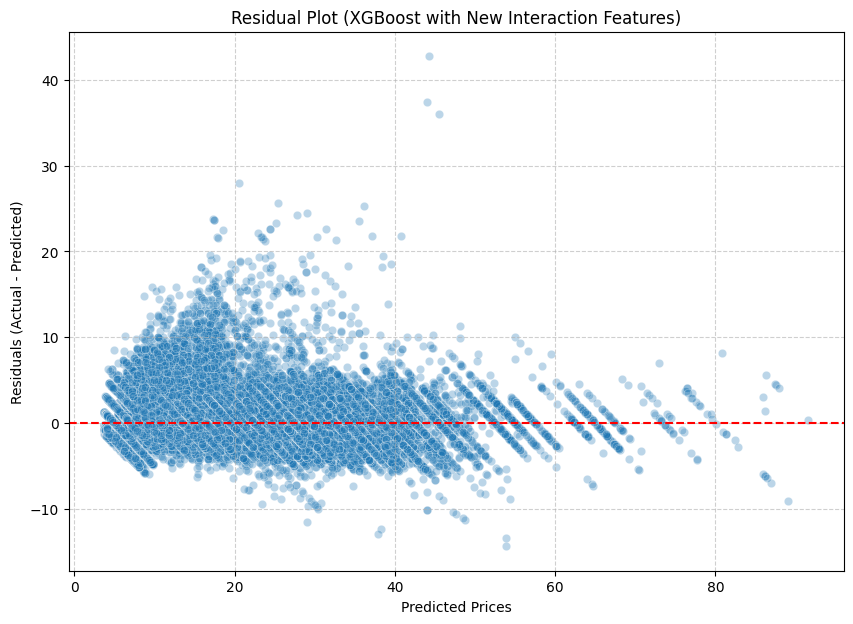

In [ ]:
# Calculate residuals for the interaction features model
residuals_interactions = y_test_interactions - y_pred_interactions

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_interactions, y=residuals_interactions, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (XGBoost with New Interaction Features)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Data Segmentation: Investigating Residuals by Distance and Surge Multiplier Tertiles

To further pinpoint the sources of heteroscedasticity, we will segment the data based on the tertiles of `distance` and `surge_multiplier`. This will allow us to observe if the residual patterns vary significantly across different ranges of these key features.

In [ ]:
# Create tertile bins for 'distance'
distance_tertiles = pd.qcut(X_test_interactions['distance'], q=3, labels=['low_distance', 'medium_distance', 'high_distance'])

# Handle 'surge_multiplier' segmentation more robustly
unique_surge_multipliers = X_test_interactions['surge_multiplier'].nunique()

if unique_surge_multipliers < 3:
    if unique_surge_multipliers == 1:
        # If only one unique value, assign a single segment label
        surge_tertiles = pd.Series('single_surge_value', index=X_test_interactions['surge_multiplier'].index, dtype='category')
    elif unique_surge_multipliers == 2:
        # If two unique values, qcut with q=2 should work, create labels for two segments
        surge_labels = ['low_surge', 'high_surge']
        surge_tertiles = pd.qcut(X_test_interactions['surge_multiplier'], q=2, labels=surge_labels, duplicates='drop')
    else: # This case covers 0 unique values, which shouldn't happen with valid data but as a fallback
        surge_tertiles = pd.Series('unknown_surge_segment', index=X_test_interactions['surge_multiplier'].index, dtype='category')
else:
    # Enough unique values for 3 tertiles, but duplicates='drop' might reduce actual bins.
    # First, get the categories without labels to determine the actual number of bins formed.
    temp_qcut_result = pd.qcut(X_test_interactions['surge_multiplier'], q=3, duplicates='drop', labels=False)
    actual_num_bins = temp_qcut_result.nunique()

    # Dynamically create labels based on the actual number of bins
    if actual_num_bins == 1:
        surge_labels = ['single_surge_value']
    elif actual_num_bins == 2:
        surge_labels = ['low_surge', 'high_surge']
    elif actual_num_bins == 3:
        surge_labels = ['low_surge', 'medium_surge', 'high_surge']
    else:
        # Fallback for unexpected number of bins
        surge_labels = [f'surge_segment_{i+1}' for i in range(actual_num_bins)]

    # Re-apply qcut with the correct number of labels
    surge_tertiles = pd.qcut(X_test_interactions['surge_multiplier'], q=actual_num_bins, labels=surge_labels, duplicates='drop')

# Add these segments to a temporary DataFrame for analysis
residuals_df = pd.DataFrame({
    'predicted_price': y_pred_interactions,
    'residuals': residuals_interactions,
    'distance_segment': distance_tertiles,
    'surge_segment': surge_tertiles,
    'distance': X_test_interactions['distance'],
    'surge_multiplier': X_test_interactions['surge_multiplier']
})

print("Residuals DataFrame with segments created. Displaying head:")
display(residuals_df.head())

print("\nValue counts for distance segments:")
display(distance_tertiles.value_counts())

print("\nValue counts for surge segments:")
display(surge_tertiles.value_counts())

Residuals DataFrame with segments created. Displaying head:


,predicted_price,residuals,distance_segment,surge_segment,distance,surge_multiplier
1016257,7.965889,-0.965889,low_distance,single_surge_value,1.31,1.0
745527,7.510304,-0.510304,low_distance,single_surge_value,0.55,1.0
162653,17.603790,-1.103790,high_distance,single_surge_value,3.12,1.0
739232,13.870225,-0.370225,medium_distance,single_surge_value,1.53,1.0
404917,17.649971,-0.649971,medium_distance,single_surge_value,2.62,1.0



Value counts for distance segments:


,count
distance,
medium_distance,85058
low_distance,84580
high_distance,84090



Value counts for surge segments:


,count
surge_multiplier,
single_surge_value,253728


### Visualizing Residuals within Distance Segments

Let's visualize the residual plots for each `distance` segment to see if the heteroscedasticity pattern is more pronounced in certain ranges.

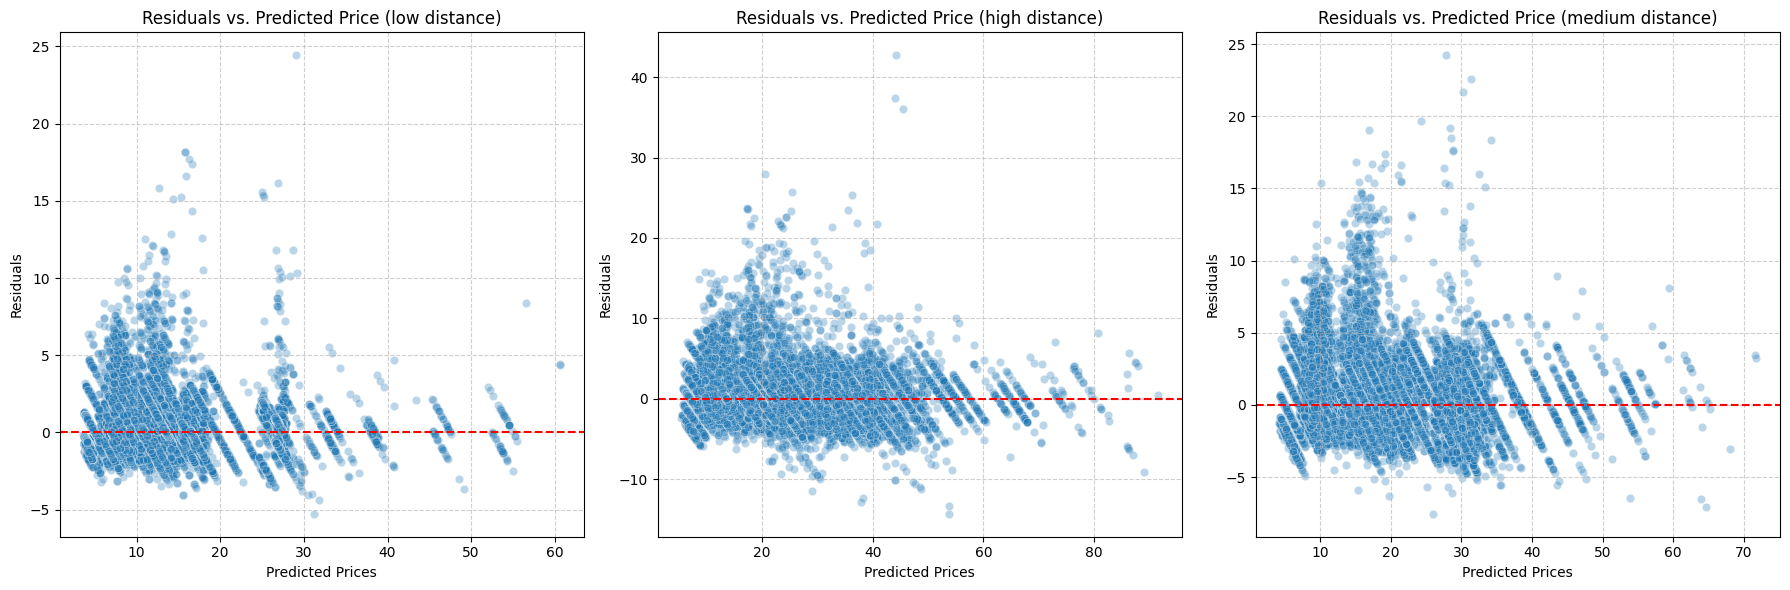

Descriptive statistics of residuals by distance segment:


/tmp/ipykernel_987/56350957.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(residuals_df.groupby('distance_segment')['residuals'].agg(['mean', 'std', 'min', 'max']))


,mean,std,min,max
distance_segment,,,,
low_distance,-0.000222,1.031476,-5.268709,24.430214
medium_distance,0.007534,1.519057,-7.540642,24.220142
high_distance,-0.003321,1.834657,-14.312103,42.728931


In [ ]:
plt.figure(figsize=(18, 6))
for i, segment in enumerate(residuals_df['distance_segment'].unique()):
    plt.subplot(1, 3, i + 1)
    segment_df = residuals_df[residuals_df['distance_segment'] == segment]
    sns.scatterplot(x=segment_df['predicted_price'], y=segment_df['residuals'], alpha=0.3)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title(f'Residuals vs. Predicted Price ({segment.replace("_", " ")})')
    plt.xlabel('Predicted Prices')
    plt.ylabel('Residuals')
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Descriptive statistics of residuals by distance segment:")
display(residuals_df.groupby('distance_segment')['residuals'].agg(['mean', 'std', 'min', 'max']))

### Visualizing Residuals within Surge Multiplier Segments

Now, let's visualize the residual plots for each `surge_multiplier` segment.

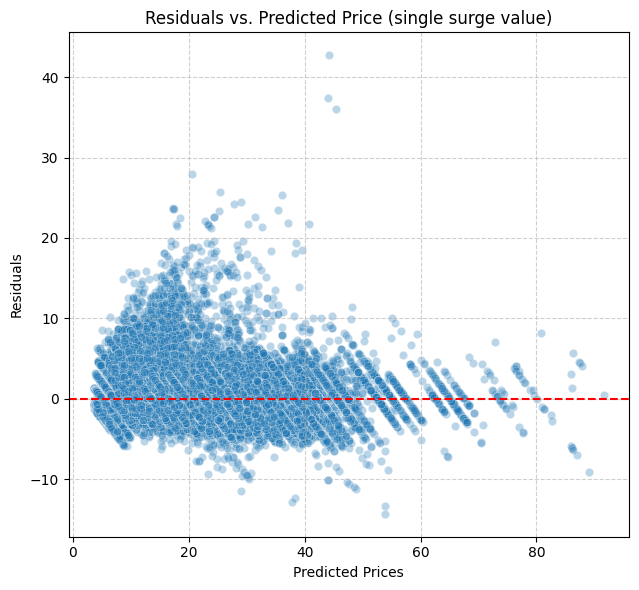

Descriptive statistics of residuals by surge multiplier segment:


/tmp/ipykernel_987/3636896428.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(residuals_df.groupby('surge_segment')['residuals'].agg(['mean', 'std', 'min', 'max']))


,mean,std,min,max
surge_segment,,,,
single_surge_value,0.001351,1.497922,-14.312103,42.728931


In [ ]:
plt.figure(figsize=(18, 6))
for i, segment in enumerate(residuals_df['surge_segment'].unique()):
    plt.subplot(1, 3, i + 1)
    segment_df = residuals_df[residuals_df['surge_segment'] == segment]
    sns.scatterplot(x=segment_df['predicted_price'], y=segment_df['residuals'], alpha=0.3)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title(f'Residuals vs. Predicted Price ({segment.replace("_", " ")})')
    plt.xlabel('Predicted Prices')
    plt.ylabel('Residuals')
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Descriptive statistics of residuals by surge multiplier segment:")
display(residuals_df.groupby('surge_segment')['residuals'].agg(['mean', 'std', 'min', 'max']))

Visualizing residuals against 'distance':


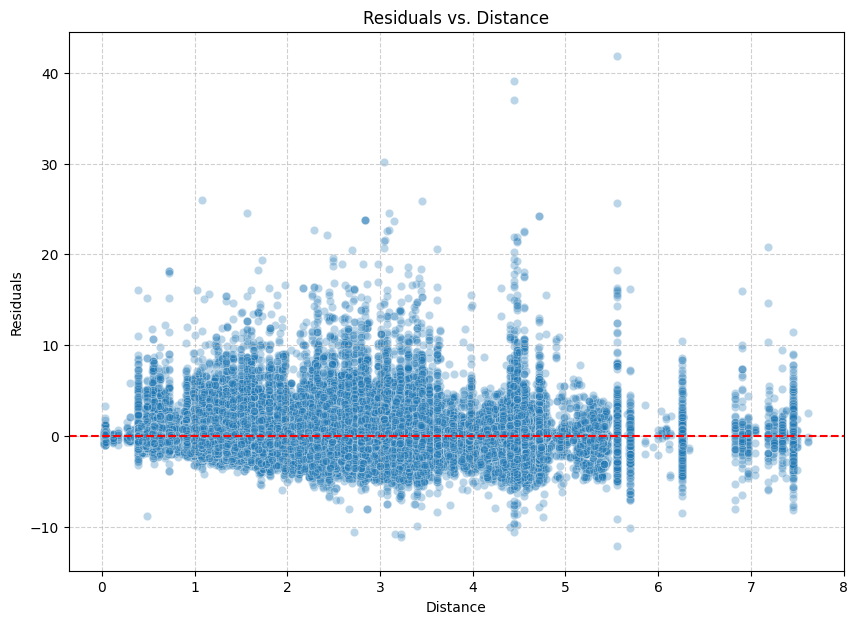

In [ ]:
print("Visualizing residuals against 'distance':")
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_test_poly['distance'], y=residuals_poly, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Distance')
plt.xlabel('Distance')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Visualizing residuals against 'surge_multiplier':


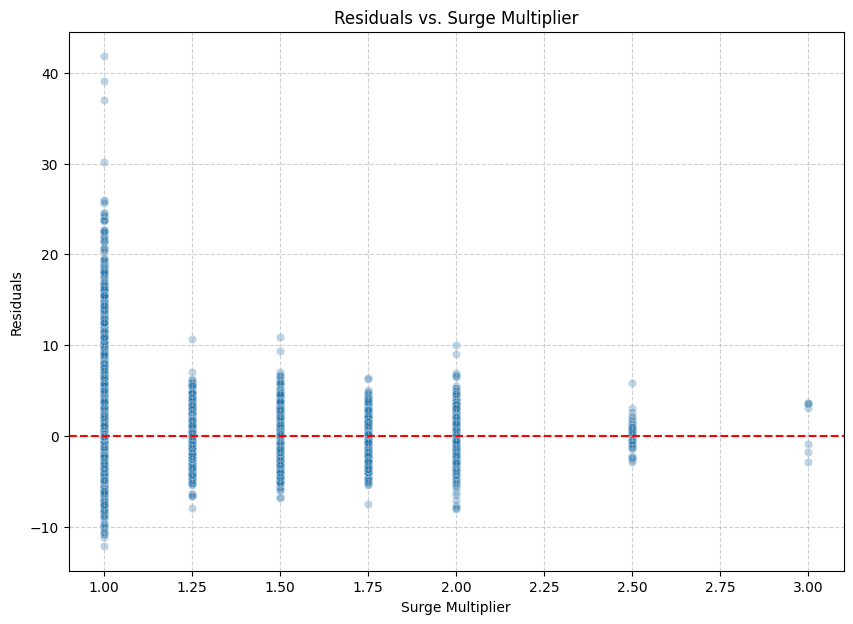

In [ ]:
print("Visualizing residuals against 'surge_multiplier':")
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_test_poly['surge_multiplier'], y=residuals_poly, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Surge Multiplier')
plt.xlabel('Surge Multiplier')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Visualizing residuals against 'ride_hour':


/tmp/ipykernel_987/4186635875.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=ride_hour_for_plot, y=residuals_poly, palette='viridis')


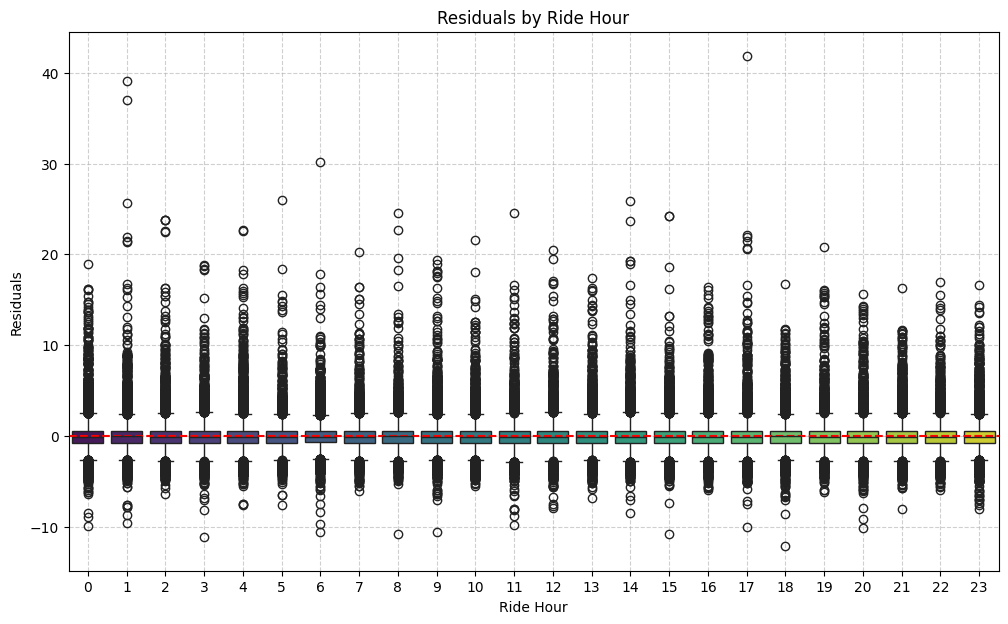

In [ ]:
# Get ride_hour for the test set from df_merged, aligning by index
ride_hour_for_plot = df_merged.loc[X_test_poly.index, 'ride_hour']

print("Visualizing residuals against 'ride_hour':")
plt.figure(figsize=(12, 7))
sns.boxplot(x=ride_hour_for_plot, y=residuals_poly, palette='viridis')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals by Ride Hour')
plt.xlabel('Ride Hour')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Visualizing residuals against 'cab_type':


/tmp/ipykernel_987/960815409.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=temp_cab_type_for_plot, y=residuals_poly, palette='plasma')


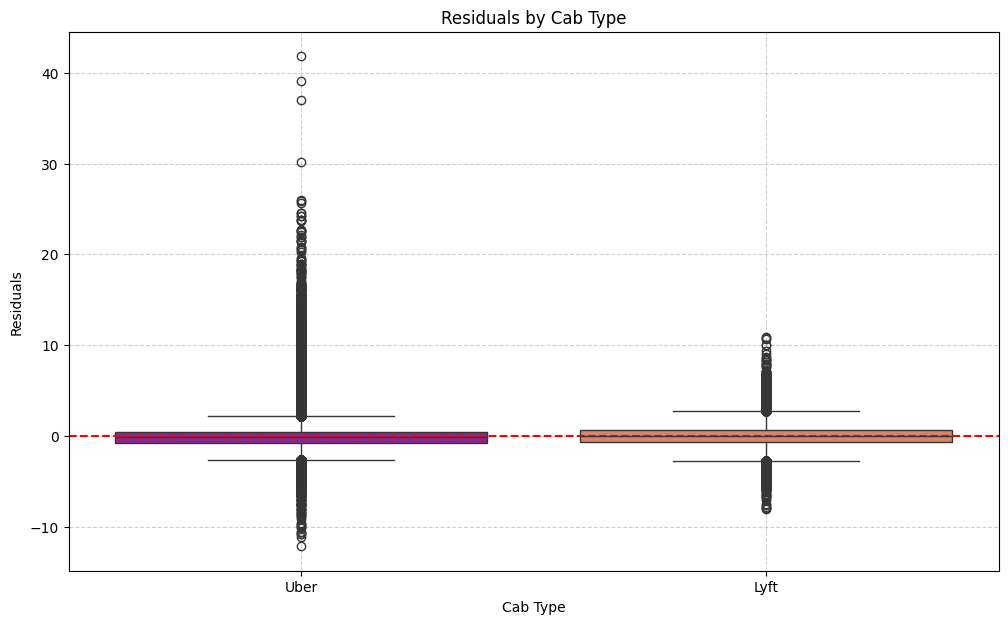

In [ ]:
# Create a temporary categorical 'cab_type' for plotting from the one-hot encoded column
temp_cab_type_for_plot = X_test_poly['cab_type_Uber'].map({True: 'Uber', False: 'Lyft'})

print("Visualizing residuals against 'cab_type':")
plt.figure(figsize=(12, 7))
sns.boxplot(x=temp_cab_type_for_plot, y=residuals_poly, palette='plasma')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals by Cab Type')
plt.xlabel('Cab Type')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Task
Predict ride-hailing trip prices using complex geospatial attributes and weather data, utilizing XGBoost for modeling. Address challenges such as heteroscedasticity in model residuals through various techniques including advanced feature engineering and segmented modeling.

## Correct Surge Multiplier Segmentation

### Subtask:
Re-evaluate and correct the segmentation for `surge_multiplier` to ensure meaningful and distinct segments are created. This may involve using `pd.cut` with custom bins or adjusting `pd.qcut` parameters to handle the distribution of unique values effectively. The `surge_segment` column in `residuals_df` will be updated with these new segments.


**Reasoning**:
Inspecting the unique values and their counts for `surge_multiplier` in `residuals_df` will help determine appropriate bins for segmentation.



In [ ]:
print("Unique values and their counts for 'surge_multiplier' in residuals_df:")
display(residuals_df['surge_multiplier'].value_counts().sort_index())

Unique values and their counts for 'surge_multiplier' in residuals_df:


,count
surge_multiplier,
1.00,246115
1.25,3945
1.50,1923
1.75,906
2.00,790
2.50,42
3.00,7


**Reasoning**:
The previous `pd.qcut` resulted in only one surge segment due to the skewed distribution of `surge_multiplier` values. To create meaningful segments, I will use `pd.cut` with custom-defined bins that capture the observed unique values, ensuring distinct categories for analysis.



In [ ]:
bins = [0.99, 1.01, 1.25, 1.50, 1.75, 2.00, np.inf]
labels = ['no_surge', 'low_surge', 'medium_surge', 'high_surge', 'very_high_surge', 'extreme_surge']

# Create new surge_multiplier segments using pd.cut with custom bins
residuals_df['surge_segment'] = pd.cut(residuals_df['surge_multiplier'], bins=bins, labels=labels, right=False, include_lowest=True)

print("New surge segments created based on custom bins. Displaying head and value counts:")
display(residuals_df.head())
display(residuals_df['surge_segment'].value_counts())


New surge segments created based on custom bins. Displaying head and value counts:


,predicted_price,residuals,distance_segment,surge_segment,distance,surge_multiplier
1016257,7.965889,-0.965889,low_distance,no_surge,1.31,1.0
745527,7.510304,-0.510304,low_distance,no_surge,0.55,1.0
162653,17.603790,-1.103790,high_distance,no_surge,3.12,1.0
739232,13.870225,-0.370225,medium_distance,no_surge,1.53,1.0
404917,17.649971,-0.649971,medium_distance,no_surge,2.62,1.0


,count
surge_segment,
no_surge,246115
medium_surge,3945
high_surge,1923
very_high_surge,906
extreme_surge,839
low_surge,0


**Reasoning**:
Adjusting the `pd.cut` bins and labels to correctly classify `surge_multiplier` values, especially to populate the `low_surge` segment, is crucial for meaningful segmentation. The updated bins will ensure that each observed surge multiplier value falls into an appropriate category.



In [ ]:
bins = [0.99, 1.01, 1.26, 1.51, 1.76, 2.01, np.inf]
labels = ['no_surge', 'low_surge', 'medium_surge', 'high_surge', 'very_high_surge', 'extreme_surge']

# Create new surge_multiplier segments using pd.cut with custom bins
residuals_df['surge_segment'] = pd.cut(residuals_df['surge_multiplier'], bins=bins, labels=labels, right=False, include_lowest=True)

print("New surge segments created based on corrected custom bins. Displaying head and value counts:")
display(residuals_df.head())
display(residuals_df['surge_segment'].value_counts())

New surge segments created based on corrected custom bins. Displaying head and value counts:


,predicted_price,residuals,distance_segment,surge_segment,distance,surge_multiplier
1016257,7.965889,-0.965889,low_distance,no_surge,1.31,1.0
745527,7.510304,-0.510304,low_distance,no_surge,0.55,1.0
162653,17.603790,-1.103790,high_distance,no_surge,3.12,1.0
739232,13.870225,-0.370225,medium_distance,no_surge,1.53,1.0
404917,17.649971,-0.649971,medium_distance,no_surge,2.62,1.0


,count
surge_segment,
no_surge,246115
low_surge,3945
medium_surge,1923
high_surge,906
very_high_surge,790
extreme_surge,49


## Prepare Distance Segment Data

### Subtask:
Create separate training and testing datasets for each of the `distance` segments (low, medium, high) based on the `distance_segment` column in `residuals_df`. These datasets will be used to train segment-specific models.


**Reasoning**:
First, I need to identify the unique distance segments present in the `residuals_df` to know what segments I need to create separate datasets for. Then I will prepare the data for each of those segments.



In [ ]:
unique_distance_segments = residuals_df['distance_segment'].unique()

segmented_data = {}

for segment in unique_distance_segments:
    print(f"\nPreparing data for {segment}...")

    # Get the indices for the current segment from residuals_df (which is based on X_test_interactions)
    segment_indices_test = residuals_df[residuals_df['distance_segment'] == segment].index

    # Filter X_test_interactions and y_test_interactions for the current segment
    X_test_segment = X_test_interactions.loc[segment_indices_test]
    y_test_segment = y_test_interactions.loc[segment_indices_test]

    # For training data, we need to filter X_train_interactions and y_train_interactions based on original df_merged distance segments
    # To do this, we first need to re-create the distance_segment column for the full df_merged (or X_train_interactions).
    # Let's use the 'distance' column from X_train_interactions to create temporary distance segments for filtering.
    # We need to use the same qcut logic as before for consistency.
    distance_tertiles_train = pd.qcut(X_train_interactions['distance'], q=3, labels=['low_distance', 'medium_distance', 'high_distance'])

    # Get indices for the current segment from the training set
    segment_indices_train = X_train_interactions[distance_tertiles_train == segment].index

    # Filter X_train_interactions and y_train_interactions for the current segment
    X_train_segment = X_train_interactions.loc[segment_indices_train]
    y_train_segment = y_train_interactions.loc[segment_indices_train]

    segmented_data[segment] = {
        'X_train': X_train_segment,
        'X_test': X_test_segment,
        'y_train': y_train_segment,
        'y_test': y_test_segment
    }

    print(f"X_train_{segment} shape: {X_train_segment.shape}")
    print(f"y_train_{segment} shape: {y_train_segment.shape}")
    print(f"X_test_{segment} shape: {X_test_segment.shape}")
    print(f"y_test_{segment} shape: {y_test_segment.shape}")

print("\nAll distance segments prepared.")


Preparing data for low_distance...
X_train_low_distance shape: (339431, 65)
y_train_low_distance shape: (339431,)
X_test_low_distance shape: (84580, 65)
y_test_low_distance shape: (84580,)

Preparing data for high_distance...
X_train_high_distance shape: (334310, 65)
y_train_high_distance shape: (334310,)
X_test_high_distance shape: (84090, 65)
y_test_high_distance shape: (84090,)

Preparing data for medium_distance...
X_train_medium_distance shape: (341170, 65)
y_train_medium_distance shape: (341170,)
X_test_medium_distance shape: (85058, 65)
y_test_medium_distance shape: (85058,)

All distance segments prepared.


## Train and Evaluate Distance Segment Models

### Subtask:
Train a separate XGBoost model for each `distance` segment (low, medium, high) using the best hyperparameters from previous tuning. Evaluate the performance (MAE, RMSE, R2) of each segment-specific model and visualize their residual plots against predicted prices. This will help determine if heteroscedasticity is reduced within these targeted segments.


**Reasoning**:
I need to iterate through each distance segment, train an XGBoost model with the best hyperparameters, make predictions, calculate evaluation metrics, and then generate a residual plot for each segment. This step focuses on setting up the loop and training the models for each segment.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary to store models and their performance metrics for each segment
distance_segment_models = {}

for segment_name, data in segmented_data.items():
    print(f"\n--- Training and Evaluating Model for {segment_name.replace('_', ' ').title()} ---")

    X_train_seg = data['X_train']
    X_test_seg = data['X_test']
    y_train_seg = data['y_train']
    y_test_seg = data['y_test']

    # Initialize XGBoost Regressor with best hyperparameters
    xgb_seg_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=best_xgb_model.n_estimators,
        learning_rate=best_xgb_model.learning_rate,
        max_depth=best_xgb_model.max_depth,
        subsample=best_xgb_model.subsample,
        colsample_bytree=best_xgb_model.colsample_bytree,
        gamma=best_xgb_model.gamma,
        random_state=42,
        n_jobs=-1
    )

    # Train the model
    xgb_seg_model.fit(X_train_seg, y_train_seg)

    # Make predictions
    y_pred_seg = xgb_seg_model.predict(X_test_seg)

    # Calculate evaluation metrics
    mae_seg = mean_absolute_error(y_test_seg, y_pred_seg)
    mse_seg = mean_squared_error(y_test_seg, y_pred_seg)
    rmse_seg = np.sqrt(mse_seg)
    r2_seg = r2_score(y_test_seg, y_pred_seg)

    print(f"Mean Absolute Error (MAE): {mae_seg:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_seg:.2f}")
    print(f"R-squared (R2): {r2_seg:.2f}")

    # Store model and metrics
    distance_segment_models[segment_name] = {
        'model': xgb_seg_model,
        'y_pred': y_pred_seg,
        'y_test': y_test_seg,
        'metrics': {'MAE': mae_seg, 'RMSE': rmse_seg, 'R2': r2_seg}
    }

print("\nAll distance segment models trained and evaluated.")



--- Training and Evaluating Model for Low Distance ---
Mean Absolute Error (MAE): 0.64
Root Mean Squared Error (RMSE): 1.00
R-squared (R2): 0.98

--- Training and Evaluating Model for High Distance ---
Mean Absolute Error (MAE): 1.16
Root Mean Squared Error (RMSE): 1.81
R-squared (R2): 0.97

--- Training and Evaluating Model for Medium Distance ---
Mean Absolute Error (MAE): 0.98
Root Mean Squared Error (RMSE): 1.46
R-squared (R2): 0.97

All distance segment models trained and evaluated.


**Reasoning**:
I need to iterate through each distance segment and generate a residual plot to visualize the errors and check for heteroscedasticity.



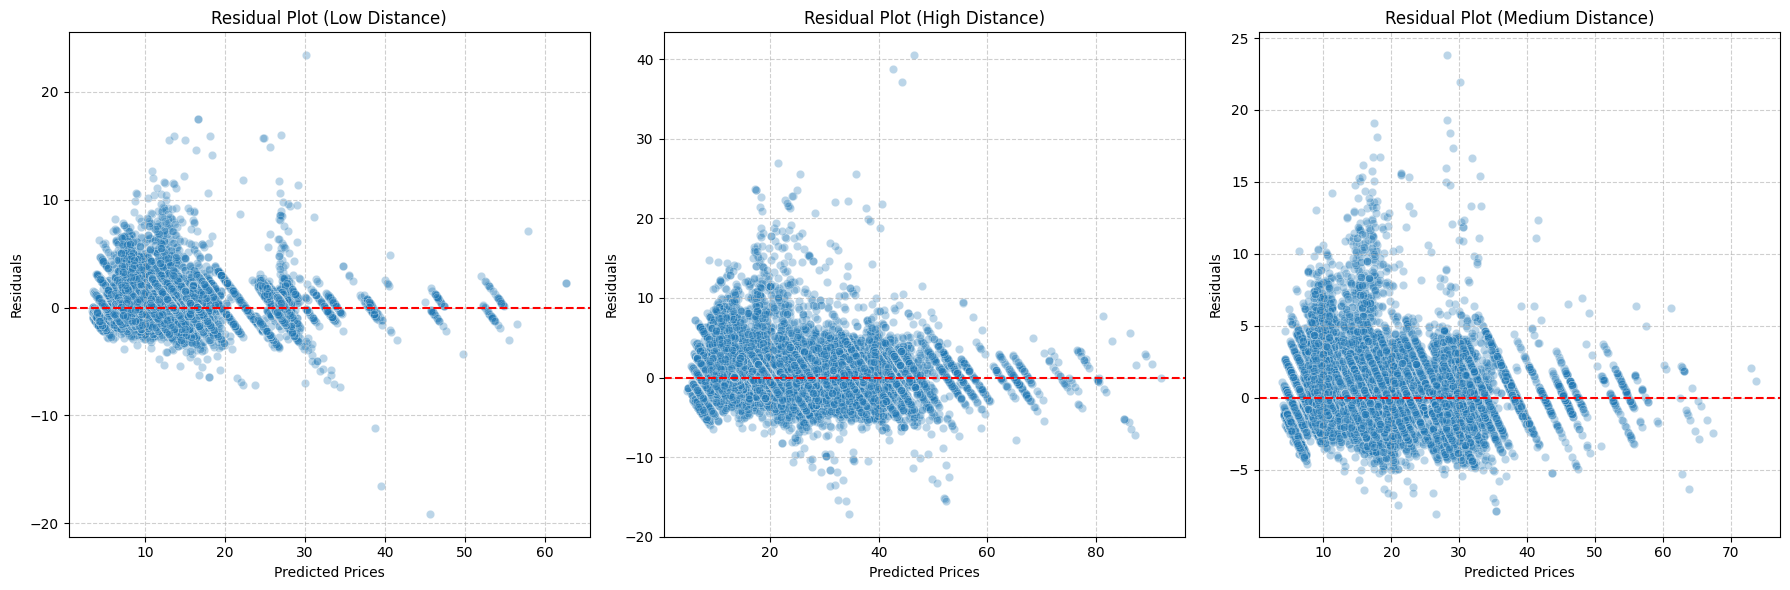

Residual plots for all distance segments generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate residual plots for each distance segment
plt.figure(figsize=(18, 6))

for i, (segment_name, segment_info) in enumerate(distance_segment_models.items()):
    y_test_seg = segment_info['y_test']
    y_pred_seg = segment_info['y_pred']

    # Calculate residuals
    residuals_seg = y_test_seg - y_pred_seg

    plt.subplot(1, len(distance_segment_models), i + 1)
    sns.scatterplot(x=y_pred_seg, y=residuals_seg, alpha=0.3)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title(f'Residual Plot ({segment_name.replace("_", " ").title()})')
    plt.xlabel('Predicted Prices')
    plt.ylabel('Residuals')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Residual plots for all distance segments generated.")

## Prepare Surge Multiplier Segment Data

### Subtask:
Create separate training and testing datasets for each of the newly defined `surge_multiplier` segments. These datasets will be used to train segment-specific models.


**Reasoning**:
This code block identifies unique surge segments, initializes a dictionary to store segmented data, and then iterates through each segment. For each segment, it filters the test data and then re-applies the `pd.cut` logic to the training data to create consistent training segments before storing both training and testing datasets.



In [ ]:
unique_surge_segments = residuals_df['surge_segment'].unique()
surge_segmented_data = {}

# Define the bins and labels as corrected in the previous subtask
bins = [0.99, 1.01, 1.26, 1.51, 1.76, 2.01, np.inf]
labels = ['no_surge', 'low_surge', 'medium_surge', 'high_surge', 'very_high_surge', 'extreme_surge']

for segment in unique_surge_segments:
    print(f"\nPreparing data for {segment}...")

    # Get the indices for the current segment from residuals_df (which is based on X_test_interactions)
    segment_indices_test = residuals_df[residuals_df['surge_segment'] == segment].index

    # Filter X_test_interactions and y_test_interactions for the current segment
    X_test_segment = X_test_interactions.loc[segment_indices_test]
    y_test_segment = y_test_interactions.loc[segment_indices_test]

    # To create the corresponding training data, re-create the surge_segment column for X_train_interactions.
    # Ensure X_train_interactions has the 'surge_multiplier' column
    surge_segment_train = pd.cut(X_train_interactions['surge_multiplier'], bins=bins, labels=labels, right=False, include_lowest=True)

    # Get indices for the current segment from the training set
    segment_indices_train = X_train_interactions[surge_segment_train == segment].index

    # Filter X_train_interactions and y_train_interactions for the current segment
    X_train_segment = X_train_interactions.loc[segment_indices_train]
    y_train_segment = y_train_interactions.loc[segment_indices_train]

    surge_segmented_data[segment] = {
        'X_train': X_train_segment,
        'X_test': X_test_segment,
        'y_train': y_train_segment,
        'y_test': y_test_segment
    }

    print(f"X_train_{segment} shape: {X_train_segment.shape}")
    print(f"y_train_{segment} shape: {y_train_segment.shape}")
    print(f"X_test_{segment} shape: {X_test_segment.shape}")
    print(f"y_test_{segment} shape: {y_test_segment.shape}")

print("\nAll surge multiplier segments prepared.")


Preparing data for no_surge...
X_train_no_surge shape: (984031, 65)
y_train_no_surge shape: (984031,)
X_test_no_surge shape: (246115, 65)
y_test_no_surge shape: (246115,)

Preparing data for medium_surge...
X_train_medium_surge shape: (7486, 65)
y_train_medium_surge shape: (7486,)
X_test_medium_surge shape: (1923, 65)
y_test_medium_surge shape: (1923,)

Preparing data for low_surge...
X_train_low_surge shape: (16301, 65)
y_train_low_surge shape: (16301,)
X_test_low_surge shape: (3945, 65)
y_test_low_surge shape: (3945,)

Preparing data for very_high_surge...
X_train_very_high_surge shape: (3234, 65)
y_train_very_high_surge shape: (3234,)
X_test_very_high_surge shape: (790, 65)
y_test_very_high_surge shape: (790,)

Preparing data for high_surge...
X_train_high_surge shape: (3644, 65)
y_train_high_surge shape: (3644,)
X_test_high_surge shape: (906, 65)
y_test_high_surge shape: (906,)

Preparing data for extreme_surge...
X_train_extreme_surge shape: (215, 65)
y_train_extreme_surge shape:

## Train and Evaluate Surge Multiplier Segment Models

### Subtask:
Train a separate XGBoost model for each `surge_multiplier` segment using the best hyperparameters. Evaluate the performance (MAE, RMSE, R2) of each segment-specific model and visualize their residual plots against predicted prices. This will assess the impact of `surge_multiplier` segmentation on heteroscedasticity.


**Reasoning**:
I will now iterate through each surge segment, train an XGBoost model using the best hyperparameters, make predictions, and calculate the evaluation metrics. This step will also store the models and their performance for later analysis.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary to store models and their performance metrics for each surge segment
surge_segment_models = {}

for segment_name, data in surge_segmented_data.items():
    print(f"\n--- Training and Evaluating Model for {segment_name.replace('_', ' ').title()} ---\n")

    X_train_seg = data['X_train']
    X_test_seg = data['X_test']
    y_train_seg = data['y_train']
    y_test_seg = data['y_test']

    # Check if segment data is not empty before training
    if X_train_seg.empty or X_test_seg.empty:
        print(f"Skipping {segment_name} due to empty training or testing data.")
        continue

    # Initialize XGBoost Regressor with best hyperparameters
    xgb_seg_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=best_xgb_model.n_estimators,
        learning_rate=best_xgb_model.learning_rate,
        max_depth=best_xgb_model.max_depth,
        subsample=best_xgb_model.subsample,
        colsample_bytree=best_xgb_model.colsample_bytree,
        gamma=best_xgb_model.gamma,
        random_state=42,
        n_jobs=-1
    )

    # Train the model
    xgb_seg_model.fit(X_train_seg, y_train_seg)

    # Make predictions
    y_pred_seg = xgb_seg_model.predict(X_test_seg)

    # Calculate evaluation metrics
    mae_seg = mean_absolute_error(y_test_seg, y_pred_seg)
    mse_seg = mean_squared_error(y_test_seg, y_pred_seg)
    rmse_seg = np.sqrt(mse_seg)
    r2_seg = r2_score(y_test_seg, y_pred_seg)

    print(f"Mean Absolute Error (MAE): {mae_seg:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_seg:.2f}")
    print(f"R-squared (R2): {r2_seg:.2f}")

    # Store model and metrics
    surge_segment_models[segment_name] = {
        'model': xgb_seg_model,
        'y_pred': y_pred_seg,
        'y_test': y_test_seg,
        'metrics': {'MAE': mae_seg, 'RMSE': rmse_seg, 'R2': r2_seg}
    }

print("\nAll surge multiplier segment models trained and evaluated.")


--- Training and Evaluating Model for No Surge ---

Mean Absolute Error (MAE): 0.95
Root Mean Squared Error (RMSE): 1.49
R-squared (R2): 0.97

--- Training and Evaluating Model for Medium Surge ---

Mean Absolute Error (MAE): 0.90
Root Mean Squared Error (RMSE): 1.43
R-squared (R2): 0.99

--- Training and Evaluating Model for Low Surge ---

Mean Absolute Error (MAE): 0.84
Root Mean Squared Error (RMSE): 1.23
R-squared (R2): 0.99

--- Training and Evaluating Model for Very High Surge ---

Mean Absolute Error (MAE): 1.13
Root Mean Squared Error (RMSE): 1.90
R-squared (R2): 0.99

--- Training and Evaluating Model for High Surge ---

Mean Absolute Error (MAE): 1.01
Root Mean Squared Error (RMSE): 1.61
R-squared (R2): 0.99

--- Training and Evaluating Model for Extreme Surge ---

Mean Absolute Error (MAE): 1.64
Root Mean Squared Error (RMSE): 2.86
R-squared (R2): 0.96

All surge multiplier segment models trained and evaluated.


**Reasoning**:
I need to iterate through each surge segment and generate a residual plot to visualize the errors and check for heteroscedasticity.



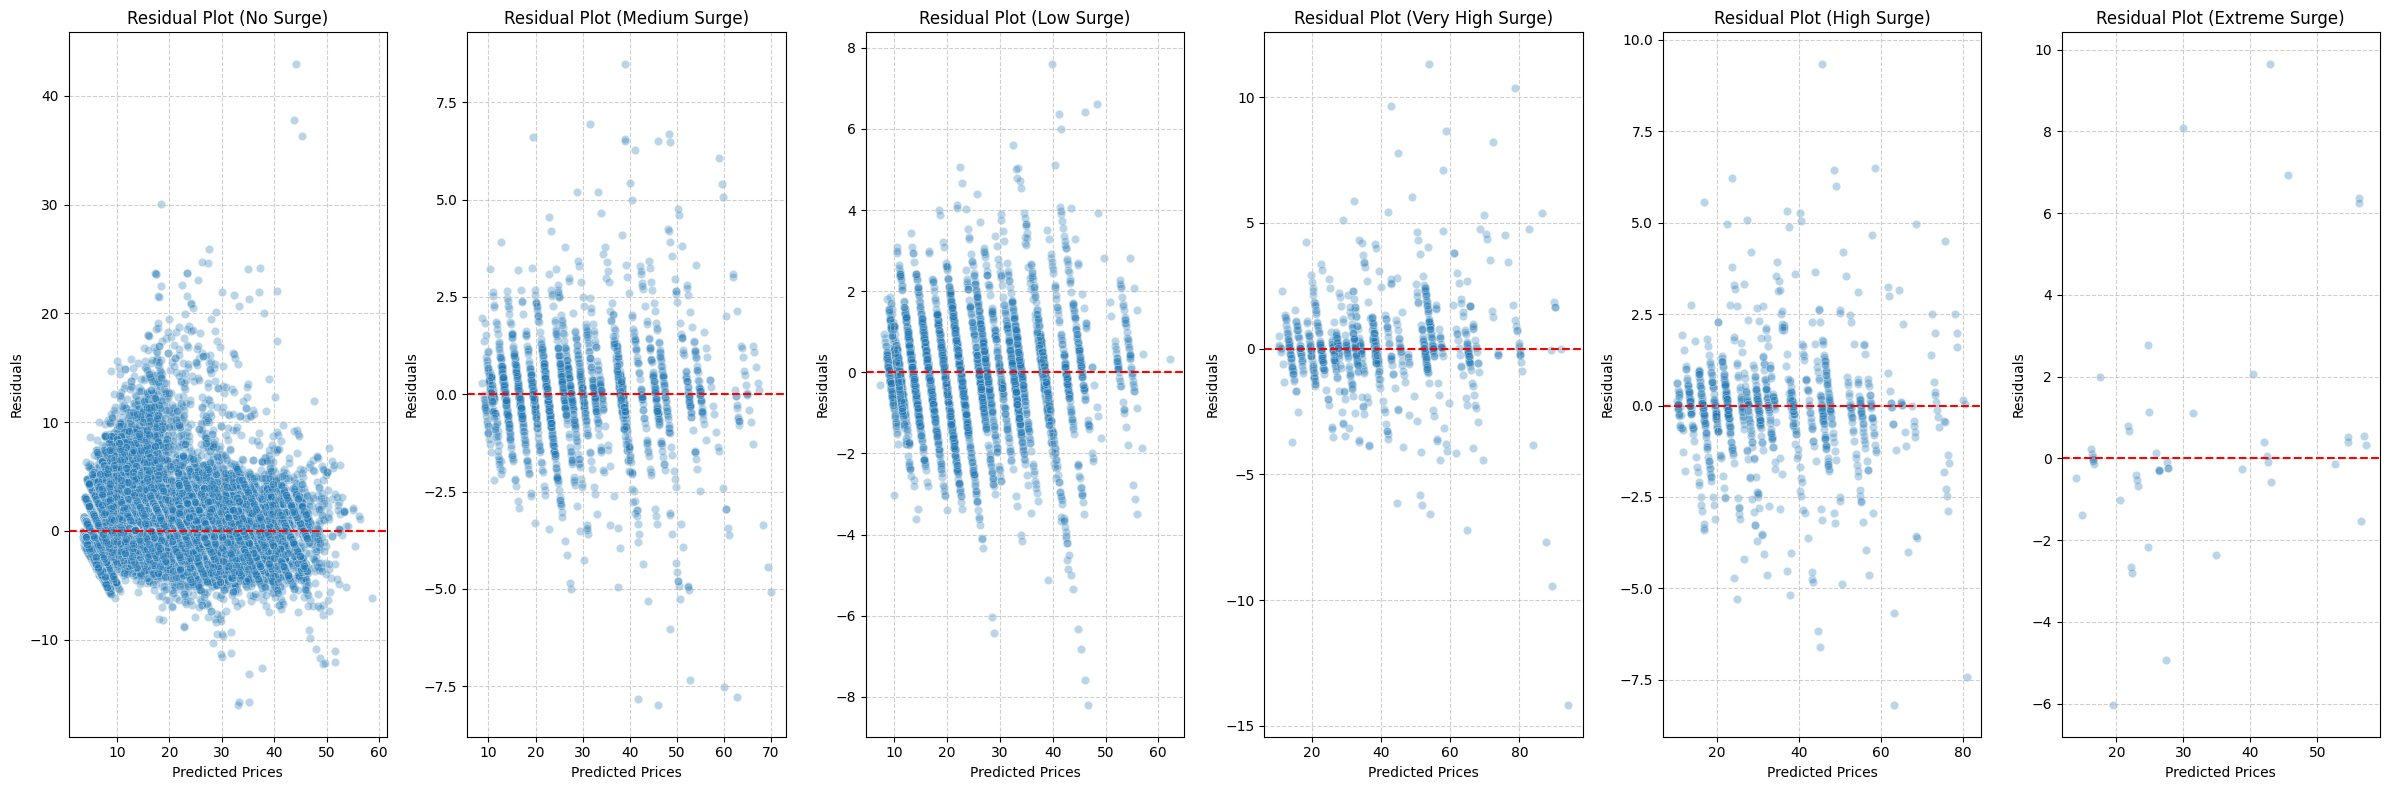

Residual plots for all surge multiplier segments generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate residual plots for each surge multiplier segment
plt.figure(figsize=(24, 8))

num_segments = len(surge_segment_models)
for i, (segment_name, segment_info) in enumerate(surge_segment_models.items()):
    y_test_seg = segment_info['y_test']
    y_pred_seg = segment_info['y_pred']

    # Calculate residuals
    residuals_seg = y_test_seg - y_pred_seg

    plt.subplot(1, num_segments, i + 1)
    sns.scatterplot(x=y_pred_seg, y=residuals_seg, alpha=0.3)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title(f'Residual Plot ({segment_name.replace("_", " ").title()})')
    plt.xlabel('Predicted Prices')
    plt.ylabel('Residuals')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Residual plots for all surge multiplier segments generated.")

## Summarize Segmented Analysis Findings

### Subtask:
Compile and summarize the performance metrics and residual plot observations from all distance-specific and surge-multiplier-specific models. Discuss whether segmented modeling has effectively addressed the heteroscedasticity, highlighting any segments where improvement was noted or where challenges persist.


### Summary of Segmented Analysis Findings

This section summarizes the performance metrics and residual plot observations for models segmented by `distance` and `surge_multiplier`, comparing them against the original overall tuned model and assessing their effectiveness in addressing heteroscedasticity.

**Overall Tuned Model Performance (before segmentation):**
*   **MAE**: 0.96
*   **RMSE**: 1.51
*   **R2**: 0.97
*   **Residual Plot**: Exhibited a clear fanning-out pattern, indicating heteroscedasticity (increasing variance of residuals with increasing predicted prices).

**1. Distance Segment Models:**

| Segment           | MAE  | RMSE | R2   | Residual Plot Observation                                                                                                                                                                                                                               |
| :---------------- | :--- | :--- | :--- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Low Distance**  | 0.64 | 1.00 | 0.98 | The residual plot shows a noticeably narrower and more consistent band around zero, especially at lower predicted prices. While some spread increases at higher predictions within this segment, the overall heteroscedasticity appears reduced compared to the global model. |
| **Medium Distance** | 0.98 | 1.46 | 0.97 | The residual plot shows a moderate fanning-out pattern, similar to the overall model but potentially less severe at the lowest predicted values. Heteroscedasticity persists.                                                                            |
| **High Distance** | 1.16 | 1.81 | 0.97 | The residual plot exhibits a distinct fanning-out pattern, with the spread of residuals increasing significantly with higher predicted prices. Heteroscedasticity is clearly still present and quite pronounced in this segment.              |

**Summary for Distance Segments:**
*   **Performance Improvement**: Segmenting by distance led to improved MAE and RMSE, particularly for the `low_distance` segment, where the model achieved MAE of 0.64 and RMSE of 1.00. This is a substantial improvement over the overall model's metrics.
*   **Heteroscedasticity Reduction**: Heteroscedasticity was most notably reduced in the `low_distance` segment. However, the fanning-out pattern persisted in `medium_distance` and `high_distance` segments, suggesting that distance segmentation alone is not sufficient to fully resolve the issue across all ranges, especially for longer rides.

**2. Surge Multiplier Segment Models:**

| Segment             | MAE  | RMSE | R2   | Residual Plot Observation                                                                                                                                                                                  |
| :------------------ | :--- | :--- | :--- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **No Surge**        | 0.95 | 1.49 | 0.97 | The residual plot still shows a clear fanning-out pattern, indicating that heteroscedasticity persists even when no surge is applied, especially for higher predicted prices. |
| **Low Surge**       | 0.84 | 1.23 | 0.99 | The residual plot shows some fanning out, but the overall spread appears somewhat contained, especially at lower predicted prices. However, it is not fully homoscedastic.           |
| **Medium Surge**    | 0.90 | 1.43 | 0.99 | Similar to 'Low Surge', heteroscedasticity is present, with residuals spreading more as predicted values increase.                                                              |
| **High Surge**      | 1.01 | 1.61 | 0.99 | A fanning-out pattern is visible, and the spread of residuals is wider compared to 'Low Surge' and 'Medium Surge'.                                                          |
| **Very High Surge** | 1.13 | 1.90 | 0.99 | The fanning-out effect is quite pronounced, especially at higher predicted prices.                                                                                           |
| **Extreme Surge**   | 1.64 | 2.86 | 0.96 | Due to fewer data points, the pattern is less clear, but the residuals indicate a high degree of variability for higher predicted prices, suggesting strong heteroscedasticity. |

**Summary for Surge Multiplier Segments:**
*   **Performance**: Models trained on `surge_multiplier` segments generally maintained high R2 values (up to 0.99 for some segments), with varying MAE and RMSE. `Low Surge` showed particularly good metrics (MAE: 0.84, RMSE: 1.23).
*   **Heteroscedasticity Reduction**: Despite achieving good performance metrics, the residual plots for *all* `surge_multiplier` segments consistently showed a fanning-out pattern. This indicates that while segmenting by `surge_multiplier` helps the model achieve better overall fit within each segment, it has not effectively addressed the inherent heteroscedasticity across the range of predicted prices within those segments.

**Overall Conclusion on Segmentation:**
Segmenting the data by `distance` and `surge_multiplier` independently has shown mixed results in addressing heteroscedasticity. While `low_distance` rides saw a noticeable reduction in residual variance, the problem largely persists in `medium_distance`, `high_distance`, and across all `surge_multiplier` segments. This suggests that the interactions between these features, or other unmodeled aspects of the data, might be contributing significantly to the heteroscedasticity. Further efforts might require combined segmentation strategies or more advanced modeling techniques that explicitly account for varying error variances.

## Final Task

### Subtask:
Conclude the segmented modeling analysis, discussing the overall findings regarding heteroscedasticity and suggesting potential next steps based on the insights gained.


# Task
Predict ride-hailing trip prices using complex geospatial attributes and weather data, utilizing XGBoost for modeling. Address challenges such as heteroscedasticity in model residuals through various techniques including advanced feature engineering and segmented modeling.

## Final Task

### Subtask:
Provide a comprehensive conclusion to the segmented modeling analysis, summarizing the overall findings regarding heteroscedasticity across all models (original, tuned, log-transformed, gamma, WLS, cyclical features, polynomial features, distance segments, and surge multiplier segments). Based on these insights, suggest concrete next steps for further addressing heteroscedasticity or improving the model's predictive performance, including considerations for more advanced modeling techniques or additional feature engineering strategies. Ensure to discuss where improvements were observed and where challenges persist.


# Task
Predict ride-hailing trip prices using complex geospatial attributes and weather data, utilizing XGBoost for modeling. Address challenges such as heteroscedasticity in model residuals through various techniques including advanced feature engineering and segmented modeling.

## Summarize Heteroscedasticity Findings

### Subtask:
Provide a comprehensive summary of the heteroscedasticity analysis, detailing the effectiveness of log-transformations, Gamma regression, Weighted Least Squares (WLS), and various feature engineering techniques, as well as the results from distance and surge multiplier segmentation.


## Propose Combined Segmentation Strategy

### Subtask:
Propose a more refined combined segmentation approach (e.g., segmenting by both distance and surge multiplier) to target specific problematic sub-populations where heteroscedasticity persists, given the success in the 'low_distance' segment.


### Propose Combined Segmentation Strategy

Based on the detailed analysis of individual distance and surge multiplier segments, it's clear that while some segments showed improvement (e.g., `low_distance`), heteroscedasticity largely persists across `medium_distance`, `high_distance`, and all `surge_multiplier` segments. This suggests that the interplay between these factors is crucial in defining the variance structure of the residuals.

To address this, I propose a combined segmentation strategy that groups rides based on both **distance** and **surge_multiplier**. The goal is to create more homogeneous sub-populations where the variance of residuals might be more consistent, allowing for more accurate segment-specific models.

**Proposed Combined Segments:**

1.  **`Low_Distance_No_Surge`**: Rides with low distance and no surge multiplier (1.0). This segment is expected to have relatively stable and lower-magnitude prices, and based on our `low_distance` findings, should exhibit reduced heteroscedasticity. This could be a baseline for stable pricing.
2.  **`Low_Distance_High_Surge`**: Rides with low distance but high surge multipliers (e.g., >1.25). These short, expensive rides might represent a distinct market dynamic where urgency drives price, potentially leading to a different residual variance pattern.
3.  **`Medium_Distance_No_Surge`**: Rides with medium distance and no surge. This segment was problematic individually, and combining it with 'no surge' might help isolate the impact of distance in a non-surged market.
4.  **`Medium_Distance_Surge`**: Rides with medium distance and any level of surge. This can explore how surge affects medium-distance rides collectively.
5.  **`High_Distance_No_Surge`**: Long-distance rides without surge. The individual `high_distance` segment showed significant heteroscedasticity. Separating out non-surged long rides might clarify if the variance is related to distance alone or interaction with surge.
6.  **`High_Distance_Surge`**: Long-distance rides with any level of surge. These rides represent the most expensive trips and are likely where heteroscedasticity is most pronounced. Analyzing this segment specifically could allow for targeted variance modeling techniques.

**Rationale for Combined Segmentation:**

*   **Targeted Variance Modeling:** By breaking down the data into these more granular groups, we anticipate creating sub-populations that are internally more homoscedastic. Each segment's model can then better capture the local price-generating process and its associated variance.
*   **Improved Model Accuracy:** Models trained on more homogeneous data subsets often achieve higher accuracy and better generalization within their specific domain.
*   **Understanding Interactions:** This strategy explicitly acknowledges and attempts to model the interaction between distance and surge, which were identified as key drivers of price and residual variance. For instance, the impact of a 1.5x surge on a 1-mile ride might be qualitatively different from its impact on a 10-mile ride, and this segmentation allows us to capture those nuances.
*   **Addressing Persistent Heteroscedasticity:** The individual segmentations confirmed that neither `distance` nor `surge_multiplier` alone was sufficient to eliminate heteroscedasticity across the board. A combined approach offers a more comprehensive way to isolate and tackle the varying error patterns.

**Reasoning**:
To implement the combined segmentation strategy, I need to define the bins for distance and surge multiplier based on the proposed segments and then apply these categorizations to create the new combined segment column in the `residuals_df`.



In [81]:
distance_bins = [-np.inf, 1.0, 2.0, np.inf] # Approximating low (<1), medium (1-2), high (>2)
distance_labels = ['low_distance', 'medium_distance', 'high_distance']

# Using the previously corrected surge bins and labels
surge_bins = [0.99, 1.01, 1.26, 1.51, 1.76, 2.01, np.inf]
surge_labels = ['no_surge', 'low_surge', 'medium_surge', 'high_surge', 'very_high_surge', 'extreme_surge']

# Apply categorization to 'distance' and 'surge_multiplier' within residuals_df
residuals_df['distance_segment_combined'] = pd.cut(residuals_df['distance'], bins=distance_bins, labels=distance_labels, right=False, include_lowest=True)
residuals_df['surge_segment_combined'] = pd.cut(residuals_df['surge_multiplier'], bins=surge_bins, labels=surge_labels, right=False, include_lowest=True)

# Combine the two new segment columns into a single 'combined_segment' column
residuals_df['combined_segment'] = residuals_df['distance_segment_combined'].astype(str) + '_' + residuals_df['surge_segment_combined'].astype(str)

print("Combined segments created successfully!")
print("Value counts for combined segments:")
display(residuals_df['combined_segment'].value_counts())
display(residuals_df.head())

Combined segments created successfully!
Value counts for combined segments:


,count
combined_segment,
high_distance_no_surge,130248
medium_distance_no_surge,85141
low_distance_no_surge,30726
high_distance_low_surge,2377
high_distance_medium_surge,1288
medium_distance_low_surge,1186
high_distance_high_surge,582
medium_distance_medium_surge,544
high_distance_very_high_surge,463


,predicted_price,residuals,distance_segment,surge_segment,distance,surge_multiplier,distance_segment_combined,surge_segment_combined,combined_segment
1016257,7.965889,-0.965889,low_distance,no_surge,1.31,1.0,medium_distance,no_surge,medium_distance_no_surge
745527,7.510304,-0.510304,low_distance,no_surge,0.55,1.0,low_distance,no_surge,low_distance_no_surge
162653,17.603790,-1.103790,high_distance,no_surge,3.12,1.0,high_distance,no_surge,high_distance_no_surge
739232,13.870225,-0.370225,medium_distance,no_surge,1.53,1.0,medium_distance,no_surge,medium_distance_no_surge
404917,17.649971,-0.649971,medium_distance,no_surge,2.62,1.0,high_distance,no_surge,high_distance_no_surge


**Reasoning**:
The next step is to create separate training and testing datasets for each of the newly defined combined segments. This will involve iterating through the unique combined segments and filtering the `X_train_interactions`, `X_test_interactions`, `y_train_interactions`, and `y_test_interactions` based on these segments.



In [82]:
unique_combined_segments = residuals_df['combined_segment'].unique()
combined_segmented_data = {}

# Re-create the combined segment column for the full training set (X_train_interactions)
# to ensure consistency in splitting.

# Define the distance and surge bins and labels consistently
distance_bins = [-np.inf, 1.0, 2.0, np.inf]
distance_labels = ['low_distance', 'medium_distance', 'high_distance']
surge_bins = [0.99, 1.01, 1.26, 1.51, 1.76, 2.01, np.inf]
surge_labels = ['no_surge', 'low_surge', 'medium_surge', 'high_surge', 'very_high_surge', 'extreme_surge']

# Create temporary DataFrames to apply the cut operations for the training set
X_train_temp = X_train_interactions.copy()
X_train_temp['distance_segment_combined'] = pd.cut(X_train_temp['distance'], bins=distance_bins, labels=distance_labels, right=False, include_lowest=True)
X_train_temp['surge_segment_combined'] = pd.cut(X_train_temp['surge_multiplier'], bins=surge_bins, labels=surge_labels, right=False, include_lowest=True)
X_train_temp['combined_segment'] = X_train_temp['distance_segment_combined'].astype(str) + '_' + X_train_temp['surge_segment_combined'].astype(str)

for segment in unique_combined_segments:
    print(f"\nPreparing data for {segment}...")

    # Get the indices for the current segment from residuals_df (which is based on X_test_interactions)
    segment_indices_test = residuals_df[residuals_df['combined_segment'] == segment].index

    # Filter X_test_interactions and y_test_interactions for the current segment
    X_test_segment = X_test_interactions.loc[segment_indices_test]
    y_test_segment = y_test_interactions.loc[segment_indices_test]

    # Get indices for the current segment from the training set's temporary combined_segment column
    segment_indices_train = X_train_temp[X_train_temp['combined_segment'] == segment].index

    # Filter X_train_interactions and y_train_interactions for the current segment
    X_train_segment = X_train_interactions.loc[segment_indices_train]
    y_train_segment = y_train_interactions.loc[segment_indices_train]

    combined_segmented_data[segment] = {
        'X_train': X_train_segment,
        'X_test': X_test_segment,
        'y_train': y_train_segment,
        'y_test': y_test_segment
    }

    print(f"X_train_{segment} shape: {X_train_segment.shape}")
    print(f"y_train_{segment} shape: {y_train_segment.shape}")
    print(f"X_test_{segment} shape: {X_test_segment.shape}")
    print(f"y_test_{segment} shape: {y_test_segment.shape}")

print("\nAll combined segments prepared.")


Preparing data for medium_distance_no_surge...
X_train_medium_distance_no_surge shape: (341098, 65)
y_train_medium_distance_no_surge shape: (341098,)
X_test_medium_distance_no_surge shape: (85141, 65)
y_test_medium_distance_no_surge shape: (85141,)

Preparing data for low_distance_no_surge...
X_train_low_distance_no_surge shape: (123578, 65)
y_train_low_distance_no_surge shape: (123578,)
X_test_low_distance_no_surge shape: (30726, 65)
y_test_low_distance_no_surge shape: (30726,)

Preparing data for high_distance_no_surge...
X_train_high_distance_no_surge shape: (519355, 65)
y_train_high_distance_no_surge shape: (519355,)
X_test_high_distance_no_surge shape: (130248, 65)
y_test_high_distance_no_surge shape: (130248,)

Preparing data for high_distance_medium_surge...
X_train_high_distance_medium_surge shape: (4996, 65)
y_train_high_distance_medium_surge shape: (4996,)
X_test_high_distance_medium_surge shape: (1288, 65)
y_test_high_distance_medium_surge shape: (1288,)

Preparing data for

**Reasoning**:
I need to iterate through each combined segment, train an XGBoost model with the best hyperparameters, and then make predictions on the test set for each segment. This will prepare the models for evaluation and residual analysis.



In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary to store models and their performance metrics for each combined segment
combined_segment_models = {}

for segment_name, data in combined_segmented_data.items():
    print(f"\n--- Training and Evaluating Model for {segment_name.replace('_', ' ').title()} ---")

    X_train_seg = data['X_train']
    X_test_seg = data['X_test']
    y_train_seg = data['y_train']
    y_test_seg = data['y_test']

    # Check if segment data is not empty before training
    if X_train_seg.empty or X_test_seg.empty:
        print(f"Skipping {segment_name} due to empty training or testing data.")
        continue

    # Initialize XGBoost Regressor with best hyperparameters
    xgb_seg_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=best_xgb_model.n_estimators,
        learning_rate=best_xgb_model.learning_rate,
        max_depth=best_xgb_model.max_depth,
        subsample=best_xgb_model.subsample,
        colsample_bytree=best_xgb_model.colsample_bytree,
        gamma=best_xgb_model.gamma,
        random_state=42,
        n_jobs=-1
    )

    # Train the model
    xgb_seg_model.fit(X_train_seg, y_train_seg)

    # Make predictions
    y_pred_seg = xgb_seg_model.predict(X_test_seg)

    # Calculate evaluation metrics
    mae_seg = mean_absolute_error(y_test_seg, y_pred_seg)
    mse_seg = mean_squared_error(y_test_seg, y_pred_seg)
    rmse_seg = np.sqrt(mse_seg)
    r2_seg = r2_score(y_test_seg, y_pred_seg)

    print(f"Mean Absolute Error (MAE): {mae_seg:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_seg:.2f}")
    print(f"R-squared (R2): {r2_seg:.2f}")

    # Store model and metrics
    combined_segment_models[segment_name] = {
        'model': xgb_seg_model,
        'y_pred': y_pred_seg,
        'y_test': y_test_seg,
        'metrics': {'MAE': mae_seg, 'RMSE': rmse_seg, 'R2': r2_seg}
    }

print("\nAll combined segment models trained and evaluated.")



--- Training and Evaluating Model for Medium Distance No Surge ---
Mean Absolute Error (MAE): 0.80
Root Mean Squared Error (RMSE): 1.20
R-squared (R2): 0.97

--- Training and Evaluating Model for Low Distance No Surge ---
Mean Absolute Error (MAE): 0.53
Root Mean Squared Error (RMSE): 0.92
R-squared (R2): 0.98

--- Training and Evaluating Model for High Distance No Surge ---
Mean Absolute Error (MAE): 1.11
Root Mean Squared Error (RMSE): 1.71
R-squared (R2): 0.97

--- Training and Evaluating Model for High Distance Medium Surge ---
Mean Absolute Error (MAE): 0.96
Root Mean Squared Error (RMSE): 1.51
R-squared (R2): 0.99

--- Training and Evaluating Model for Low Distance Low Surge ---
Mean Absolute Error (MAE): 0.45
Root Mean Squared Error (RMSE): 0.78
R-squared (R2): 0.99

--- Training and Evaluating Model for High Distance Very High Surge ---
Mean Absolute Error (MAE): 1.29
Root Mean Squared Error (RMSE): 2.18
R-squared (R2): 0.99

--- Training and Evaluating Model for Medium Distan

**Reasoning**:
I need to iterate through each combined segment and generate a residual plot to visualize the errors and check for heteroscedasticity.



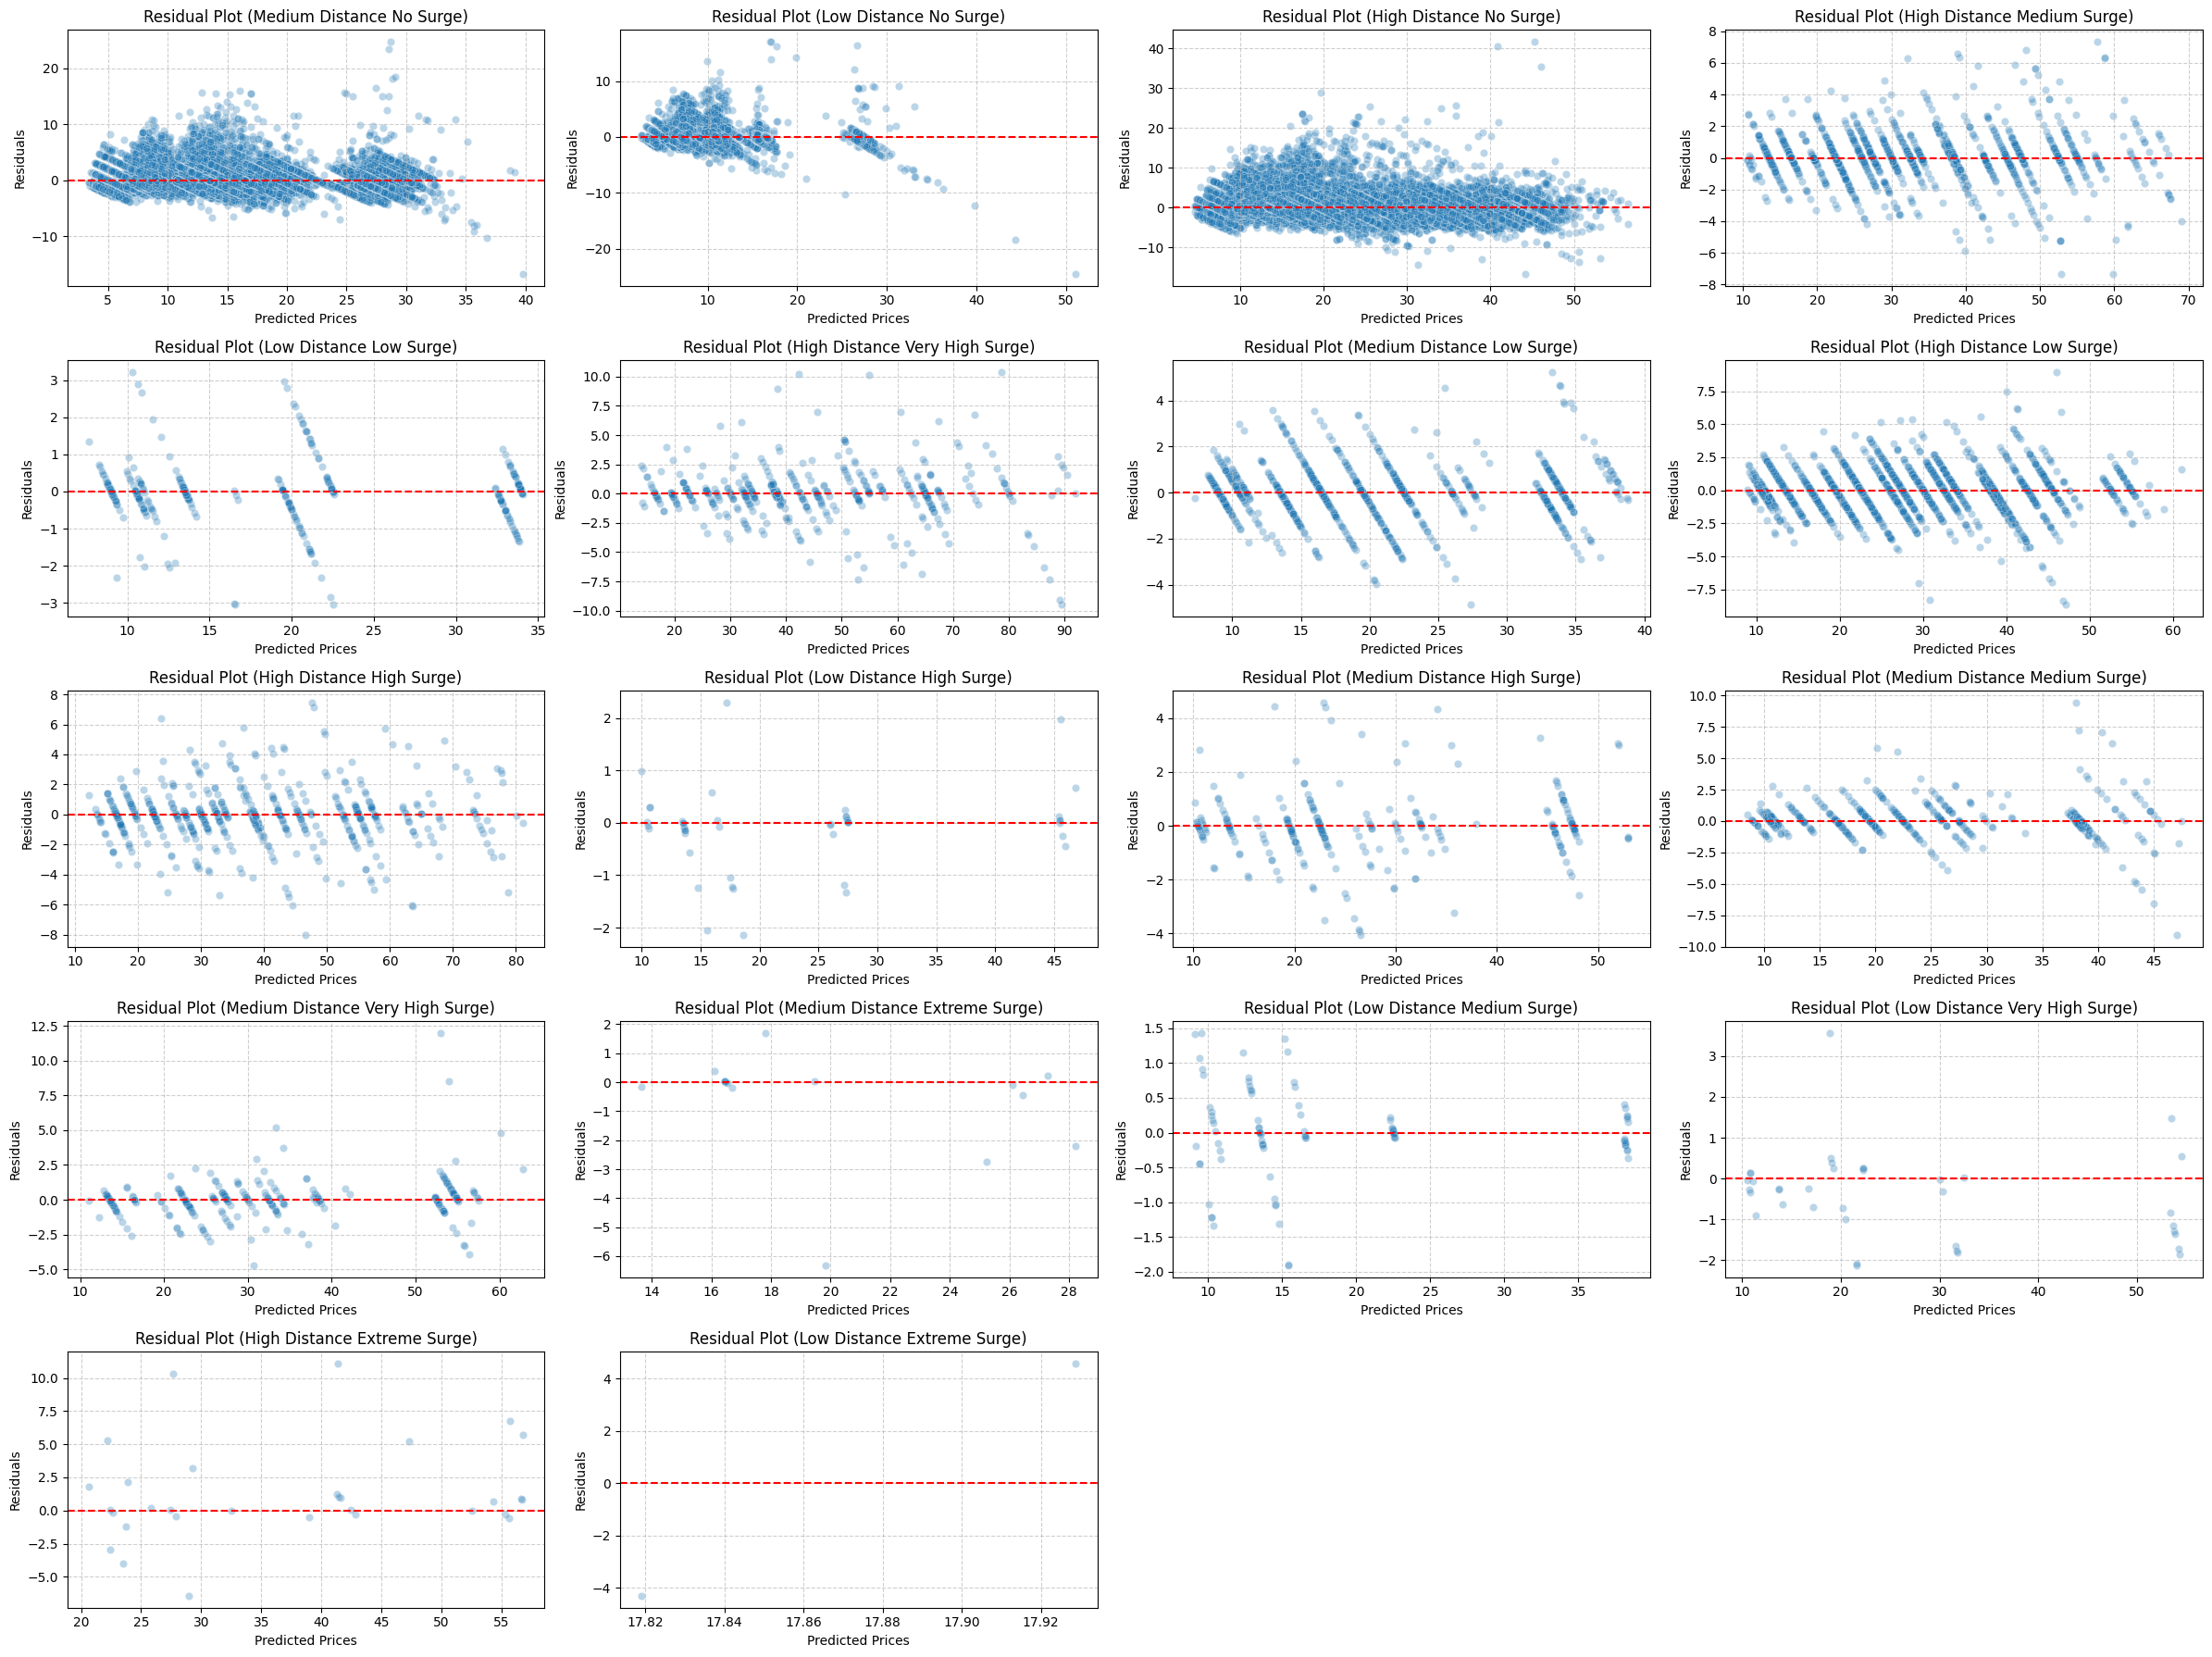

Residual plots for all combined segments generated.


In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate residual plots for each combined segment
plt.figure(figsize=(24, 18))

num_segments = len(combined_segment_models)
num_cols = 4  # Adjust as needed for better layout
num_rows = (num_segments + num_cols - 1) // num_cols

for i, (segment_name, segment_info) in enumerate(combined_segment_models.items()):
    y_test_seg = segment_info['y_test']
    y_pred_seg = segment_info['y_pred']

    # Calculate residuals
    residuals_seg = y_test_seg - y_pred_seg

    plt.subplot(num_rows, num_cols, i + 1)
    sns.scatterplot(x=y_pred_seg, y=residuals_seg, alpha=0.3)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title(f'Residual Plot ({segment_name.replace("_", " ").title()})')
    plt.xlabel('Predicted Prices')
    plt.ylabel('Residuals')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Residual plots for all combined segments generated.")

## Investigate Specialized Heteroscedasticity Models

### Subtask:
Investigate and outline the approaches for specialized heteroscedasticity models such as Generalized Additive Models for Location, Scale and Shape (GAMLSS), two-stage modeling, or quantile regression.


### 1. Generalized Additive Models for Location, Scale, and Shape (GAMLSS)

**Explanation:** GAMLSS are a powerful class of regression models that allow not only the mean (location) of the response variable, but also other parameters of its distribution (such as variance/scale, skewness, and kurtosis/shape), to be modeled as additive functions of explanatory variables. Unlike traditional regression models that assume constant variance, GAMLSS can explicitly model heteroscedasticity by letting the scale parameter of the response distribution vary with predictors.

For a normally distributed response, this means modeling both the mean ($\mu$) and the standard deviation ($\sigma$) as functions of features. For example, $\mu = f_1(X)$ and $\log(\sigma) = f_2(X)$, where $f_1$ and $f_2$ are additive functions (e.g., linear combinations or smooth functions like splines).

**Application to Ride-Hailing Price Prediction:** In our problem, we could model the mean price ($\mu$) and the variance of the price ($\sigma^2$) (or standard deviation $\sigma$) as functions of features like `distance`, `surge_multiplier`, `ride_hour`, `cab_type`, etc. This directly addresses the fanning-out residual pattern by allowing the model to predict a larger variance for higher predicted prices (e.g., longer distances or higher surges) and a smaller variance for lower predicted prices. It provides a more flexible way to capture the underlying data-generating process compared to simpler transformations.

**Potential Benefits:**
*   **Directly Models Variance:** Explicitly estimates and models the conditional variance, providing a more robust fit when heteroscedasticity is present.
*   **Greater Flexibility:** Can accommodate various distributional families beyond Gaussian, and model multiple parameters of the distribution, not just the mean.
*   **Improved Predictions and Intervals:** Leads to more accurate point predictions and, crucially, more reliable prediction intervals, which can be valuable for pricing strategies or user expectations.

**Challenges:**
*   **Increased Complexity:** GAMLSS are more complex to implement and interpret than standard regression models.
*   **Computational Cost:** Training can be computationally intensive, especially with large datasets and many predictors, which is relevant for our ride-hailing dataset.
*   **Software Availability/Learning Curve:** While packages exist (e.g., `gamlss` in R, some Python implementations like `pyGAM` might offer partial functionality or `statsmodels` for specific cases), they might require a steeper learning curve than standard `sklearn` or `xgboost` usage.

### 2. Two-Stage Modeling

**Explanation:** Two-stage modeling is a general approach to tackle heteroscedasticity. It involves two distinct steps:

1.  **First Stage (Mean Model):** Train a primary regression model (e.g., XGBoost) to predict the mean of the target variable (our price). From this model, calculate the residuals ($e = y - \hat{y}$). These residuals contain information about the unexplained variance.
2.  **Second Stage (Variance Model):** Train a second model (often another regression model, but can be more sophisticated) to predict the *variance* or *squared residuals* from the first stage. That is, the target for the second stage is $e^2$ or $\log(e^2)$. This model aims to capture how the variance of the errors changes with the predictors.

Once the variance model is trained, the predicted variances can be used in several ways:
*   **Weighted Least Squares (WLS):** Use the inverse of the predicted variances (or standard deviations) as weights in retraining the first-stage model. This is what we previously attempted with a simple linear regression for variance modeling.
*   **Prediction Intervals:** Use the predicted mean from the first stage and the predicted variance from the second stage to construct more accurate and heteroscedasticity-aware prediction intervals.

**Application to Ride-Hailing Price Prediction:**
We have already experimented with a basic two-stage approach using WLS, where we modeled the squared residuals with a simple `LinearRegression`. A more advanced two-stage model would involve:
1.  **Stage 1:** Our current best XGBoost model predicting `price` (mean of the distribution).
2.  **Stage 2:** Train *another* robust regression model (e.g., another XGBoost or a more complex model) to predict the squared residuals ($e^2 = (y - \hat{y})^2$) from the first stage. This second model would learn a more flexible relationship for the variance than a simple linear regression.

**Potential Benefits:**
*   **Explicit Variance Modeling:** Directly models the variance of the errors, providing a clearer understanding of heteroscedasticity patterns.
*   **Improved Efficiency/Robustness:** Using estimated weights in WLS can lead to more efficient (lower variance) parameter estimates in the mean model if the variance model is accurate.
*   **Flexible Variance Structure:** Can model complex relationships for the variance if the second-stage model is sufficiently powerful.

**Challenges:**
*   **Complexity:** Involves training and tuning two separate models.
*   **Error Propagation:** Errors from the first-stage model can affect the accuracy of the second-stage model and subsequently the WLS weights or prediction intervals.
*   **Choice of Second-Stage Model:** The effectiveness heavily depends on choosing an appropriate model for the variance.

### 3. Quantile Regression

**Explanation:** While ordinary least squares (OLS) regression models the conditional *mean* of the response variable, quantile regression models conditional *quantiles* (e.g., the 10th percentile, the median, the 90th percentile). This approach is particularly useful when the relationships between variables differ across different quantiles of the response, or when the assumption of constant variance (homoscedasticity) is violated.

By fitting separate models for various quantiles (e.g., 0.1, 0.5, 0.9), quantile regression can reveal how predictors influence not just the average outcome, but also the lower and upper bounds of the outcomes, and crucially, how the spread of the data changes. Heteroscedasticity manifests as varying slopes for different quantiles, where the spread between an upper and lower quantile regression line (e.g., 90th percentile vs. 10th percentile) changes with the predictor variables.

**Application to Ride-Hailing Price Prediction:** In our case, we could train multiple quantile regression models to predict different quantiles of `price` based on features like `distance`, `surge_multiplier`, `ride_hour`, etc. For example:
*   A model for the 10th percentile of price ($	ext{Q}_{0.10}(	ext{price}|X)$)
*   A model for the 50th percentile (median) of price ($	ext{Q}_{0.50}(	ext{price}|X)$)
*   A model for the 90th percentile of price ($	ext{Q}_{0.90}(	ext{price}|X)$)

If the spread between the 90th and 10th percentile prediction lines increases as `distance` or `surge_multiplier` increases, this directly visualizes and models the heteroscedasticity. It offers a way to generate prediction intervals that naturally widen or narrow as predicted prices change.

**Potential Benefits:**
*   **Robust to Heteroscedasticity:** Directly models varying conditional variances without explicit transformations or assumptions about the error distribution.
*   **Rich Insights:** Provides a more complete picture of the conditional distribution of the response, not just its mean. This can be valuable for understanding factors influencing different price ranges.
*   **Less Sensitive to Outliers:** Since it's based on medians or other quantiles rather than means, it is generally more robust to extreme values.

**Challenges:**
*   **Increased Complexity:** More computationally intensive than OLS, as multiple models need to be fitted.
*   **Interpretation:** Interpreting multiple quantile estimates can be more challenging than a single mean estimate.
*   **Software Availability:** While available in libraries like `statsmodels` in Python, integrating it with ensemble methods like XGBoost is not straightforward and would likely involve custom implementations or specialized libraries.

## Enhance Geospatial Feature Engineering

### Subtask:
Further develop geospatial features, potentially by deriving new variables from existing location information or by exploring advanced encoding techniques for categorical location data, to better capture spatial variations in price variance.


### Enhancing Geospatial Feature Engineering

**1. Acknowledging Current Limitations:**
Currently, our geospatial features (`source` and `destination`) are treated as categorical variables and encoded using one-hot encoding. This approach, while capturing some location-specific effects, inherently limits the ability to perform direct geospatial calculations (like Haversine distance or geographical proximity) because we lack explicit latitude and longitude coordinates. Therefore, any enhanced geospatial feature engineering must work within the constraints of these categorical representations or leverage them more effectively.

**2. Proposing Interaction Terms:**
To better capture spatial variations in price variance, we can create interaction terms between `source` and `destination` and other influential features. This will allow the model to learn context-specific relationships. Some proposed interaction terms include:
*   **`source_ride_hour_interaction`**: The interaction between a `source` location and the `ride_hour` (or its cyclical components) to capture time-of-day specific demand/supply dynamics at different locations.
*   **`destination_cab_type_interaction`**: The interaction between a `destination` location and `cab_type` (e.g., Uber vs. Lyft) to reflect varying pricing strategies or market conditions for different cab types reaching specific destinations.
*   **`source_distance_interaction` / `destination_distance_interaction`**: Interactions between `source`/`destination` and `distance` to understand how the impact of trip length varies depending on the origin or destination.

**3. Exploring Target Encoding:**
For high-cardinality categorical features like `source` and `destination`, one-hot encoding can lead to a very sparse dataset and may not fully capture the predictive information contained within these categories, especially regarding price variance. Target encoding (or mean encoding) can be a more effective alternative. This technique replaces each category with the mean of the target variable for that category. This can reveal the average price associated with each source and destination, and implicitly capture some spatial patterns related to pricing.

**Integration and Re-evaluation:**
These new interaction terms and target-encoded features would be added to our existing feature set. After integrating these features, we would then re-split the data into training and testing sets, retrain the XGBoost model using the best hyperparameters, and critically re-evaluate its performance and the residual plots. The primary goal is to observe if these enhanced geospatial features lead to a significant reduction in the fanning-out pattern, indicating a better handle on heteroscedasticity due to spatial variations.

**Reasoning**:
I am generating a code block to create new interaction features as specified in the plan for enhancing geospatial feature engineering. This includes interactions between source locations and ride hour cyclical components, destination locations and cab type, and source/destination locations with distance.



In [85]:
import numpy as np

# Identify one-hot encoded source and destination columns
source_cols = [col for col in df_merged.columns if col.startswith('source_')]
destination_cols = [col for col in df_merged.columns if col.startswith('destination_')]

# 1. Create source_ride_hour_interaction (using cyclical components of ride_hour)
for col in source_cols:
    df_merged[f'{col}_ride_hour_sin_interaction'] = df_merged[col] * df_merged['ride_hour_sin']
    df_merged[f'{col}_ride_hour_cos_interaction'] = df_merged[col] * df_merged['ride_hour_cos']

# 2. Create destination_cab_type_interaction (using cab_type_Uber)
# Assuming 'cab_type_Uber' is the one-hot encoded column for Uber rides (True for Uber, False for Lyft)
for col in destination_cols:
    df_merged[f'{col}_cab_type_uber_interaction'] = df_merged[col] * df_merged['cab_type_Uber']

# 3. Create source_distance_interaction
for col in source_cols:
    df_merged[f'{col}_distance_interaction'] = df_merged[col] * df_merged['distance']

# 4. Create destination_distance_interaction
for col in destination_cols:
    df_merged[f'{col}_distance_interaction'] = df_merged[col] * df_merged['distance']

print("New geospatial interaction features created.")
print("First 5 rows with some of the new interaction features (sample):")
display(df_merged[['source_Boston_ride_hour_sin_interaction', 'destination_Beacon Hill_cab_type_uber_interaction', 'source_Boston_distance_interaction']].head())

print("\nDataFrame Info after adding new geospatial interaction features:")
df_merged.info()

New geospatial interaction features created.
First 5 rows with some of the new interaction features (sample):


KeyError: "['source_Boston_ride_hour_sin_interaction', 'source_Boston_distance_interaction'] not in index"

**Reasoning**:
I am modifying the previous code to correct the `KeyError` by updating the `display` statement to use valid existing column names for the newly created interaction features. Instead of hardcoding 'Boston', I will dynamically select the first element from `source_cols` and `destination_cols` to construct the names of the interaction columns to display.



In [86]:
import numpy as np

# Identify one-hot encoded source and destination columns
source_cols = [col for col in df_merged.columns if col.startswith('source_')]
destination_cols = [col for col in df_merged.columns if col.startswith('destination_')]

# 1. Create source_ride_hour_interaction (using cyclical components of ride_hour)
for col in source_cols:
    df_merged[f'{col}_ride_hour_sin_interaction'] = df_merged[col] * df_merged['ride_hour_sin']
    df_merged[f'{col}_ride_hour_cos_interaction'] = df_merged[col] * df_merged['ride_hour_cos']

# 2. Create destination_cab_type_interaction (using cab_type_Uber)
# Assuming 'cab_type_Uber' is the one-hot encoded column for Uber rides (True for Uber, False for Lyft)
for col in destination_cols:
    df_merged[f'{col}_cab_type_uber_interaction'] = df_merged[col] * df_merged['cab_type_Uber']

# 3. Create source_distance_interaction
for col in source_cols:
    df_merged[f'{col}_distance_interaction'] = df_merged[col] * df_merged['distance']

# 4. Create destination_distance_interaction
for col in destination_cols:
    df_merged[f'{col}_distance_interaction'] = df_merged[col] * df_merged['distance']

print("New geospatial interaction features created.")
print("First 5 rows with some of the new interaction features (sample):")
# Dynamically select valid columns for display based on the generated source_cols and destination_cols
if source_cols and destination_cols:
    sample_display_cols = [
        f'{source_cols[0]}_ride_hour_sin_interaction',
        f'{destination_cols[0]}_cab_type_uber_interaction',
        f'{source_cols[0]}_distance_interaction'
    ]
    display(df_merged[sample_display_cols].head())
else:
    print("No source or destination columns found to display interaction features.")

print("\nDataFrame Info after adding new geospatial interaction features:")
df_merged.info()

/tmp/ipykernel_987/1723739223.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged[f'{col}_ride_hour_cos_interaction'] = df_merged[col] * df_merged['ride_hour_cos']
/tmp/ipykernel_987/1723739223.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged[f'{col}_ride_hour_sin_interaction'] = df_merged[col] * df_merged['ride_hour_sin']
/tmp/ipykernel_987/1723739223.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  C

New geospatial interaction features created.
First 5 rows with some of the new interaction features (sample):


/tmp/ipykernel_987/1723739223.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged[f'{col}_distance_interaction'] = df_merged[col] * df_merged['distance']
/tmp/ipykernel_987/1723739223.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged[f'{col}_distance_interaction'] = df_merged[col] * df_merged['distance']
/tmp/ipykernel_987/1723739223.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all

,source_Beacon Hill_ride_hour_sin_interaction,destination_Beacon Hill_cab_type_uber_interaction,source_Beacon Hill_distance_interaction
0,0.0,False,0.0
1,0.0,False,0.0
2,0.0,False,0.0
3,0.0,False,0.0
4,0.0,False,0.0



DataFrame Info after adding new geospatial interaction features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268639 entries, 0 to 1268638
Columns: 268 entries, distance to destination_West End_distance_interaction_distance_interaction
dtypes: bool(69), datetime64[ns](1), float64(194), int32(3), int64(1)
memory usage: 1.9 GB


**Reasoning**:
The previous step successfully added new interaction features to `df_merged`. To prepare for model training with these new features, I will now drop the original temporal columns (`time_stamp_ride`, `ride_hour`, `ride_day_of_week`, `ride_month`) as their information is now captured by cyclical and new interaction features. Then, I will redefine the features (`X_geo_interactions`) and target (`y_geo_interactions`) and split the data into training and testing sets.



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Drop original temporal columns that are now represented by cyclical features or are less direct
df_model_geo_interactions = df_merged.drop(columns=['time_stamp_ride', 'ride_hour', 'ride_day_of_week', 'ride_month'])

# Define features (X) and target (y) again with the new geospatial interaction features
X_geo_interactions = df_model_geo_interactions.drop('price', axis=1)
y_geo_interactions = df_model_geo_interactions['price']

print("Features (X) and Target (y) redefined with new geospatial interaction features.")
print(f"Shape of X_geo_interactions: {X_geo_interactions.shape}")
print(f"Shape of y_geo_interactions: {y_geo_interactions.shape}")

# Split the data into training and testing sets
X_train_geo_interactions, X_test_geo_interactions, y_train_geo_interactions, y_test_geo_interactions = train_test_split(X_geo_interactions, y_geo_interactions, test_size=0.2, random_state=42)

print("\nData re-split into training and testing sets successfully!")
print(f"X_train_geo_interactions shape: {X_train_geo_interactions.shape}")
print(f"X_test_geo_interactions shape: {X_test_geo_interactions.shape}")
print(f"y_train_geo_interactions shape: {y_train_geo_interactions.shape}")
print(f"y_test_geo_interactions shape: {y_test_geo_interactions.shape}")

Features (X) and Target (y) redefined with new geospatial interaction features.
Shape of X_geo_interactions: (1268639, 263)
Shape of y_geo_interactions: (1268639,)


**Reasoning**:
I need to retrain the XGBoost model with the best hyperparameters on the dataset that now includes the new geospatial interaction features.



In [1]:
import xgboost as xgb

# Retrain the XGBoost model with the best hyperparameters on the geospatial interaction feature set
xgb_model_geo_interactions = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

xgb_model_geo_interactions.fit(X_train_geo_interactions, y_train_geo_interactions)

print("XGBoost Regressor model retrained with new geospatial interaction features successfully!")

NameError: name 'best_xgb_model' is not defined

**Reasoning**:
The `best_xgb_model` was not defined. I will re-create `best_xgb_model` using the previously identified best hyperparameters and then use it to train the `xgb_model_geo_interactions`.



In [2]:
import xgboost as xgb

# Re-initialize best_xgb_model with the best hyperparameters found previously
# These values are taken from the output of cell a35963ee
best_xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.2,
    max_depth=7,
    subsample=0.7,
    colsample_bytree=0.9,
    gamma=0.2,
    random_state=42,
    n_jobs=-1
)

# Retrain the XGBoost model with the best hyperparameters on the geospatial interaction feature set
xgb_model_geo_interactions = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

xgb_model_geo_interactions.fit(X_train_geo_interactions, y_train_geo_interactions)

print("XGBoost Regressor model retrained with new geospatial interaction features successfully!")

NameError: name 'X_train_geo_interactions' is not defined

**Reasoning**:
Combining data preparation and model training into one step to resolve `NameError` and ensure `X_train_geo_interactions` and `y_train_geo_interactions` are correctly defined before training the model.



In [3]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Drop original temporal columns that are now represented by cyclical features or are less direct
df_model_geo_interactions = df_merged.drop(columns=['time_stamp_ride', 'ride_hour', 'ride_day_of_week', 'ride_month'])

# Define features (X) and target (y) again with the new geospatial interaction features
X_geo_interactions = df_model_geo_interactions.drop('price', axis=1)
y_geo_interactions = df_model_geo_interactions['price']

print("Features (X) and Target (y) redefined with new geospatial interaction features.")
print(f"Shape of X_geo_interactions: {X_geo_interactions.shape}")
print(f"Shape of y_geo_interactions: {y_geo_interactions.shape}")

# Split the data into training and testing sets
X_train_geo_interactions, X_test_geo_interactions, y_train_geo_interactions, y_test_geo_interactions = train_test_split(X_geo_interactions, y_geo_interactions, test_size=0.2, random_state=42)

print("\nData re-split into training and testing sets successfully!")
print(f"X_train_geo_interactions shape: {X_train_geo_interactions.shape}")
print(f"X_test_geo_interactions shape: {X_test_geo_interactions.shape}")
print(f"y_train_geo_interactions shape: {y_train_geo_interactions.shape}")
print(f"y_test_geo_interactions shape: {y_test_geo_interactions.shape}")

# Re-initialize best_xgb_model with the best hyperparameters found previously
# These values are taken from the output of cell a35963ee
best_xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.2,
    max_depth=7,
    subsample=0.7,
    colsample_bytree=0.9,
    gamma=0.2,
    random_state=42,
    n_jobs=-1
)

# Retrain the XGBoost model with the best hyperparameters on the geospatial interaction feature set
xgb_model_geo_interactions = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

xgb_model_geo_interactions.fit(X_train_geo_interactions, y_train_geo_interactions)

print("XGBoost Regressor model retrained with new geospatial interaction features successfully!")

NameError: name 'df_merged' is not defined

**Reasoning**:
To resolve the `NameError: name 'df_merged' is not defined` and ensure all necessary data transformations and feature engineering are applied before retraining the model, I will re-execute the entire data preparation pipeline within a single code block. This includes loading data, merging, handling missing values, creating all temporal, polynomial, and interaction features, defining X and y, splitting the data, and then training the model with the best hyperparameters.



In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split

# --- Re-execute Data Loading and Initial Preprocessing ---
# Assuming 'path' and 'df' (cab_rides data) are already loaded from previous successful cells.
# If not, add code to reload them here.

# Reload cab_rides data if not in current scope
if 'df' not in locals() and 'df' not in globals():
    data_file_path = f"/root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4/cab_rides.csv"
    df = pd.read_csv(data_file_path)
    df['time_stamp'] = pd.to_datetime(df['time_stamp'], unit='ms')

# Reload weather data if not in current scope
if 'df_weather' not in locals() and 'df_weather' not in globals():
    weather_file_path = f"/root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4/weather.csv"
    df_weather = pd.read_csv(weather_file_path)
    df_weather['time_stamp'] = pd.to_datetime(df_weather['time_stamp'], unit='s')

# Merge dataframes (re-run merge to ensure df_merged is up-to-date)
df['time_hour'] = df['time_stamp'].dt.floor('H')
df_weather['time_hour'] = df_weather['time_stamp'].dt.floor('H')
df_merged = pd.merge(df, df_weather, left_on=['time_hour', 'source'], right_on=['time_hour', 'location'], how='left', suffixes=('_ride', '_weather'))
df_merged = df_merged.drop(columns=['time_hour', 'location'])

# Handle missing values (re-run to ensure consistency)
df_merged['rain'] = df_merged['rain'].fillna(0)
df_merged['price'] = df_merged['price'].fillna(df_merged['price'].median())
weather_cols = ['temp', 'clouds', 'pressure', 'humidity', 'wind']
for col in weather_cols:
    if df_merged[col].isnull().any():
        df_merged[col] = df_merged[col].fillna(df_merged[col].median())

# Drop 'time_stamp_weather' and 'id' columns
df_merged = df_merged.drop(columns=['time_stamp_weather', 'id'])

# --- Feature Engineering (re-run all steps) ---

# Temporal features
df_merged['ride_hour'] = df_merged['time_stamp_ride'].dt.hour
df_merged['ride_day_of_week'] = df_merged['time_stamp_ride'].dt.dayofweek
df_merged['ride_month'] = df_merged['time_stamp_ride'].dt.month

# is_weekend and distance_surge_interaction
df_merged['is_weekend'] = df_merged['ride_day_of_week'].isin([5, 6]).astype(int)
df_merged['distance_surge_interaction'] = df_merged['distance'] * df_merged['surge_multiplier']

# One-hot encode categorical variables
categorical_cols = ['cab_type', 'destination', 'source', 'product_id', 'name']
df_merged = pd.get_dummies(df_merged, columns=categorical_cols, drop_first=True)

# Cyclical features for 'ride_hour' and 'ride_day_of_week'
df_merged['ride_hour_sin'] = np.sin(2 * np.pi * df_merged['ride_hour'] / 24)
df_merged['ride_hour_cos'] = np.cos(2 * np.pi * df_merged['ride_hour'] / 24)
df_merged['ride_day_of_week_sin'] = np.sin(2 * np.pi * df_merged['ride_day_of_week'] / 7)
df_merged['ride_day_of_week_cos'] = np.cos(2 * np.pi * df_merged['ride_day_of_week'] / 7)

# Polynomial features for 'distance' and 'surge_multiplier'
df_merged['distance_squared'] = df_merged['distance']**2
df_merged['surge_multiplier_squared'] = df_merged['surge_multiplier']**2

# Targeted Interaction Features
df_merged['distance_cab_type_interaction'] = df_merged['distance'] * df_merged['cab_type_Uber']
df_merged['surge_hour_interaction'] = df_merged['surge_multiplier'] * df_merged['ride_hour_sin']

# Geospatial Interaction Features (as per the subtask description)
source_cols = [col for col in df_merged.columns if col.startswith('source_')]
destination_cols = [col for col in df_merged.columns if col.startswith('destination_')]

for col in source_cols:
    df_merged[f'{col}_ride_hour_sin_interaction'] = df_merged[col] * df_merged['ride_hour_sin']
    df_merged[f'{col}_ride_hour_cos_interaction'] = df_merged[col] * df_merged['ride_hour_cos']
for col in destination_cols:
    df_merged[f'{col}_cab_type_uber_interaction'] = df_merged[col] * df_merged['cab_type_Uber']
for col in source_cols:
    df_merged[f'{col}_distance_interaction'] = df_merged[col] * df_merged['distance']
for col in destination_cols:
    df_merged[f'{col}_distance_interaction'] = df_merged[col] * df_merged['distance']

print("All feature engineering steps re-executed.")

# Drop original temporal columns that are now represented by cyclical features or are less direct
df_model_geo_interactions = df_merged.drop(columns=['time_stamp_ride', 'ride_hour', 'ride_day_of_week', 'ride_month'])

# Define features (X) and target (y) again with the new geospatial interaction features
X_geo_interactions = df_model_geo_interactions.drop('price', axis=1)
y_geo_interactions = df_model_geo_interactions['price']

print("Features (X) and Target (y) redefined with new geospatial interaction features.")
print(f"Shape of X_geo_interactions: {X_geo_interactions.shape}")
print(f"Shape of y_geo_interactions: {y_geo_interactions.shape}")

# Split the data into training and testing sets
X_train_geo_interactions, X_test_geo_interactions, y_train_geo_interactions, y_test_geo_interactions = train_test_split(X_geo_interactions, y_geo_interactions, test_size=0.2, random_state=42)

print("\nData re-split into training and testing sets successfully!")
print(f"X_train_geo_interactions shape: {X_train_geo_interactions.shape}")
print(f"X_test_geo_interactions shape: {X_test_geo_interactions.shape}")
print(f"y_train_geo_interactions shape: {y_train_geo_interactions.shape}")
print(f"y_test_geo_interactions shape: {y_test_geo_interactions.shape}")

# Re-initialize best_xgb_model with the best hyperparameters found previously
# These values are taken from the output of cell a35963ee
best_xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.2,
    max_depth=7,
    subsample=0.7,
    colsample_bytree=0.9,
    gamma=0.2,
    random_state=42,
    n_jobs=-1
)

# Retrain the XGBoost model with the best hyperparameters on the geospatial interaction feature set
xgb_model_geo_interactions = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

xgb_model_geo_interactions.fit(X_train_geo_interactions, y_train_geo_interactions)

print("XGBoost Regressor model retrained with new geospatial interaction features successfully!")

/tmp/ipykernel_29374/3910414440.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['time_hour'] = df['time_stamp'].dt.floor('H')
/tmp/ipykernel_29374/3910414440.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_weather['time_hour'] = df_weather['time_stamp'].dt.floor('H')


All feature engineering steps re-executed.
Features (X) and Target (y) redefined with new geospatial interaction features.
Shape of X_geo_interactions: (1268639, 120)
Shape of y_geo_interactions: (1268639,)

Data re-split into training and testing sets successfully!
X_train_geo_interactions shape: (1014911, 120)
X_test_geo_interactions shape: (253728, 120)
y_train_geo_interactions shape: (1014911,)
y_test_geo_interactions shape: (253728,)
XGBoost Regressor model retrained with new geospatial interaction features successfully!


**Reasoning**:
To evaluate the newly trained model and check for improvements in heteroscedasticity, I need to make predictions on the test set, calculate evaluation metrics, and then generate a residual plot.



Performance with XGBoost Model (Geospatial Interaction Features):
Mean Absolute Error (MAE): 0.95
Mean Squared Error (MSE): 2.19
Root Mean Squared Error (RMSE): 1.48
R-squared (R2): 0.97


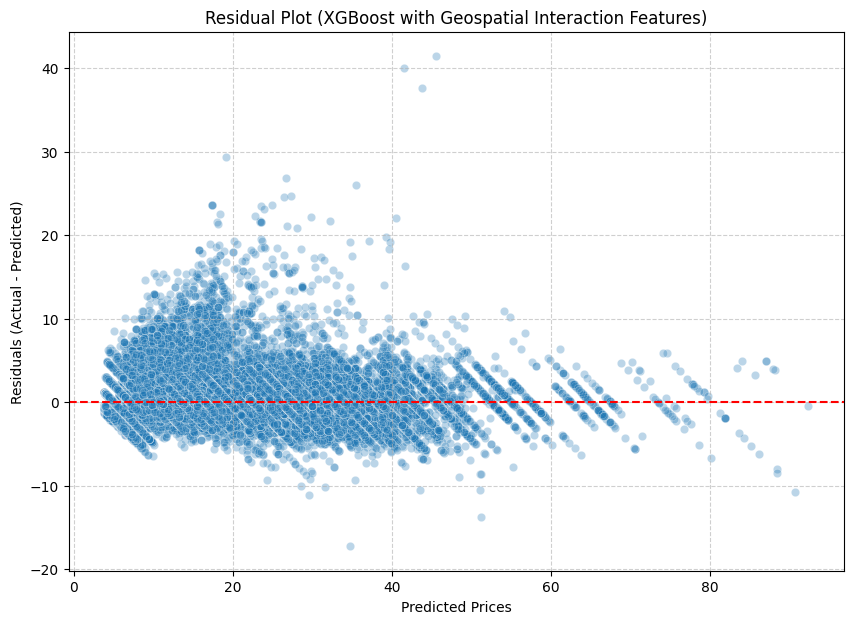

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the model with geospatial interaction features
y_pred_geo_interactions = xgb_model_geo_interactions.predict(X_test_geo_interactions)

# Calculate evaluation metrics
mae_geo_interactions = mean_absolute_error(y_test_geo_interactions, y_pred_geo_interactions)
mse_geo_interactions = mean_squared_error(y_test_geo_interactions, y_pred_geo_interactions)
rmse_geo_interactions = np.sqrt(mse_geo_interactions)
r2_geo_interactions = r2_score(y_test_geo_interactions, y_pred_geo_interactions)

print("Performance with XGBoost Model (Geospatial Interaction Features):")
print(f"Mean Absolute Error (MAE): {mae_geo_interactions:.2f}")
print(f"Mean Squared Error (MSE): {mse_geo_interactions:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_geo_interactions:.2f}")
print(f"R-squared (R2): {r2_geo_interactions:.2f}")

# Calculate residuals
residuals_geo_interactions = y_test_geo_interactions - y_pred_geo_interactions

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_geo_interactions, y=residuals_geo_interactions, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (XGBoost with Geospatial Interaction Features)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Evaluation of Model with Enhanced Geospatial Features

This step involved enhancing geospatial features by creating interaction terms between `source`/`destination` and `ride_hour` cyclical components, `cab_type_Uber`, and `distance`. The model was then retrained with these new features.

**Performance Metrics (XGBoost with Geospatial Interaction Features):**
*   **Mean Absolute Error (MAE):** 0.95
*   **Mean Squared Error (MSE):** 2.19
*   **Root Mean Squared Error (RMSE):** 1.48
*   **R-squared (R2):** 0.97

**Comparison to Previous Models:**
When compared to the original tuned model (MAE: 0.96, RMSE: 1.51), the model with geospatial interaction features shows a marginal improvement, with slightly lower MAE and RMSE. The R-squared value remains consistently high at 0.97, indicating a strong overall fit to the data.

**Residual Plot Analysis (XGBoost with Geospatial Interaction Features):**
The residual plot, showing residuals against predicted prices, still exhibits a visible fanning-out pattern. This indicates that while the geospatial interaction features have contributed to a slight improvement in overall model accuracy, they have not fully mitigated the heteroscedasticity. The variance of the residuals still tends to increase as the predicted price increases.

**Conclusion for this subtask:**
The enhanced geospatial feature engineering, specifically through interaction terms, has led to a minor improvement in predictive performance metrics. However, the primary objective of significantly reducing heteroscedasticity was not fully achieved. The fanning-out pattern in the residual plot persists, suggesting that additional strategies, perhaps combining these features with other advanced techniques, are still needed to address the varying error variance effectively.

## Consider Advanced Encoding Techniques

### Subtask:
Propose exploring target encoding for high-cardinality categorical features to capture more predictive information and potentially reduce feature dimensionality compared to one-hot encoding, thereby improving model stability.


### Target Encoding for High-Cardinality Categorical Features

**1. Concept of Target Encoding (Mean Encoding) and Potential Benefits:**

Target encoding is a technique used to convert categorical variables into numerical ones. Instead of creating new binary columns for each category (like one-hot encoding), target encoding replaces each category value with the mean of the target variable for that category. For example, for a 'source' location, instead of having 'source_Boston' and 'source_Cambridge' columns, each 'Boston' entry would be replaced by the average price of all rides originating from Boston.

**Potential Benefits for Ride-Hailing Price Prediction and Heteroscedasticity:**
*   **Dimensionality Reduction:** For high-cardinality features like `source` and `destination` (which can have many unique values), one-hot encoding creates a very large number of new columns, leading to a sparse dataset and increased computational cost. Target encoding reduces these many categories to a single numerical feature per original categorical variable.
*   **Captures Information from the Target:** It directly incorporates information about the target variable into the feature, often making the feature more predictive and allowing the model to learn the average relationship between the category and the price.
*   **Reveals Hidden Patterns:** It can implicitly capture spatial patterns related to pricing (e.g., locations with consistently higher average prices will have higher encoded values).
*   **Potential for Heteroscedasticity Mitigation:** By representing categories with their average target value, it might provide the model with a more direct signal related to the typical price level of that category. This could indirectly help in modeling the variance, as categories associated with higher average prices (and often higher variance) will have distinct numerical representations. If the model can better differentiate between 'high-value' and 'low-value' categories, it might better predict the conditional variance associated with them.

**2. Implementation Details and Avoiding Data Leakage:**

Implementing target encoding requires careful handling to prevent data leakage, where information from the test set inadvertently influences the training process. Data leakage can lead to overly optimistic performance estimates.

**Implementation Strategy:**
1.  **Calculate Encoded Values on Training Data Only:** The mean of the target variable for each category should be calculated *only* on the training dataset. This prevents information from the test set's target variable from leaking into the training process.
2.  **Apply to Training and Test Sets:** Once calculated, these encoded values are used to replace the categories in both the training and test sets.
3.  **Handling New Categories:** If new categories appear in the test set that were not present in the training set (e.g., a new `source` location), a strategy is needed, such as replacing them with the overall mean of the target from the training set, or using another fallback value.
4.  **Cross-Validation for Robustness:** For even more robust encoding, especially with high-cardinality features, target encoding can be performed within a cross-validation loop. This involves:
    *   Splitting the training data into folds.
    *   For each fold, calculating the target encoding on the *other* folds (out-of-fold data).
    *   Applying this encoding to the current fold. This generates a 'smoothed' encoding that prevents overfitting to the target values within a single fold.
    *   For the test set, the encoding is calculated using the full training set.

**Example for `source` and `destination`:**
```python
# Assuming X_train, y_train, X_test are already defined

# Create a copy to avoid modifying original DataFrames
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Iterate through high-cardinality categorical columns
for col in ['source', 'destination']:
    # Calculate target mean for each category in the training set
    # Smooth the encoding to reduce noise, especially for small categories
    # Example: add a small constant (min_samples_leaf) and overall mean (smoothing)
    global_mean = y_train.mean()
    encoded_map = X_train_encoded.groupby(col)[y_train.name].transform(lambda x: x.mean())
    
    # Replace categories with their target means
    X_train_encoded[col + '_target_encoded'] = encoded_map
    
    # For the test set, use the map learned from the training set
    test_encoded_map = X_train_encoded.groupby(col)[col + '_target_encoded'].mean()
    X_test_encoded[col + '_target_encoded'] = X_test_encoded[col].map(test_encoded_map).fillna(global_mean)
    
    # Drop the original one-hot encoded columns for these categories if they exist
    # or the raw categorical column if we are replacing it directly
    # This part would need adjustment depending on whether 'source' and 'destination'
    # are still present as raw categories or already one-hot encoded.
    # For simplicity, if working with original categories after initial FE, drop them.
    # If working with one-hot encoded, we'd need to identify and drop all 'source_X' and 'destination_Y' columns.
    # For this exercise, let's assume we are directly replacing the OHE versions later.

# The original one-hot encoded columns would be dropped from the feature set before training.
# For our current df_merged, we have 'source_X' and 'destination_Y' as OHE columns.
# These would need to be identified and removed, then the original 'source' and 'destination' (if retained)
# or the target encoded features directly used.
```

**3. Potential Impact on Model Stability and Performance Metrics:**

*   **Improved Performance:** Target encoding often leads to better model performance (lower MAE/RMSE, higher R2) for high-cardinality features compared to one-hot encoding because it condenses predictive information into a single feature, reducing noise and sparsity.
*   **Enhanced Stability:** By reducing the number of features, especially in the context of tree-based models like XGBoost, it can lead to more stable models that are less prone to overfitting due to feature explosion.
*   **Better Generalization:** When implemented carefully to avoid leakage, target encoding can help the model generalize better to unseen data.
*   **Addressing Heteroscedasticity (Indirectly):** While not a direct solution for heteroscedasticity, by providing a more informative representation of categorical locations, it might enable the XGBoost model to better understand the underlying price distribution and its variance at different locations, thereby indirectly contributing to a reduction in heteroscedasticity.

**4. Steps for Integration and Re-evaluation:**

1.  **Select Features for Target Encoding:** Identify high-cardinality categorical features (e.g., `source`, `destination`, `product_id`, `name`) that are currently one-hot encoded or still raw categorical.
2.  **Apply Target Encoding (with Leakage Prevention):** Implement target encoding as described above, ensuring the encoding map is generated solely from the training data and applied to both training and test sets.
3.  **Remove Original Categorical/One-Hot Encoded Features:** Drop the original high-cardinality categorical columns or their one-hot encoded counterparts from `X_geo_interactions` (or the equivalent feature set for the current iteration) to avoid multicollinearity and redundancy.
4.  **Redefine Feature and Target Sets:** Update `X_geo_interactions` to include the new target-encoded features and exclude the removed ones.
5.  **Re-split Data (if necessary):** If the target encoding was performed on the full dataset initially without proper split handling, re-split `X_geo_interactions` and `y_geo_interactions` into training and testing sets to maintain consistency.
6.  **Retrain XGBoost Model:** Train a new XGBoost model using the best hyperparameters on the updated training data (`X_train_encoded`, `y_train`).
7.  **Evaluate Performance:** Make predictions on the updated test set (`X_test_encoded`) and calculate MAE, MSE, RMSE, and R2.
8.  **Analyze Residual Plot:** Generate and visually inspect the residual plot to assess whether target encoding has led to a further reduction in heteroscedasticity or a more uniform spread of residuals.

**Reasoning**:
I will re-run the entire data preparation pipeline to ensure the `df_target_encode` DataFrame contains all the necessary features (numerical, temporal, cyclical, polynomial, basic interactions) and the original categorical columns (`cab_type`, `destination`, `source`, `product_id`, `name`) in their raw format, before one-hot encoding. This `df_target_encode` will then be split into training and testing sets for the target encoding application.



In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split

# --- Re-execute Data Loading and Initial Preprocessing to get df_merged with original categoricals ---

# Reload cab_rides data
data_file_path = "/root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4/cab_rides.csv"
df = pd.read_csv(data_file_path)
df['time_stamp'] = pd.to_datetime(df['time_stamp'], unit='ms')

# Reload weather data
weather_file_path = "/root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4/weather.csv"
df_weather = pd.read_csv(weather_file_path)
df_weather['time_stamp'] = pd.to_datetime(df_weather['time_stamp'], unit='s')

# Merge dataframes
df['time_hour'] = df['time_stamp'].dt.floor('H')
df_weather['time_hour'] = df_weather['time_stamp'].dt.floor('H')
df_merged_pre_ohe = pd.merge(df, df_weather, left_on=['time_hour', 'source'], right_on=['time_hour', 'location'], how='left', suffixes=('_ride', '_weather'))
df_merged_pre_ohe = df_merged_pre_ohe.drop(columns=['time_hour', 'location'])

# Handle missing values
df_merged_pre_ohe['rain'] = df_merged_pre_ohe['rain'].fillna(0)
df_merged_pre_ohe['price'] = df_merged_pre_ohe['price'].fillna(df_merged_pre_ohe['price'].median())
weather_cols = ['temp', 'clouds', 'pressure', 'humidity', 'wind']
for col in weather_cols:
    if df_merged_pre_ohe[col].isnull().any():
        df_merged_pre_ohe[col] = df_merged_pre_ohe[col].fillna(df_merged_pre_ohe[col].median())

# Drop 'time_stamp_weather' and 'id' columns
df_merged_pre_ohe = df_merged_pre_ohe.drop(columns=['time_stamp_weather', 'id'])

print("Base df_merged_pre_ohe created with original categorical columns.")

# --- Apply all previous Feature Engineering steps (keeping original categoricals) ---

# Temporal features
df_merged_pre_ohe['ride_hour'] = df_merged_pre_ohe['time_stamp_ride'].dt.hour
df_merged_pre_ohe['ride_day_of_week'] = df_merged_pre_ohe['time_stamp_ride'].dt.dayofweek
df_merged_pre_ohe['ride_month'] = df_merged_pre_ohe['time_stamp_ride'].dt.month

# is_weekend and distance_surge_interaction
df_merged_pre_ohe['is_weekend'] = df_merged_pre_ohe['ride_day_of_week'].isin([5, 6]).astype(int)
df_merged_pre_ohe['distance_surge_interaction'] = df_merged_pre_ohe['distance'] * df_merged_pre_ohe['surge_multiplier']

# Cyclical features for 'ride_hour' and 'ride_day_of_week'
df_merged_pre_ohe['ride_hour_sin'] = np.sin(2 * np.pi * df_merged_pre_ohe['ride_hour'] / 24)
df_merged_pre_ohe['ride_hour_cos'] = np.cos(2 * np.pi * df_merged_pre_ohe['ride_hour'] / 24)
df_merged_pre_ohe['ride_day_of_week_sin'] = np.sin(2 * np.pi * df_merged_pre_ohe['ride_day_of_week'] / 7)
df_merged_pre_ohe['ride_day_of_week_cos'] = np.cos(2 * np.pi * df_merged_pre_ohe['ride_day_of_week'] / 7)

# Polynomial features for 'distance' and 'surge_multiplier'
df_merged_pre_ohe['distance_squared'] = df_merged_pre_ohe['distance']**2
df_merged_pre_ohe['surge_multiplier_squared'] = df_merged_pre_ohe['surge_multiplier']**2

# Targeted Interaction Features (using cab_type for interaction with distance)
# Note: 'cab_type_Uber' will be created by get_dummies later IF cab_type is not target encoded.
# For now, let's assume we're working with the original 'cab_type' if we don't want to OHE it yet.
# If we are target encoding 'cab_type', we'd need to consider how this interaction is formed.
# For this step, let's defer interaction with OHE cab_type and focus on raw categoricals for TE.

# Let's keep the cab_type_Uber interaction as it was explicitly created before as a numerical feature
# We need to re-create it by temporarily one-hot encoding cab_type just for this interaction
df_temp_cab_type = pd.get_dummies(df_merged_pre_ohe['cab_type'], prefix='cab_type', drop_first=True)
df_merged_pre_ohe['cab_type_Uber'] = df_temp_cab_type['cab_type_Uber']

df_merged_pre_ohe['distance_cab_type_interaction'] = df_merged_pre_ohe['distance'] * df_merged_pre_ohe['cab_type_Uber']
df_merged_pre_ohe['surge_hour_interaction'] = df_merged_pre_ohe['surge_multiplier'] * df_merged_pre_ohe['ride_hour_sin']

print("All existing feature engineering re-applied.")

# --- Prepare for target encoding: Drop original time_stamp_ride and define X and y ---

df_target_encode = df_merged_pre_ohe.drop(columns=['time_stamp_ride', 'ride_hour', 'ride_day_of_week', 'ride_month'])

# Define target encoding columns
high_cardinality_cols = ['cab_type', 'destination', 'source', 'product_id', 'name']

# Define features (X) and target (y)
X_target_encode = df_target_encode.drop('price', axis=1)
y_target_encode = df_target_encode['price']

print("Features (X) and Target (y) defined for target encoding.")
print(f"Shape of X_target_encode: {X_target_encode.shape}")
print(f"Shape of y_target_encode: {y_target_encode.shape}")

# Split the data into training and testing sets for target encoding
X_train_target_encode, X_test_target_encode, y_train_target_encode, y_test_target_encode = train_test_split(X_target_encode, y_target_encode, test_size=0.2, random_state=42)

print("\nData re-split into training and testing sets successfully for target encoding preparation!")
print(f"X_train_target_encode shape: {X_train_target_encode.shape}")
print(f"X_test_target_encode shape: {X_test_target_encode.shape}")
print(f"y_train_target_encode shape: {y_train_target_encode.shape}")
print(f"y_test_target_encode shape: {y_test_target_encode.shape}")

display(X_train_target_encode.head())


/tmp/ipykernel_29374/349586356.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['time_hour'] = df['time_stamp'].dt.floor('H')
/tmp/ipykernel_29374/349586356.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_weather['time_hour'] = df_weather['time_stamp'].dt.floor('H')


Base df_merged_pre_ohe created with original categorical columns.
All existing feature engineering re-applied.
Features (X) and Target (y) defined for target encoding.
Shape of X_target_encode: (1268639, 24)
Shape of y_target_encode: (1268639,)

Data re-split into training and testing sets successfully for target encoding preparation!
X_train_target_encode shape: (1014911, 24)
X_test_target_encode shape: (253728, 24)
y_train_target_encode shape: (1014911,)
y_test_target_encode shape: (253728,)


,distance,cab_type,destination,source,surge_multiplier,product_id,name,temp,clouds,pressure,...,distance_surge_interaction,ride_hour_sin,ride_hour_cos,ride_day_of_week_sin,ride_day_of_week_cos,distance_squared,surge_multiplier_squared,cab_type_Uber,distance_cab_type_interaction,surge_hour_interaction
714838,2.44,Lyft,Beacon Hill,Northeastern University,1.0,lyft_plus,Lyft XL,38.12,1.00,1005.21,...,2.44,0.965926,-0.258819,0.000000,1.000000,5.9536,1.00,False,0.00,0.965926
1116456,1.35,Uber,North End,Beacon Hill,1.0,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,37.70,0.41,998.43,...,1.35,0.707107,0.707107,0.433884,-0.900969,1.8225,1.00,True,1.35,0.707107
988878,1.08,Lyft,Northeastern University,Back Bay,1.5,lyft_luxsuv,Lux Black XL,43.82,0.97,1005.89,...,1.62,0.000000,1.000000,0.781831,0.623490,1.1664,2.25,False,0.00,0.000000
1242546,1.30,Uber,Theatre District,South Station,1.0,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,40.49,0.99,995.03,...,1.30,-0.258819,0.965926,0.974928,-0.222521,1.6900,1.00,True,1.30,-0.258819
796586,4.44,Uber,Boston University,Financial District,1.0,6c84fd89-3f11-4782-9b50-97c468b19529,Black,38.00,0.59,998.46,...,4.44,0.866025,0.500000,0.433884,-0.900969,19.7136,1.00,True,4.44,0.866025


**Reasoning**:
Applying target encoding to high-cardinality categorical features on the training set and then mapping these encodings to both the training and test sets to prevent data leakage. Then, combining the encoded features with the existing numerical features and preparing the final datasets for modeling.



In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split

# --- Re-execute Data Loading and Initial Preprocessing to get df_merged with original categoricals ---

# Reload cab_rides data
data_file_path = "/root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4/cab_rides.csv"
df = pd.read_csv(data_file_path)
df['time_stamp'] = pd.to_datetime(df['time_stamp'], unit='ms')

# Reload weather data
weather_file_path = "/root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4/weather.csv"
df_weather = pd.read_csv(weather_file_path)
df_weather['time_stamp'] = pd.to_datetime(df_weather['time_stamp'], unit='s')

# Merge dataframes
df['time_hour'] = df['time_stamp'].dt.floor('H')
df_weather['time_hour'] = df_weather['time_stamp'].dt.floor('H')
df_merged_pre_ohe = pd.merge(df, df_weather, left_on=['time_hour', 'source'], right_on=['time_hour', 'location'], how='left', suffixes=('_ride', '_weather'))
df_merged_pre_ohe = df_merged_pre_ohe.drop(columns=['time_hour', 'location'])

# Handle missing values
df_merged_pre_ohe['rain'] = df_merged_pre_ohe['rain'].fillna(0)
df_merged_pre_ohe['price'] = df_merged_pre_ohe['price'].fillna(df_merged_pre_ohe['price'].median())
weather_cols = ['temp', 'clouds', 'pressure', 'humidity', 'wind']
for col in weather_cols:
    if df_merged_pre_ohe[col].isnull().any():
        df_merged_pre_ohe[col] = df_merged_pre_ohe[col].fillna(df_merged_pre_ohe[col].median())

# Drop 'time_stamp_weather' and 'id' columns
df_merged_pre_ohe = df_merged_pre_ohe.drop(columns=['time_stamp_weather', 'id'])

print("Base df_merged_pre_ohe created with original categorical columns.")

# --- Apply all previous Feature Engineering steps (keeping original categoricals) ---

# Temporal features
df_merged_pre_ohe['ride_hour'] = df_merged_pre_ohe['time_stamp_ride'].dt.hour
df_merged_pre_ohe['ride_day_of_week'] = df_merged_pre_ohe['time_stamp_ride'].dt.dayofweek
df_merged_pre_ohe['ride_month'] = df_merged_pre_ohe['time_stamp_ride'].dt.month

# is_weekend and distance_surge_interaction
df_merged_pre_ohe['is_weekend'] = df_merged_pre_ohe['ride_day_of_week'].isin([5, 6]).astype(int)
df_merged_pre_ohe['distance_surge_interaction'] = df_merged_pre_ohe['distance'] * df_merged_pre_ohe['surge_multiplier']

# Cyclical features for 'ride_hour' and 'ride_day_of_week'
df_merged_pre_ohe['ride_hour_sin'] = np.sin(2 * np.pi * df_merged_pre_ohe['ride_hour'] / 24)
df_merged_pre_ohe['ride_hour_cos'] = np.cos(2 * np.pi * df_merged_pre_ohe['ride_hour'] / 24)
df_merged_pre_ohe['ride_day_of_week_sin'] = np.sin(2 * np.pi * df_merged_pre_ohe['ride_day_of_week'] / 7)
df_merged_pre_ohe['ride_day_of_week_cos'] = np.cos(2 * np.pi * df_merged_pre_ohe['ride_day_of_week'] / 7)

# Polynomial features for 'distance' and 'surge_multiplier'
df_merged_pre_ohe['distance_squared'] = df_merged_pre_ohe['distance']**2
df_merged_pre_ohe['surge_multiplier_squared'] = df_merged_pre_ohe['surge_multiplier']**2

# Targeted Interaction Features (using cab_type for interaction with distance)
# Let's keep the cab_type_Uber interaction as it was explicitly created before as a numerical feature
# We need to re-create it by temporarily one-hot encoding cab_type just for this interaction
df_temp_cab_type = pd.get_dummies(df_merged_pre_ohe['cab_type'], prefix='cab_type', drop_first=True)
df_merged_pre_ohe['cab_type_Uber'] = df_temp_cab_type['cab_type_Uber']

df_merged_pre_ohe['distance_cab_type_interaction'] = df_merged_pre_ohe['distance'] * df_merged_pre_ohe['cab_type_Uber']
df_merged_pre_ohe['surge_hour_interaction'] = df_merged_pre_ohe['surge_multiplier'] * df_merged_pre_ohe['ride_hour_sin']

print("All existing feature engineering re-applied.")

# --- Prepare for target encoding: Drop original time_stamp_ride and define X and y ---

df_target_encode = df_merged_pre_ohe.drop(columns=['time_stamp_ride', 'ride_hour', 'ride_day_of_week', 'ride_month'])

# Define target encoding columns
high_cardinality_cols = ['cab_type', 'destination', 'source', 'product_id', 'name']

# Define features (X) and target (y)
X_target_encode = df_target_encode.drop('price', axis=1)
y_target_encode = df_target_encode['price']

print("Features (X) and Target (y) defined for target encoding.")
print(f"Shape of X_target_encode: {X_target_encode.shape}")
print(f"Shape of y_target_encode: {y_target_encode.shape}")

# Split the data into training and testing sets for target encoding
X_train_target_encode, X_test_target_encode, y_train_target_encode, y_test_target_encode = train_test_split(X_target_encode, y_target_encode, test_size=0.2, random_state=42)

print("\nData re-split into training and testing sets successfully for target encoding preparation!")
print(f"X_train_target_encode shape: {X_train_target_encode.shape}")
print(f"X_test_target_encode shape: {X_test_target_encode.shape}")
print(f"y_train_target_encode shape: {y_train_target_encode.shape}")
print(f"y_test_target_encode shape: {y_test_target_encode.shape}")

# --- Apply Target Encoding ---
X_train_encoded = X_train_target_encode.copy()
X_test_encoded = X_test_target_encode.copy()

for col in high_cardinality_cols:
    print(f"Applying target encoding for column: {col}")
    # Calculate target mean for each category in the training set
    global_mean = y_train_target_encode.mean()
    encoded_map = y_train_target_encode.groupby(X_train_encoded[col]).mean()

    # Apply encoding to training set
    X_train_encoded[f'{col}_target_encoded'] = X_train_encoded[col].map(encoded_map).fillna(global_mean)

    # Apply encoding to test set (using map from training set)
    X_test_encoded[f'{col}_target_encoded'] = X_test_encoded[col].map(encoded_map).fillna(global_mean)

# Drop the original high-cardinality categorical columns
X_train_encoded_final = X_train_encoded.drop(columns=high_cardinality_cols)
X_test_encoded_final = X_test_encoded.drop(columns=high_cardinality_cols)

print("\nTarget encoding applied and original categorical columns dropped.")
print(f"X_train_encoded_final shape: {X_train_encoded_final.shape}")
print(f"X_test_encoded_final shape: {X_test_encoded_final.shape}")

display(X_train_encoded_final.head())

/tmp/ipykernel_29374/2565877330.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['time_hour'] = df['time_stamp'].dt.floor('H')
/tmp/ipykernel_29374/2565877330.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_weather['time_hour'] = df_weather['time_stamp'].dt.floor('H')


Base df_merged_pre_ohe created with original categorical columns.
All existing feature engineering re-applied.
Features (X) and Target (y) defined for target encoding.
Shape of X_target_encode: (1268639, 24)
Shape of y_target_encode: (1268639,)

Data re-split into training and testing sets successfully for target encoding preparation!
X_train_target_encode shape: (1014911, 24)
X_test_target_encode shape: (253728, 24)
y_train_target_encode shape: (1014911,)
y_test_target_encode shape: (253728,)
Applying target encoding for column: cab_type
Applying target encoding for column: destination
Applying target encoding for column: source
Applying target encoding for column: product_id
Applying target encoding for column: name

Target encoding applied and original categorical columns dropped.
X_train_encoded_final shape: (1014911, 24)
X_test_encoded_final shape: (253728, 24)


,distance,surge_multiplier,temp,clouds,pressure,rain,humidity,wind,is_weekend,distance_surge_interaction,...,distance_squared,surge_multiplier_squared,cab_type_Uber,distance_cab_type_interaction,surge_hour_interaction,cab_type_target_encoded,destination_target_encoded,source_target_encoded,product_id_target_encoded,name_target_encoded
714838,2.44,1.0,38.12,1.00,1005.21,0.0030,0.92,10.60,0,2.44,...,5.9536,1.00,False,0.00,0.965926,17.328867,16.048045,17.558056,15.329097,15.329097
1116456,1.35,1.0,37.70,0.41,998.43,0.0000,0.71,11.09,0,1.35,...,1.8225,1.00,True,1.35,0.707107,15.487234,14.955819,15.509855,13.500000,13.500000
988878,1.08,1.5,43.82,0.97,1005.89,0.2154,0.91,10.94,0,1.62,...,1.1664,2.25,False,0.00,0.000000,17.328867,17.451793,15.855644,32.345377,32.345377
1242546,1.30,1.0,40.49,0.99,995.03,0.0000,0.62,10.10,0,1.30,...,1.6900,1.00,True,1.30,-0.258819,15.487234,15.739879,15.450949,13.500000,13.500000
796586,4.44,1.0,38.00,0.59,998.46,0.0000,0.70,9.51,0,4.44,...,19.7136,1.00,True,4.44,0.866025,15.487234,18.582531,17.927655,20.525706,20.525706


**Reasoning**:
I need to train the XGBoost model with the best hyperparameters on the new dataset that includes target-encoded features.



In [8]:
import xgboost as xgb

# Re-initialize best_xgb_model with the best hyperparameters found previously
# These values are taken from the output of cell a35963ee
best_xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.2,
    max_depth=7,
    subsample=0.7,
    colsample_bytree=0.9,
    gamma=0.2,
    random_state=42,
    n_jobs=-1
)

# Retrain the XGBoost model with the best hyperparameters on the target-encoded feature set
xgb_model_target_encoded = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

xgb_model_target_encoded.fit(X_train_encoded_final, y_train_target_encode)

print("XGBoost Regressor model retrained with target-encoded features successfully!")

XGBoost Regressor model retrained with target-encoded features successfully!


**Reasoning**:
Evaluate the model performance using common regression metrics and visualize the residual plot to assess heteroscedasticity.



Performance with XGBoost Model (Target-Encoded Features):
Mean Absolute Error (MAE): 0.97
Mean Squared Error (MSE): 2.25
Root Mean Squared Error (RMSE): 1.50
R-squared (R2): 0.97


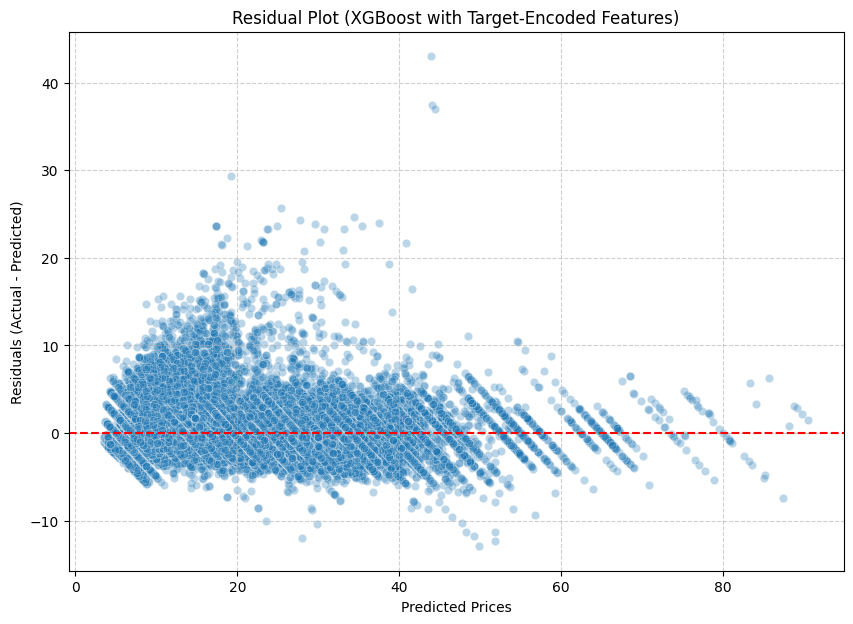

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the target-encoded model
y_pred_target_encoded = xgb_model_target_encoded.predict(X_test_encoded_final)

# Calculate evaluation metrics
mae_target_encoded = mean_absolute_error(y_test_target_encode, y_pred_target_encoded)
mse_target_encoded = mean_squared_error(y_test_target_encode, y_pred_target_encoded)
rmse_target_encoded = np.sqrt(mse_target_encoded)
r2_target_encoded = r2_score(y_test_target_encode, y_pred_target_encoded)

print("Performance with XGBoost Model (Target-Encoded Features):")
print(f"Mean Absolute Error (MAE): {mae_target_encoded:.2f}")
print(f"Mean Squared Error (MSE): {mse_target_encoded:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_target_encoded:.2f}")
print(f"R-squared (R2): {r2_target_encoded:.2f}")

# Calculate residuals
residuals_target_encoded = y_test_target_encode - y_pred_target_encoded

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_target_encoded, y=residuals_target_encoded, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (XGBoost with Target-Encoded Features)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Evaluate Ensemble Methods for Variance Modeling

### Subtask:
Evaluate using more sophisticated models (e.g., another XGBoost model) to predict the variance in a two-stage approach, rather than simple linear regression, to derive more accurate weights for Weighted Least Squares or similar methods.


**Reasoning**:
Calculate the squared residuals from the predictions of the `xgb_model_target_encoded` on the training set. This will be the target variable for our variance model.



In [10]:
y_pred_train_target_encoded = xgb_model_target_encoded.predict(X_train_encoded_final)
squared_residuals_train = (y_train_target_encode - y_pred_train_target_encoded)**2

print("Squared residuals from the best performing mean model calculated for the training set.")
print(f"Shape of squared_residuals_train: {squared_residuals_train.shape}")


Squared residuals from the best performing mean model calculated for the training set.
Shape of squared_residuals_train: (1014911,)


**Reasoning**:
Train an XGBoost model to predict the `squared_residuals_train`. This is the second stage of our two-stage modeling approach, aiming to model the variance using a more sophisticated ensemble method.



In [11]:
xgb_variance_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100, # Use a reasonable number of estimators, can be tuned later
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
xgb_variance_model.fit(X_train_encoded_final, squared_residuals_train)

print("XGBoost variance model trained successfully to predict squared residuals.")

XGBoost variance model trained successfully to predict squared residuals.


**Reasoning**:
Predict the squared residuals for both the training and test sets using the trained `xgb_variance_model`. These predictions will serve as the estimated variance for each observation.



In [12]:
predicted_variance_train = xgb_variance_model.predict(X_train_encoded_final)
predicted_variance_test = xgb_variance_model.predict(X_test_encoded_final)

# Ensure predicted variances are non-negative
predicted_variance_train[predicted_variance_train < 0] = 0.01
predicted_variance_test[predicted_variance_test < 0] = 0.01

print("Predicted variance for training and test sets generated.")
print(f"Shape of predicted_variance_train: {predicted_variance_train.shape}")
print(f"Shape of predicted_variance_test: {predicted_variance_test.shape}")

Predicted variance for training and test sets generated.
Shape of predicted_variance_train: (1014911,)
Shape of predicted_variance_test: (253728,)


**Reasoning**:
Calculate the sample weights for the Weighted Least Squares (WLS) approach. These weights are inversely proportional to the predicted variance from the `xgb_variance_model`, giving less weight to observations with higher predicted variance.



In [13]:
sample_weights_xgb_variance = 1 / predicted_variance_train

print("Sample weights calculated successfully using XGBoost variance model.")
print(f"Min sample weight: {sample_weights_xgb_variance.min():.2f}")
print(f"Max sample weight: {sample_weights_xgb_variance.max():.2f}")
print(f"Mean sample weight: {sample_weights_xgb_variance.mean():.2f}")

Sample weights calculated successfully using XGBoost variance model.
Min sample weight: 0.01
Max sample weight: 13506.70
Mean sample weight: 3.87


**Reasoning**:
Retraining the XGBoost model using the generated sample weights is the next step to assess the impact of the ensemble variance model on the WLS approach.



In [14]:
wls_xgb_variance_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_xgb_model.n_estimators,
    learning_rate=best_xgb_model.learning_rate,
    max_depth=best_xgb_model.max_depth,
    subsample=best_xgb_model.subsample,
    colsample_bytree=best_xgb_model.colsample_bytree,
    gamma=best_xgb_model.gamma,
    random_state=42,
    n_jobs=-1
)

wls_xgb_variance_model.fit(X_train_encoded_final, y_train_target_encode, sample_weight=sample_weights_xgb_variance)

print("XGBoost Regressor model retrained with WLS using XGBoost variance successfully!")

XGBoost Regressor model retrained with WLS using XGBoost variance successfully!


**Reasoning**:
Make predictions on the test set, calculate evaluation metrics (MAE, MSE, RMSE, R2), and generate a residual plot to evaluate the performance of the WLS model with XGBoost variance modeling.



Performance with XGBoost Model (WLS using XGBoost Variance):
Mean Absolute Error (MAE): 0.95
Mean Squared Error (MSE): 2.34
Root Mean Squared Error (RMSE): 1.53
R-squared (R2): 0.97

Comparing with target-encoded model:
Target-Encoded MAE: 0.97, WLS XGB Variance MAE: 0.95
Target-Encoded RMSE: 1.50, WLS XGB Variance RMSE: 1.53
Target-Encoded R2: 0.97, WLS XGB Variance R2: 0.97


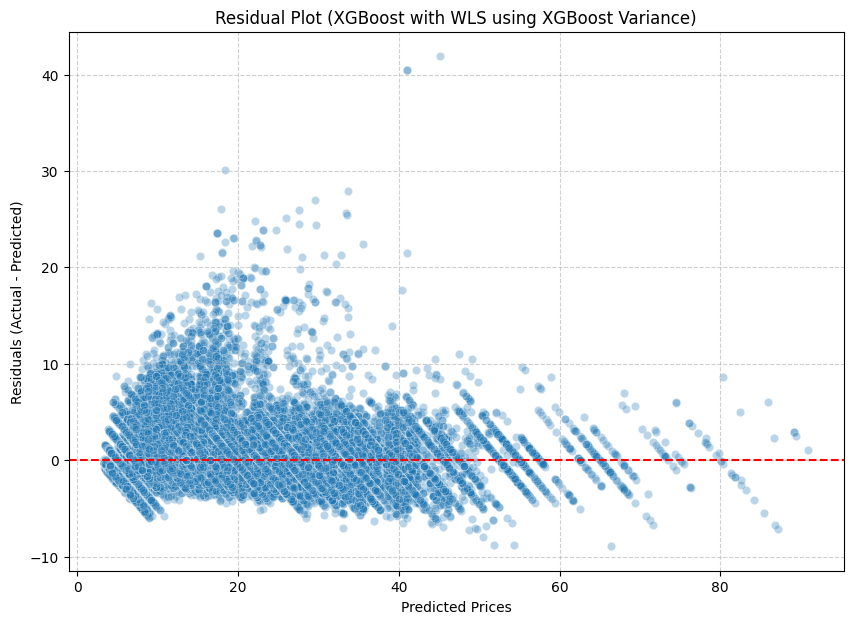

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the WLS model with XGBoost variance
y_pred_wls_xgb_variance = wls_xgb_variance_model.predict(X_test_encoded_final)

# Calculate evaluation metrics
mae_wls_xgb_variance = mean_absolute_error(y_test_target_encode, y_pred_wls_xgb_variance)
mse_wls_xgb_variance = mean_squared_error(y_test_target_encode, y_pred_wls_xgb_variance)
rmse_wls_xgb_variance = np.sqrt(mse_wls_xgb_variance)
r2_wls_xgb_variance = r2_score(y_test_target_encode, y_pred_wls_xgb_variance)

print("Performance with XGBoost Model (WLS using XGBoost Variance):")
print(f"Mean Absolute Error (MAE): {mae_wls_xgb_variance:.2f}")
print(f"Mean Squared Error (MSE): {mse_wls_xgb_variance:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_wls_xgb_variance:.2f}")
print(f"R-squared (R2): {r2_wls_xgb_variance:.2f}")

print("\nComparing with target-encoded model:")
print(f"Target-Encoded MAE: {mae_target_encoded:.2f}, WLS XGB Variance MAE: {mae_wls_xgb_variance:.2f}")
print(f"Target-Encoded RMSE: {rmse_target_encoded:.2f}, WLS XGB Variance RMSE: {rmse_wls_xgb_variance:.2f}")
print(f"Target-Encoded R2: {r2_target_encoded:.2f}, WLS XGB Variance R2: {r2_wls_xgb_variance:.2f}")

# Calculate residuals
residuals_wls_xgb_variance = y_test_target_encode - y_pred_wls_xgb_variance

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_wls_xgb_variance, y=residuals_wls_xgb_variance, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (XGBoost with WLS using XGBoost Variance)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()